# CS3807 – Deep Learning Laboratory
## Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

**Clean final notebook:** one dataset split, one training run per experiment, no old/test-as-validation runs.  The untouched test set is used only for final evaluation.

## 0. Setup and 200-DPI Figure Export
All saved figures are PNG files at **200 DPI**. The notebook uses a single `Experiment_7_Results` folder.

In [1]:
import os, time, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_metric

SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

IMAGE_DPI = 200
RESULTS_DIR = "Experiment_7_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": IMAGE_DPI,
    "savefig.dpi": IMAGE_DPI,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 10,
})

def save_fig(fig, filename):
    fig.tight_layout()
    path = os.path.join(RESULTS_DIR, filename)
    fig.savefig(path, dpi=IMAGE_DPI, bbox_inches="tight", format="png")
    print(f"Saved: {path} | DPI={IMAGE_DPI}")

def save_table_png(df, filename, title):
    fig, ax = plt.subplots(figsize=(14, max(3.5, 0.8 * len(df) + 2)))
    ax.axis("off")
    table = ax.table(cellText=df.round(5).astype(str).values,
                     rowLabels=df.index.astype(str), colLabels=df.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    ax.set_title(title, fontweight="bold", fontsize=16, pad=18)
    save_fig(fig, filename)
    return fig

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("All saved figures: PNG, 200 DPI")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
All saved figures: PNG, 200 DPI


## 1. Dataset Loading, Normalization and the Single Train/Validation/Test Split
MNIST is restricted to the recommended 10,000 training images and 2,000 test images. The 10,000 training images are split into 8,000 training and 2,000 validation images. The test set remains untouched until evaluation.

In [2]:
(x_all, y_all), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()
x_all = x_all.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

N_TRAIN_POOL, N_TEST = 10000, 2000
x_pool, y_pool = x_all[:N_TRAIN_POOL], y_all[:N_TRAIN_POOL]
x_test, y_test = x_test_full[:N_TEST], y_test_full[:N_TEST]

rng = np.random.default_rng(SEED)
idx = rng.permutation(N_TRAIN_POOL)
n_val = 2000
val_idx, tr_idx = idx[:n_val], idx[n_val:]
x_tr, y_tr = x_pool[tr_idx], y_pool[tr_idx]
x_val, y_val = x_pool[val_idx], y_pool[val_idx]

x_tr_cnn = x_tr[..., None]
x_val_cnn = x_val[..., None]
x_test_cnn = x_test[..., None]
x_tr_flat = x_tr.reshape(-1, 784)
x_val_flat = x_val.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Train:", x_tr_cnn.shape)
print("Validation:", x_val_cnn.shape)
print("Test:", x_test_cnn.shape)
print("Pixel range:", x_tr.min(), "to", x_tr.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (8000, 28, 28, 1)
Validation: (2000, 28, 28, 1)
Test: (2000, 28, 28, 1)
Pixel range: 0.0 to 1.0


## 2. Evaluation Utilities

In [3]:
def compute_mse(x, x_hat):
    return float(np.mean((x - x_hat) ** 2))

def compute_mae(x, x_hat):
    return float(np.mean(np.abs(x - x_hat)))

def compute_ssim(x, x_hat):
    a, b = x.reshape(-1, 28, 28), x_hat.reshape(-1, 28, 28)
    return float(np.mean([ssim_metric(a[i], b[i], data_range=1.0) for i in range(len(a))]))

def per_image_mse(x, x_hat):
    a, b = x.reshape(x.shape[0], -1), x_hat.reshape(x_hat.shape[0], -1)
    return np.mean((a - b) ** 2, axis=1)

def count_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

def metrics_dict(clean, recon):
    return {"MSE": compute_mse(clean, recon), "MAE": compute_mae(clean, recon), "SSIM": compute_ssim(clean, recon)}

def add_gaussian_noise(images, sigma, seed=None):
    rng = np.random.default_rng(seed)
    return np.clip(images + rng.normal(0, sigma, images.shape).astype("float32"), 0, 1)

def add_salt_pepper_noise(images, p, seed=None):
    rng = np.random.default_rng(seed)
    noisy = images.copy()
    mask = rng.random(images.shape)
    noisy[mask < p / 2] = 0.0
    noisy[(mask >= p / 2) & (mask < p)] = 1.0
    return noisy

## 3. Fully Connected Autoencoder
Architecture: `784 → 128 → 32 → latent(16) → 32 → 128 → 784`.

In [4]:
LATENT_DIM_FC = 16

def build_fc_autoencoder(latent_dim=16):
    inp = Input((784,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid")(x)
    model = Model(inp, out, name=f"FC_AE_d{latent_dim}")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return model

keras.utils.set_random_seed(SEED)
fc_ae = build_fc_autoencoder()
t0 = time.time()
fc_history = fc_ae.fit(x_tr_flat, x_tr_flat, validation_data=(x_val_flat, x_val_flat),
                        epochs=20, batch_size=128, verbose=2)
fc_time = time.time() - t0
fc_recon = fc_ae.predict(x_test_flat, verbose=0).reshape(-1,28,28,1)
fc_metrics = metrics_dict(x_test_cnn, fc_recon)
print(fc_metrics, "Params:", count_params(fc_ae), "Time:", round(fc_time,1), "s")

I0000 00:00:1790655549.995584      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790655550.001701      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1790655554.942888     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 - 5s - 87ms/step - loss: 0.3681 - val_loss: 0.2528
Epoch 2/20
63/63 - 0s - 5ms/step - loss: 0.2371 - val_loss: 0.2202
Epoch 3/20
63/63 - 0s - 4ms/step - loss: 0.2064 - val_loss: 0.1929
Epoch 4/20
63/63 - 0s - 4ms/step - loss: 0.1819 - val_loss: 0.1744
Epoch 5/20
63/63 - 0s - 4ms/step - loss: 0.1690 - val_loss: 0.1644
Epoch 6/20
63/63 - 0s - 4ms/step - loss: 0.1600 - val_loss: 0.1571
Epoch 7/20
63/63 - 0s - 4ms/step - loss: 0.1534 - val_loss: 0.1519
Epoch 8/20
63/63 - 0s - 4ms/step - loss: 0.1486 - val_loss: 0.1480
Epoch 9/20
63/63 - 0s - 4ms/step - loss: 0.1451 - val_loss: 0.1448
Epoch 10/20
63/63 - 0s - 4ms/step - loss: 0.1420 - val_loss: 0.1419
Epoch 11/20
63/63 - 0s - 4ms/step - loss: 0.1391 - val_loss: 0.1393
Epoch 12/20
63/63 - 0s - 4ms/step - loss: 0.1365 - val_loss: 0.1369
Epoch 13/20
63/63 - 0s - 4ms/step - loss: 0.1342 - val_loss: 0.1348
Epoch 14/20
63/63 - 0s - 4ms/step - loss: 0.1323 - val_loss: 0.1332
Epoch 15/20
63/63 - 0s - 4ms/step - loss: 0.1307 - val_loss: 0.1319

Saved: Experiment_7_Results/01_AE_reconstruction.png | DPI=200


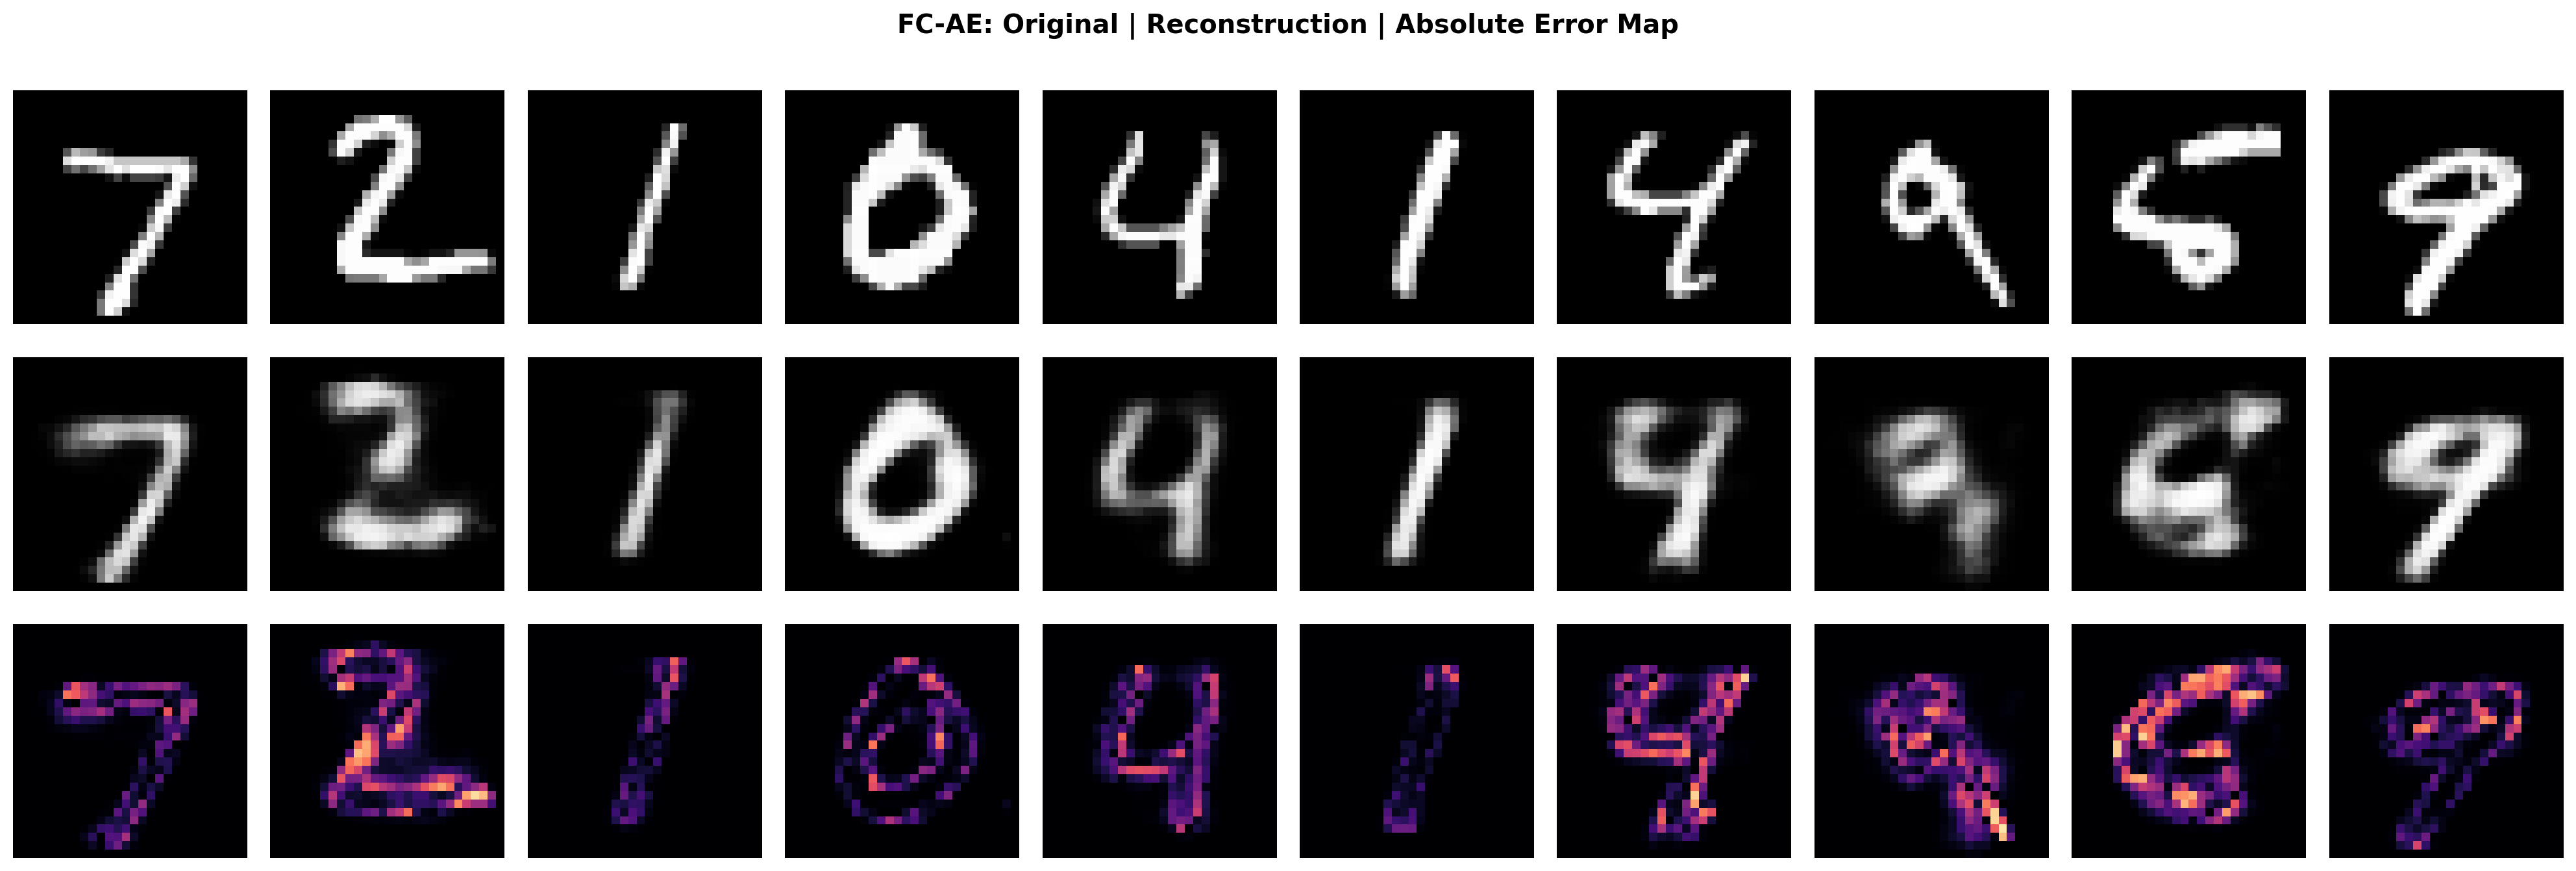

Saved: Experiment_7_Results/02_AE_loss.png | DPI=200


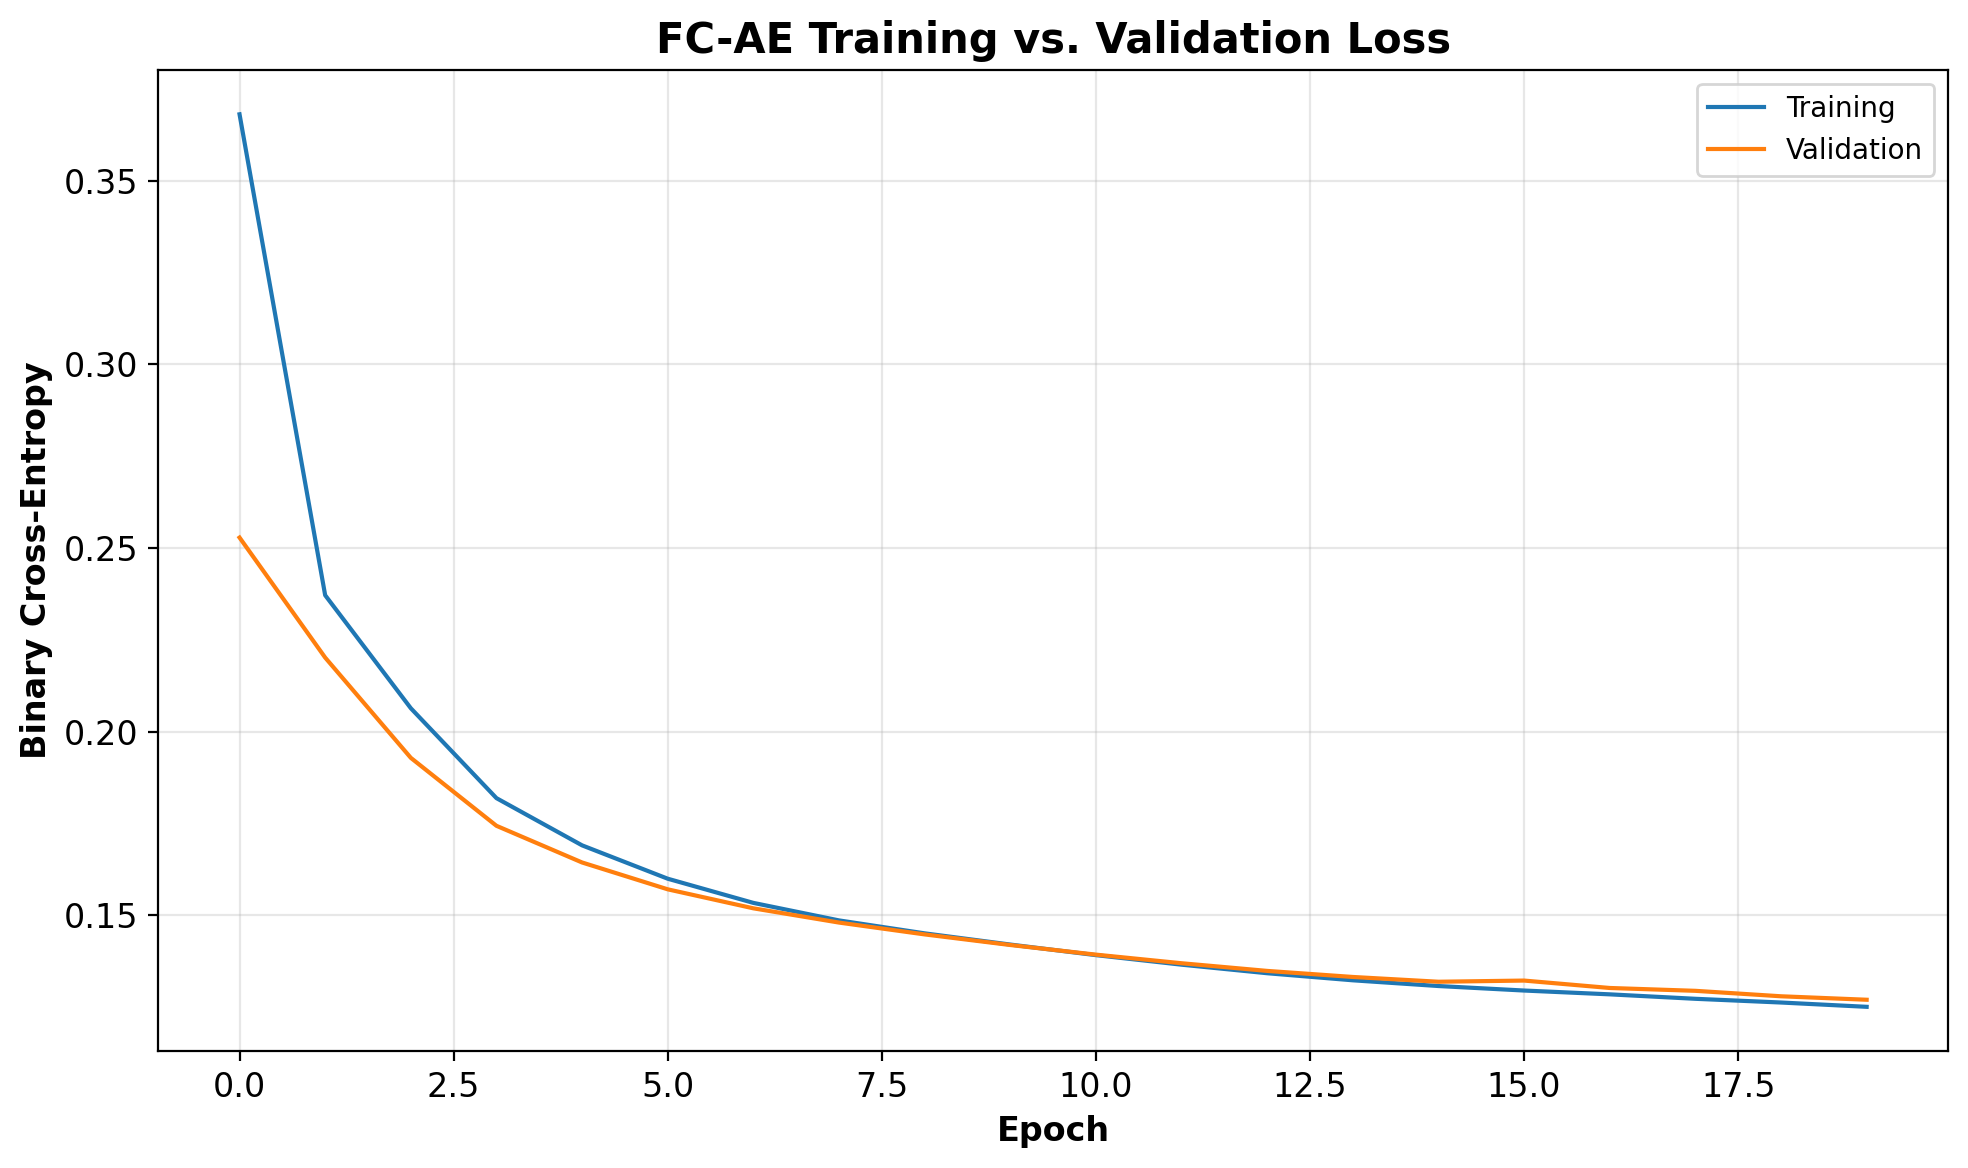

In [5]:
# Plot 1: Original | Reconstruction | Absolute Error Map
n_show = 10
fig, ax = plt.subplots(3, n_show, figsize=(20, 7))
err = np.abs(x_test_cnn - fc_recon)
for i in range(n_show):
    ax[0,i].imshow(x_test_cnn[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax[1,i].imshow(fc_recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax[2,i].imshow(err[i].squeeze(), cmap="magma", vmin=0, vmax=1)
    for r in range(3): ax[r,i].axis("off")
for r,lbl in enumerate(["Original","Reconstructed","Absolute Error"]): ax[r,0].set_ylabel(lbl, fontweight="bold")
fig.suptitle("FC-AE: Original | Reconstruction | Absolute Error Map", fontweight="bold")
save_fig(fig, "01_AE_reconstruction.png"); plt.show()

# Plot 2: Training/validation loss
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fc_history.history["loss"], label="Training")
ax.plot(fc_history.history["val_loss"], label="Validation")
ax.set(xlabel="Epoch", ylabel="Binary Cross-Entropy", title="FC-AE Training vs. Validation Loss")
ax.legend(); ax.grid(alpha=.3)
save_fig(fig, "02_AE_loss.png"); plt.show()

## 4. Convolutional Autoencoder

In [6]:
def build_conv_autoencoder():
    inp = Input((28,28,1))
    x = layers.Conv2D(32,3,activation="relu",padding="same")(inp)
    x = layers.MaxPooling2D(2,padding="same")(x)
    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)
    x = layers.MaxPooling2D(2,padding="same")(x)
    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32,3,activation="relu",padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1,3,activation="sigmoid",padding="same")(x)
    m = Model(inp,out,name="CAE")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

keras.utils.set_random_seed(SEED)
cae = build_conv_autoencoder()
t0=time.time()
cae_history = cae.fit(x_tr_cnn,x_tr_cnn,validation_data=(x_val_cnn,x_val_cnn),epochs=20,batch_size=128,verbose=2)
cae_time=time.time()-t0
cae_recon=cae.predict(x_test_cnn,verbose=0)
cae_metrics=metrics_dict(x_test_cnn,cae_recon)
print(cae_metrics,"Params:",count_params(cae),"Time:",round(cae_time,1),"s")

Epoch 1/20
63/63 - 8s - 134ms/step - loss: 0.2423 - val_loss: 0.1109
Epoch 2/20
63/63 - 1s - 8ms/step - loss: 0.0963 - val_loss: 0.0870
Epoch 3/20
63/63 - 1s - 8ms/step - loss: 0.0840 - val_loss: 0.0810
Epoch 4/20
63/63 - 1s - 8ms/step - loss: 0.0795 - val_loss: 0.0780
Epoch 5/20
63/63 - 1s - 8ms/step - loss: 0.0769 - val_loss: 0.0760
Epoch 6/20
63/63 - 1s - 8ms/step - loss: 0.0754 - val_loss: 0.0748
Epoch 7/20
63/63 - 1s - 8ms/step - loss: 0.0741 - val_loss: 0.0737
Epoch 8/20
63/63 - 1s - 8ms/step - loss: 0.0732 - val_loss: 0.0728
Epoch 9/20
63/63 - 1s - 8ms/step - loss: 0.0724 - val_loss: 0.0718
Epoch 10/20
63/63 - 1s - 8ms/step - loss: 0.0718 - val_loss: 0.0713
Epoch 11/20
63/63 - 1s - 8ms/step - loss: 0.0713 - val_loss: 0.0710
Epoch 12/20
63/63 - 1s - 8ms/step - loss: 0.0708 - val_loss: 0.0706
Epoch 13/20
63/63 - 1s - 8ms/step - loss: 0.0704 - val_loss: 0.0701
Epoch 14/20
63/63 - 1s - 8ms/step - loss: 0.0700 - val_loss: 0.0700
Epoch 15/20
63/63 - 1s - 8ms/step - loss: 0.0698 - val_

Saved: Experiment_7_Results/03a_CAE_error_map.png | DPI=200


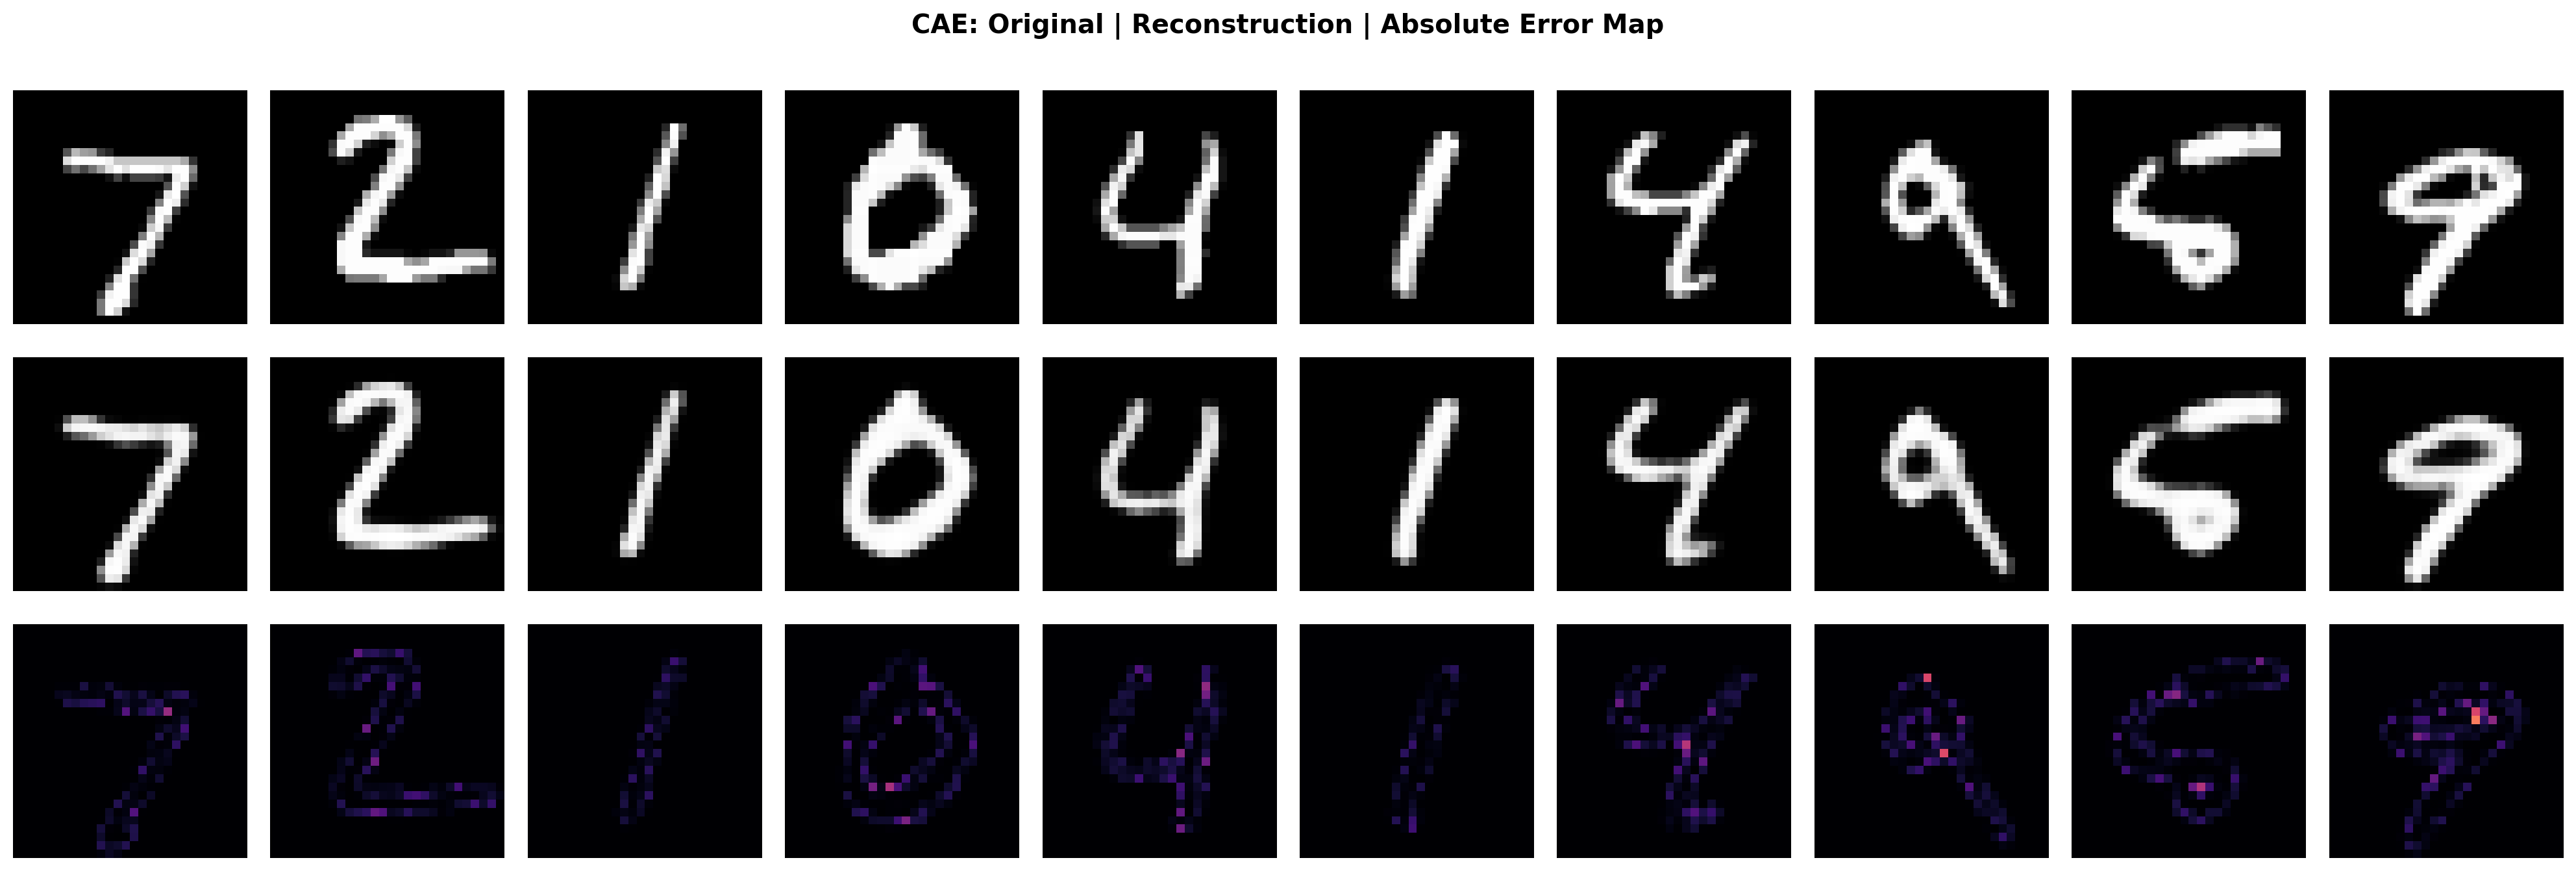

Saved: Experiment_7_Results/03_FC_vs_CNN.png | DPI=200


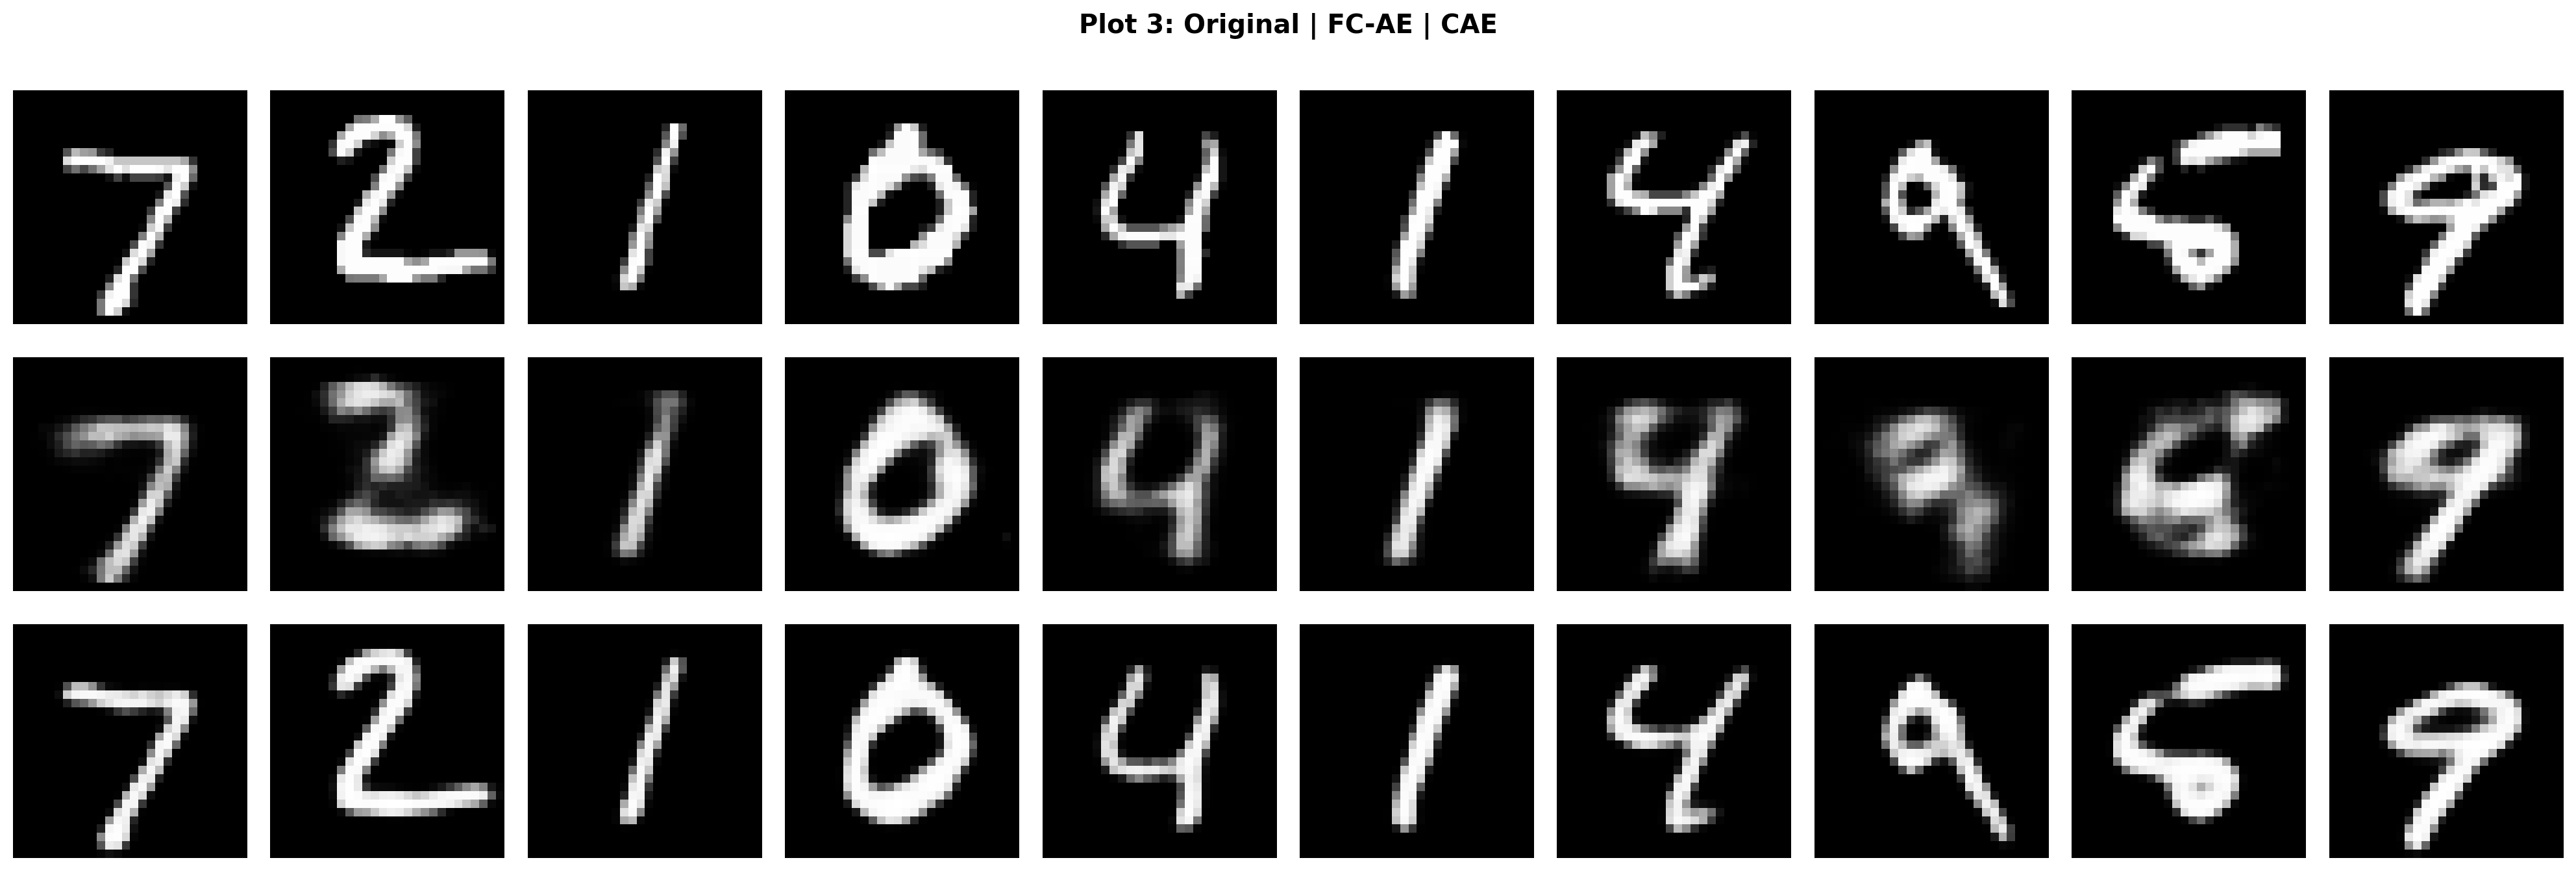

Saved: Experiment_7_Results/03b_CAE_loss.png | DPI=200


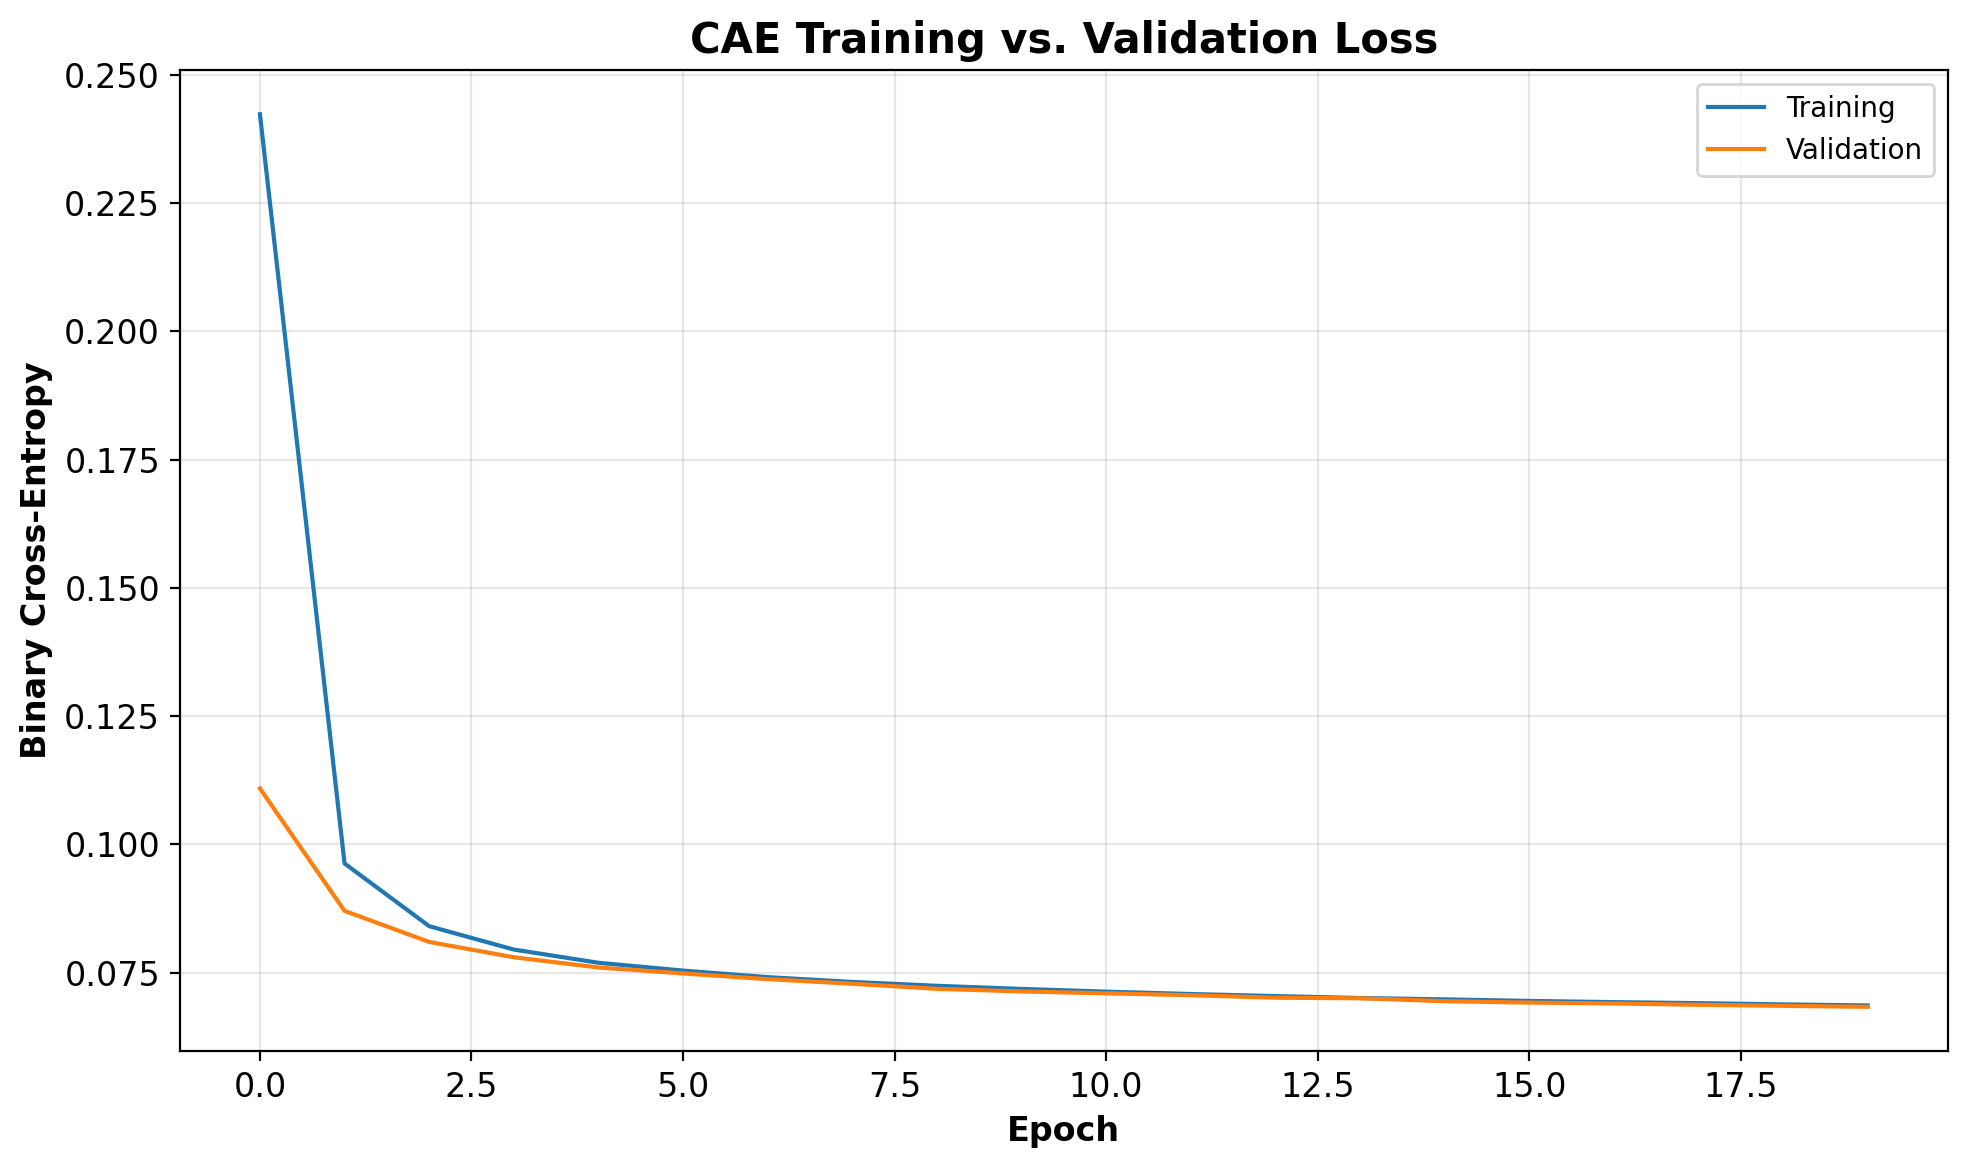

In [7]:
# CAE reference-style error map
fig, ax = plt.subplots(3,n_show,figsize=(20,7)); err=np.abs(x_test_cnn-cae_recon)
for i in range(n_show):
    ax[0,i].imshow(x_test_cnn[i].squeeze(),cmap="gray",vmin=0,vmax=1)
    ax[1,i].imshow(cae_recon[i].squeeze(),cmap="gray",vmin=0,vmax=1)
    ax[2,i].imshow(err[i].squeeze(),cmap="magma",vmin=0,vmax=1)
    for r in range(3): ax[r,i].axis("off")
for r,lbl in enumerate(["Original","Reconstructed","Absolute Error"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("CAE: Original | Reconstruction | Absolute Error Map",fontweight="bold")
save_fig(fig,"03a_CAE_error_map.png"); plt.show()

# Plot 3: FC-AE vs CAE
fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,imgs in enumerate([x_test_cnn,fc_recon,cae_recon]): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); ax[r,i].axis("off")
for r,lbl in enumerate(["Original","FC-AE","CAE"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Plot 3: Original | FC-AE | CAE",fontweight="bold"); save_fig(fig,"03_FC_vs_CNN.png"); plt.show()

# CAE training/validation loss (reference-report extra)
fig,ax=plt.subplots(figsize=(10,6)); ax.plot(cae_history.history["loss"],label="Training"); ax.plot(cae_history.history["val_loss"],label="Validation")
ax.set(xlabel="Epoch",ylabel="Binary Cross-Entropy",title="CAE Training vs. Validation Loss"); ax.legend(); ax.grid(alpha=.3)
save_fig(fig,"03b_CAE_loss.png"); plt.show()

## 5. Gaussian Denoising Convolutional Autoencoder
Training corruption: Gaussian noise with `sigma = 0.2`.

In [8]:
SIGMA_TRAIN=0.2
x_tr_noisy=add_gaussian_noise(x_tr_cnn,SIGMA_TRAIN,SEED)
x_val_noisy=add_gaussian_noise(x_val_cnn,SIGMA_TRAIN,SEED+1)
keras.utils.set_random_seed(SEED)
denoise_ae=build_conv_autoencoder()
t0=time.time()
denoise_history=denoise_ae.fit(x_tr_noisy,x_tr_cnn,validation_data=(x_val_noisy,x_val_cnn),epochs=20,batch_size=128,verbose=2)
denoise_time=time.time()-t0
x_test_noisy=add_gaussian_noise(x_test_cnn,SIGMA_TRAIN,SEED+2)
denoised=denoise_ae.predict(x_test_noisy,verbose=0)
denoise_metrics=metrics_dict(x_test_cnn,denoised)
print(denoise_metrics,"Params:",count_params(denoise_ae),"Time:",round(denoise_time,1),"s")

Epoch 1/20
63/63 - 6s - 90ms/step - loss: 0.2841 - val_loss: 0.1343
Epoch 2/20
63/63 - 1s - 10ms/step - loss: 0.1152 - val_loss: 0.1021
Epoch 3/20
63/63 - 1s - 8ms/step - loss: 0.0974 - val_loss: 0.0930
Epoch 4/20
63/63 - 1s - 8ms/step - loss: 0.0909 - val_loss: 0.0883
Epoch 5/20
63/63 - 1s - 8ms/step - loss: 0.0870 - val_loss: 0.0852
Epoch 6/20
63/63 - 1s - 8ms/step - loss: 0.0846 - val_loss: 0.0830
Epoch 7/20
63/63 - 1s - 8ms/step - loss: 0.0827 - val_loss: 0.0817
Epoch 8/20
63/63 - 1s - 8ms/step - loss: 0.0814 - val_loss: 0.0805
Epoch 9/20
63/63 - 1s - 8ms/step - loss: 0.0804 - val_loss: 0.0798
Epoch 10/20
63/63 - 1s - 8ms/step - loss: 0.0797 - val_loss: 0.0790
Epoch 11/20
63/63 - 1s - 8ms/step - loss: 0.0790 - val_loss: 0.0784
Epoch 12/20
63/63 - 1s - 8ms/step - loss: 0.0784 - val_loss: 0.0779
Epoch 13/20
63/63 - 1s - 8ms/step - loss: 0.0779 - val_loss: 0.0775
Epoch 14/20
63/63 - 1s - 8ms/step - loss: 0.0775 - val_loss: 0.0771
Epoch 15/20
63/63 - 1s - 8ms/step - loss: 0.0771 - val_

Saved: Experiment_7_Results/04_Denoising.png | DPI=200


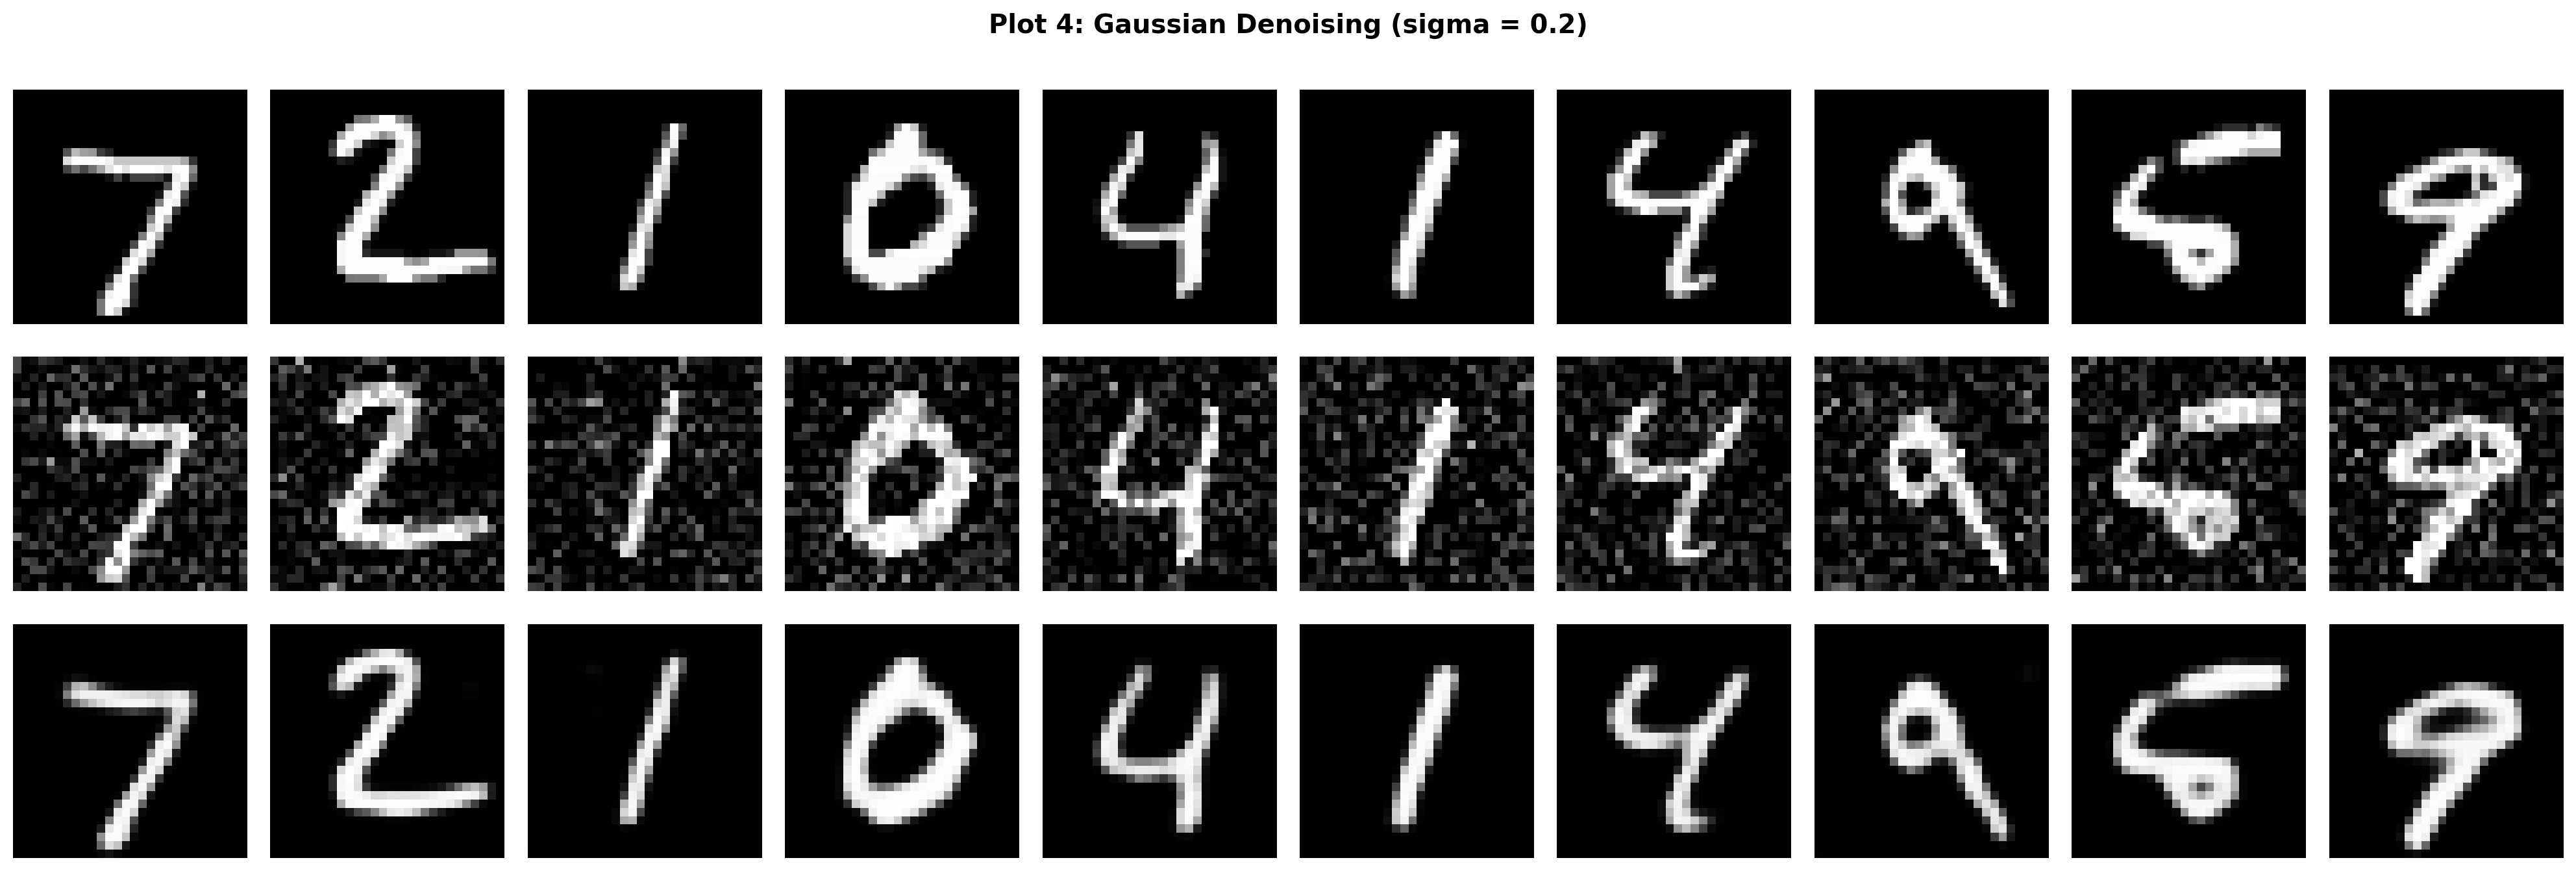

Saved: Experiment_7_Results/05_Noise_metrics.png | DPI=200


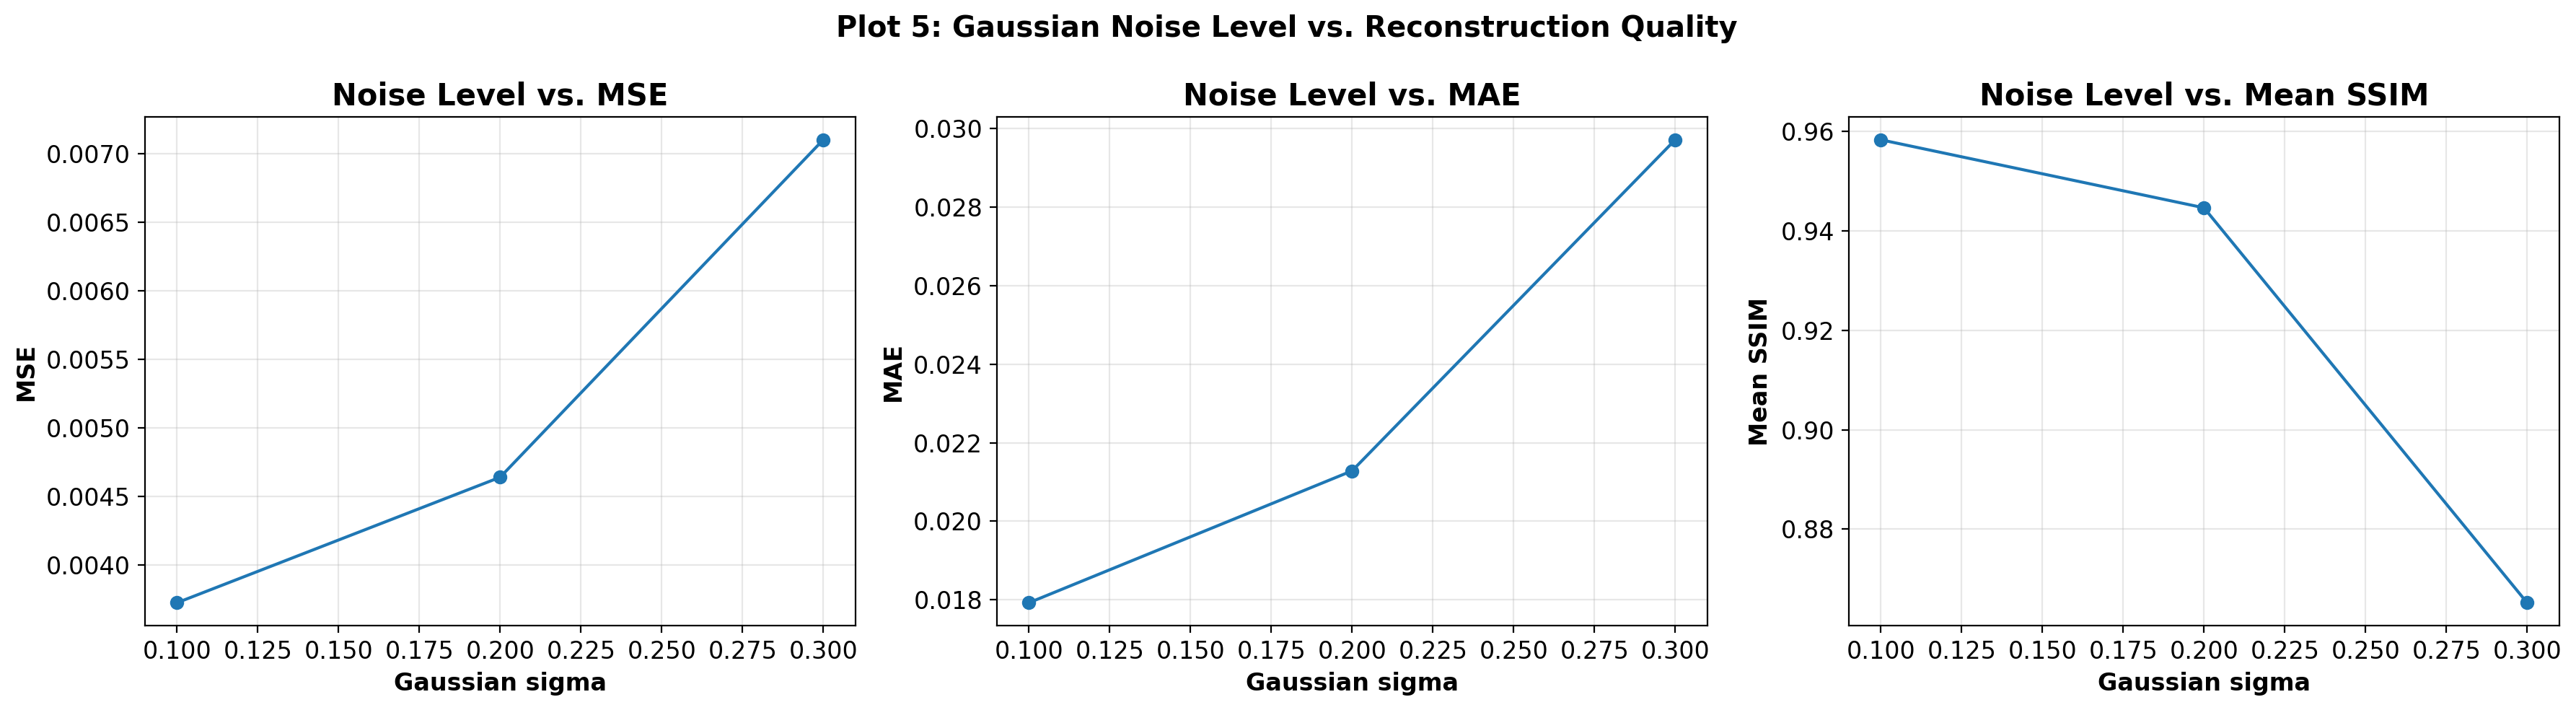

 sigma     MSE     MAE    SSIM
   0.1 0.00372 0.01793 0.95836
   0.2 0.00464 0.02128 0.94468
   0.3 0.00710 0.02971 0.86519


In [9]:
# Plot 4
fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,imgs in enumerate([x_test_cnn,x_test_noisy,denoised]): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); ax[r,i].axis("off")
for r,lbl in enumerate(["Clean","Gaussian Noisy","Denoised"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Plot 4: Gaussian Denoising (sigma = 0.2)",fontweight="bold"); save_fig(fig,"04_Denoising.png"); plt.show()

# Plot 5
sigmas=[0.1,0.2,0.3]; noise_metrics={k:[] for k in ["sigma","MSE","MAE","SSIM"]}
for j,s in enumerate(sigmas):
    xn=add_gaussian_noise(x_test_cnn,s,100+j); rec=denoise_ae.predict(xn,verbose=0)
    noise_metrics["sigma"].append(s); noise_metrics["MSE"].append(compute_mse(x_test_cnn,rec)); noise_metrics["MAE"].append(compute_mae(x_test_cnn,rec)); noise_metrics["SSIM"].append(compute_ssim(x_test_cnn,rec))
fig,ax=plt.subplots(1,3,figsize=(18,5))
for a,k,lab in zip(ax,["MSE","MAE","SSIM"],["MSE","MAE","Mean SSIM"]): a.plot(sigmas,noise_metrics[k],marker="o"); a.set(xlabel="Gaussian sigma",ylabel=lab,title=f"Noise Level vs. {lab}"); a.grid(alpha=.3)
fig.suptitle("Plot 5: Gaussian Noise Level vs. Reconstruction Quality",fontweight="bold"); save_fig(fig,"05_Noise_metrics.png"); plt.show()
print(pd.DataFrame(noise_metrics).round(5).to_string(index=False))

## 6. Salt-and-Pepper Denoising (Main Comparison / Additional Exercise 2)

Epoch 1/20
63/63 - 6s - 91ms/step - loss: 0.2827 - val_loss: 0.1402
Epoch 2/20
63/63 - 1s - 9ms/step - loss: 0.1198 - val_loss: 0.1049
Epoch 3/20
63/63 - 1s - 8ms/step - loss: 0.0982 - val_loss: 0.0931
Epoch 4/20
63/63 - 1s - 8ms/step - loss: 0.0910 - val_loss: 0.0884
Epoch 5/20
63/63 - 1s - 8ms/step - loss: 0.0874 - val_loss: 0.0856
Epoch 6/20
63/63 - 1s - 8ms/step - loss: 0.0853 - val_loss: 0.0844
Epoch 7/20
63/63 - 1s - 8ms/step - loss: 0.0833 - val_loss: 0.0825
Epoch 8/20
63/63 - 1s - 8ms/step - loss: 0.0823 - val_loss: 0.0815
Epoch 9/20
63/63 - 1s - 8ms/step - loss: 0.0812 - val_loss: 0.0805
Epoch 10/20
63/63 - 1s - 8ms/step - loss: 0.0804 - val_loss: 0.0799
Epoch 11/20
63/63 - 1s - 8ms/step - loss: 0.0797 - val_loss: 0.0793
Epoch 12/20
63/63 - 1s - 9ms/step - loss: 0.0791 - val_loss: 0.0787
Epoch 13/20
63/63 - 1s - 8ms/step - loss: 0.0785 - val_loss: 0.0783
Epoch 14/20
63/63 - 1s - 8ms/step - loss: 0.0781 - val_loss: 0.0778
Epoch 15/20
63/63 - 1s - 8ms/step - loss: 0.0776 - val_l

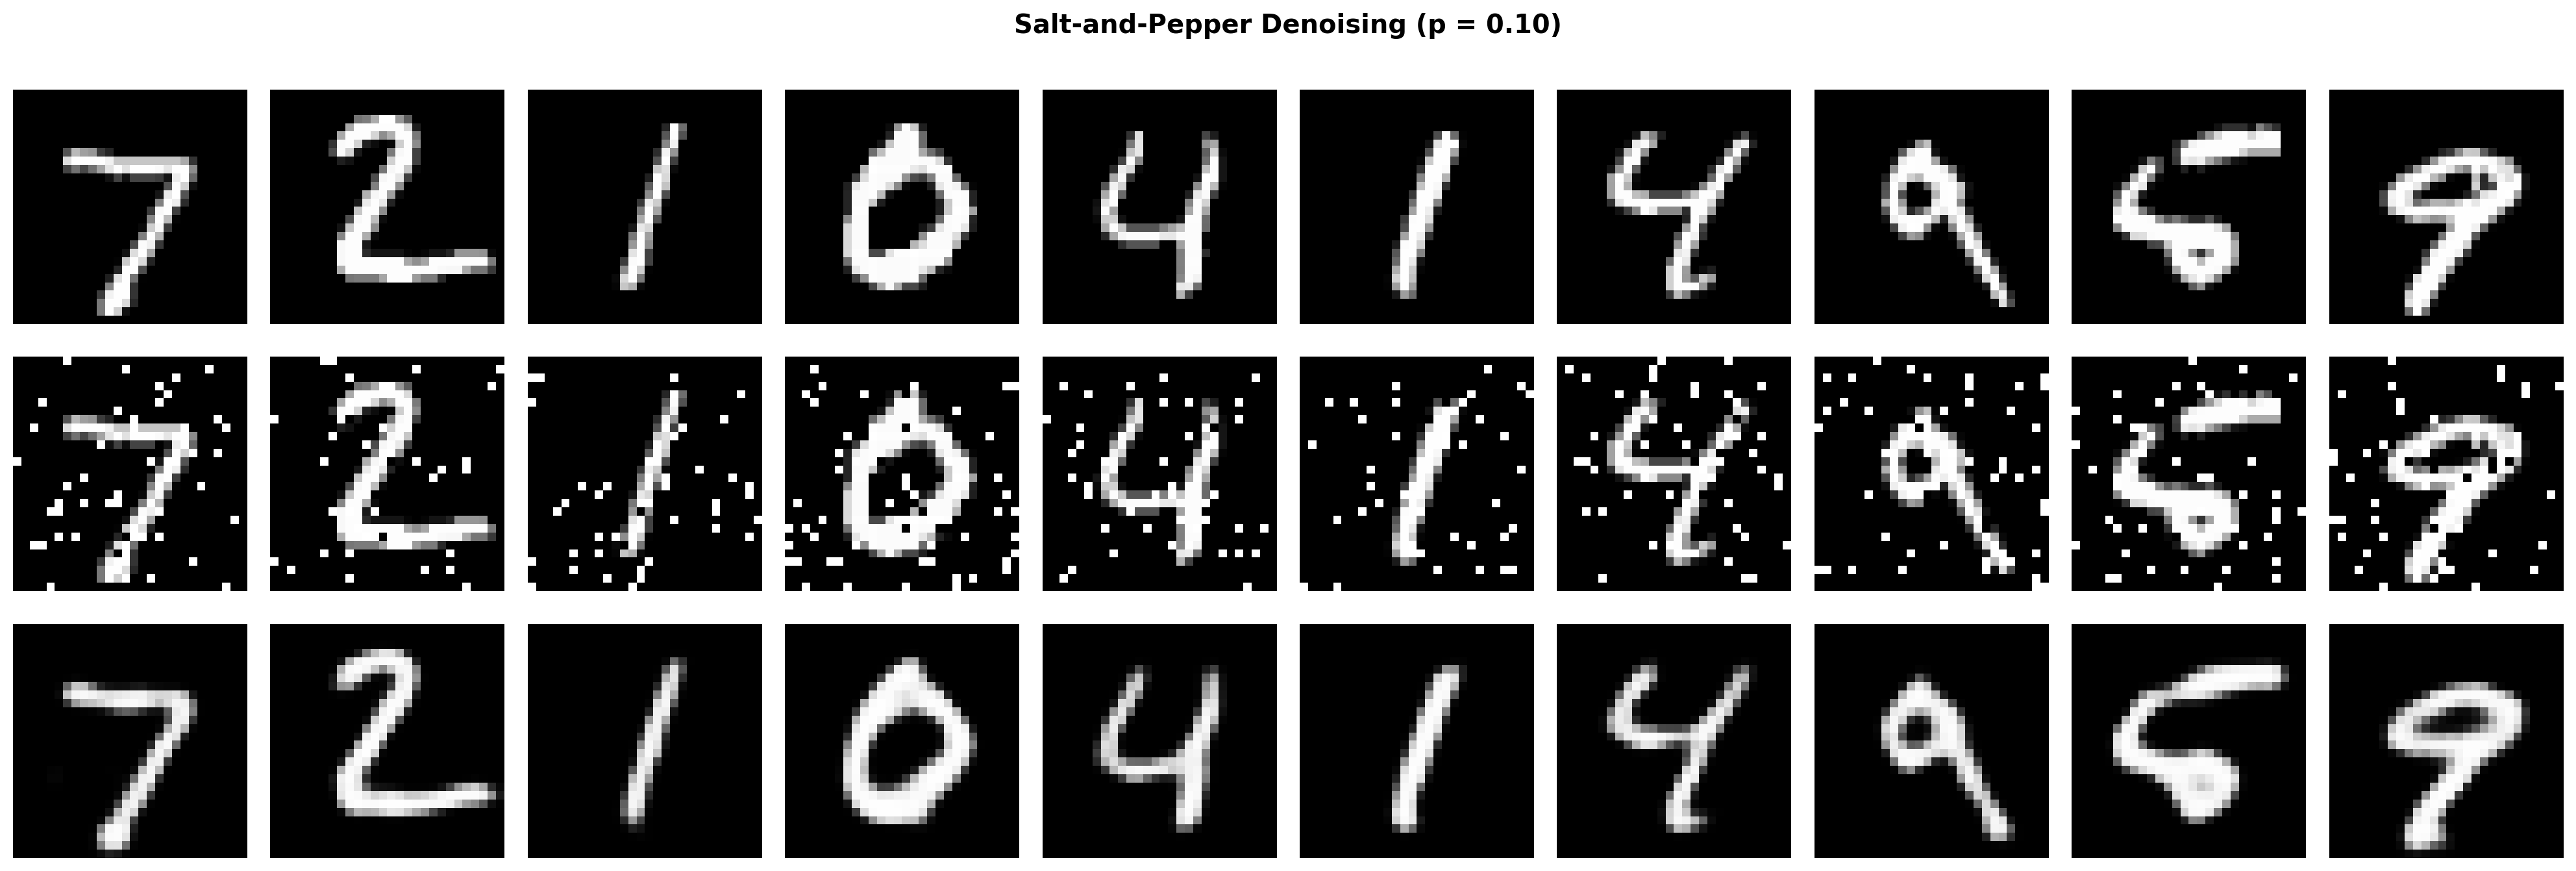

Saved: Experiment_7_Results/12_SP_Noise_metrics.png | DPI=200


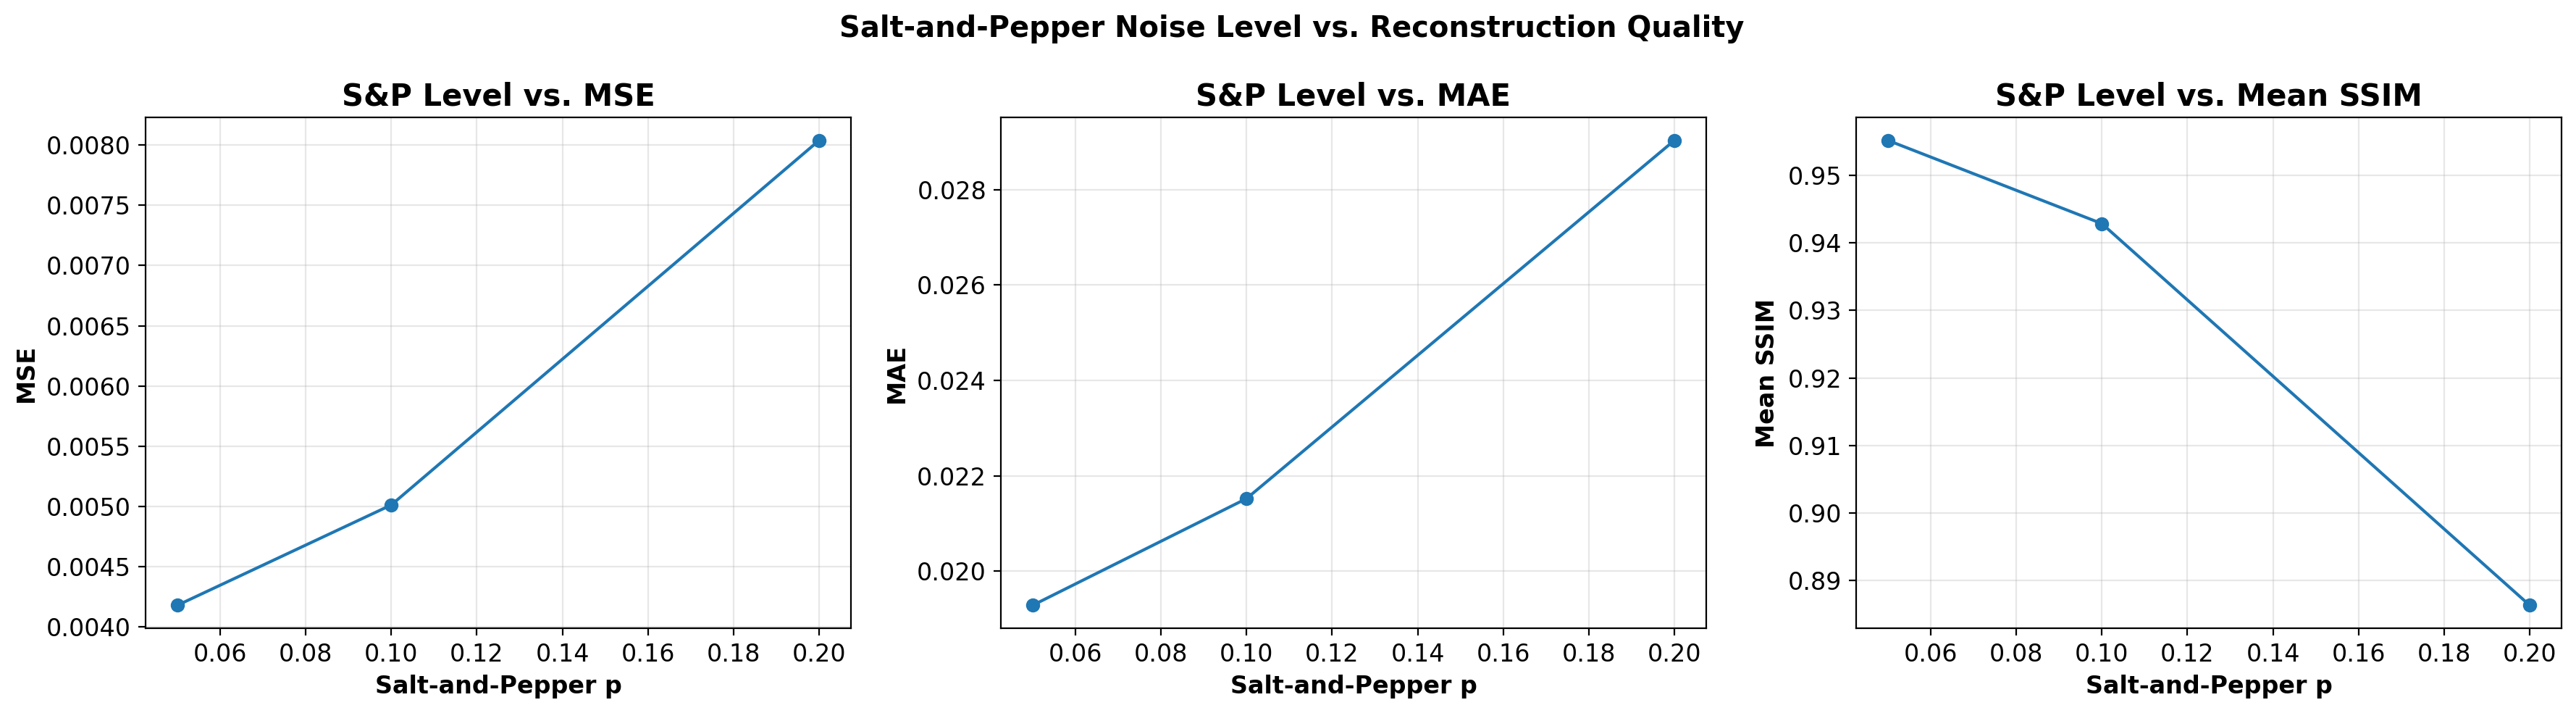

In [10]:
SP_LEVELS=[0.05,0.10,0.20]; SP_TRAIN=0.10
x_tr_sp=add_salt_pepper_noise(x_tr_cnn,SP_TRAIN,200)
x_val_sp=add_salt_pepper_noise(x_val_cnn,SP_TRAIN,201)
keras.utils.set_random_seed(SEED)
sp_ae=build_conv_autoencoder(); t0=time.time()
sp_history=sp_ae.fit(x_tr_sp,x_tr_cnn,validation_data=(x_val_sp,x_val_cnn),epochs=20,batch_size=128,verbose=2)
sp_time=time.time()-t0
sp_noisy={p:add_salt_pepper_noise(x_test_cnn,p,300+i) for i,p in enumerate(SP_LEVELS)}
sp_recon={p:sp_ae.predict(sp_noisy[p],verbose=0) for p in SP_LEVELS}
sp_metrics={k:[] for k in ["p","MSE","MAE","SSIM"]}
for p in SP_LEVELS:
    m=metrics_dict(x_test_cnn,sp_recon[p]); sp_metrics["p"].append(p)
    for k in ["MSE","MAE","SSIM"]: sp_metrics[k].append(m[k])
print(pd.DataFrame(sp_metrics).round(5).to_string(index=False))

# S&P visual at p=.10
p=.10; fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,imgs in enumerate([x_test_cnn,sp_noisy[p],sp_recon[p]]): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); ax[r,i].axis("off")
for r,lbl in enumerate(["Clean","S&P Noisy","Denoised"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Salt-and-Pepper Denoising (p = 0.10)",fontweight="bold"); save_fig(fig,"11_SP_Denoising_p010.png"); plt.show()

# S&P metrics
fig,ax=plt.subplots(1,3,figsize=(18,5))
for a,k,lab in zip(ax,["MSE","MAE","SSIM"],["MSE","MAE","Mean SSIM"]): a.plot(SP_LEVELS,sp_metrics[k],marker="o"); a.set(xlabel="Salt-and-Pepper p",ylabel=lab,title=f"S&P Level vs. {lab}"); a.grid(alpha=.3)
fig.suptitle("Salt-and-Pepper Noise Level vs. Reconstruction Quality",fontweight="bold"); save_fig(fig,"12_SP_Noise_metrics.png"); plt.show()

## 7. Variational Autoencoder (VAE), latent dimension = 2

In [11]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar=inputs
        eps=tf.random.normal(shape=tf.shape(mu))
        return mu+tf.exp(0.5*logvar)*eps

def build_vae_parts(latent_dim):
    ei=Input((28,28,1)); x=layers.Conv2D(32,3,activation="relu",strides=2,padding="same")(ei); x=layers.Conv2D(64,3,activation="relu",strides=2,padding="same")(x)
    shape=x.shape[1:]; x=layers.Flatten()(x); x=layers.Dense(16,activation="relu")(x)
    mu=layers.Dense(latent_dim,name="z_mean")(x); logvar=layers.Dense(latent_dim,name="z_log_var")(x); z=Sampling()([mu,logvar])
    enc=Model(ei,[mu,logvar,z],name=f"Encoder_d{latent_dim}")
    di=Input((latent_dim,)); x=layers.Dense(int(np.prod(shape)),activation="relu")(di); x=layers.Reshape(shape)(x)
    x=layers.Conv2DTranspose(64,3,activation="relu",strides=2,padding="same")(x); x=layers.Conv2DTranspose(32,3,activation="relu",strides=2,padding="same")(x); out=layers.Conv2DTranspose(1,3,activation="sigmoid",padding="same")(x)
    dec=Model(di,out,name=f"Decoder_d{latent_dim}")
    return enc,dec

class VAE(Model):
    def __init__(self,encoder,decoder,beta=1.0):
        super().__init__(); self.encoder=encoder; self.decoder=decoder; self.beta=beta
        self.total_loss_tracker=keras.metrics.Mean(name="loss"); self.rec_loss_tracker=keras.metrics.Mean(name="reconstruction_loss"); self.kl_loss_tracker=keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self): return [self.total_loss_tracker,self.rec_loss_tracker,self.kl_loss_tracker]
    def _terms(self,x):
        mu,logvar,z=self.encoder(x); recon=self.decoder(z)
        rec=tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x,recon),axis=(1,2)))
        kl=-0.5*tf.reduce_mean(tf.reduce_sum(1+logvar-tf.square(mu)-tf.exp(logvar),axis=1))
        return rec,kl,recon
    def train_step(self,data):
        x=data[0] if isinstance(data,tuple) else data
        with tf.GradientTape() as tape: rec,kl,_=self._terms(x); total=rec+self.beta*kl
        grads=tape.gradient(total,self.trainable_weights); self.optimizer.apply_gradients(zip(grads,self.trainable_weights))
        self.total_loss_tracker.update_state(total); self.rec_loss_tracker.update_state(rec); self.kl_loss_tracker.update_state(kl)
        return {m.name:m.result() for m in self.metrics}
    def test_step(self,data):
        x=data[0] if isinstance(data,tuple) else data; rec,kl,_=self._terms(x); total=rec+self.beta*kl
        self.total_loss_tracker.update_state(total); self.rec_loss_tracker.update_state(rec); self.kl_loss_tracker.update_state(kl)
        return {m.name:m.result() for m in self.metrics}

def train_vae(latent_dim=2,beta=1.0):
    keras.utils.set_random_seed(SEED+latent_dim+int(beta*10))
    enc,dec=build_vae_parts(latent_dim); model=VAE(enc,dec,beta); model.compile(optimizer=keras.optimizers.Adam(1e-3))
    t0=time.time(); hist=model.fit(x_tr_cnn,x_tr_cnn,validation_data=(x_val_cnn,x_val_cnn),epochs=20,batch_size=128,verbose=2)
    return model,enc,dec,hist,time.time()-t0

def vae_eval(model,enc,dec):
    ev=model.evaluate(x_test_cnn,x_test_cnn,verbose=0,return_dict=True)
    mu,logvar,_=enc.predict(x_test_cnn,verbose=0); recon=dec.predict(mu,verbose=0)
    m=metrics_dict(x_test_cnn,recon); return {**m,"recon_loss":float(ev["reconstruction_loss"]),"kl":float(ev["kl_loss"]),"total":float(ev["loss"]),"mu":mu,"logvar":logvar,"recon":recon}

vae,encoder,decoder,vae_history,vae_time=train_vae(2,1.0)
vae2=vae_eval(vae,encoder,decoder)
print({k:vae2[k] for k in ["MSE","MAE","SSIM","recon_loss","kl","total"]})

Epoch 1/20
63/63 - 11s - 176ms/step - kl_loss: 0.7381 - loss: 334.6661 - reconstruction_loss: 333.9280 - val_kl_loss: 0.6124 - val_loss: 219.2452 - val_reconstruction_loss: 218.6329
Epoch 2/20
63/63 - 1s - 8ms/step - kl_loss: 0.4353 - loss: 213.5937 - reconstruction_loss: 213.1584 - val_kl_loss: 0.2520 - val_loss: 209.3700 - val_reconstruction_loss: 209.1180
Epoch 3/20
63/63 - 1s - 8ms/step - kl_loss: 1.1260 - loss: 207.0078 - reconstruction_loss: 205.8818 - val_kl_loss: 2.0148 - val_loss: 203.8494 - val_reconstruction_loss: 201.8345
Epoch 4/20
63/63 - 1s - 8ms/step - kl_loss: 2.3530 - loss: 203.3659 - reconstruction_loss: 201.0129 - val_kl_loss: 2.2686 - val_loss: 200.9723 - val_reconstruction_loss: 198.7037
Epoch 5/20
63/63 - 1s - 8ms/step - kl_loss: 2.6017 - loss: 201.2474 - reconstruction_loss: 198.6458 - val_kl_loss: 2.7096 - val_loss: 199.3575 - val_reconstruction_loss: 196.6479
Epoch 6/20
63/63 - 1s - 8ms/step - kl_loss: 2.8311 - loss: 199.6905 - reconstruction_loss: 196.8595 - 

Saved: Experiment_7_Results/06_VAE_latent.png | DPI=200


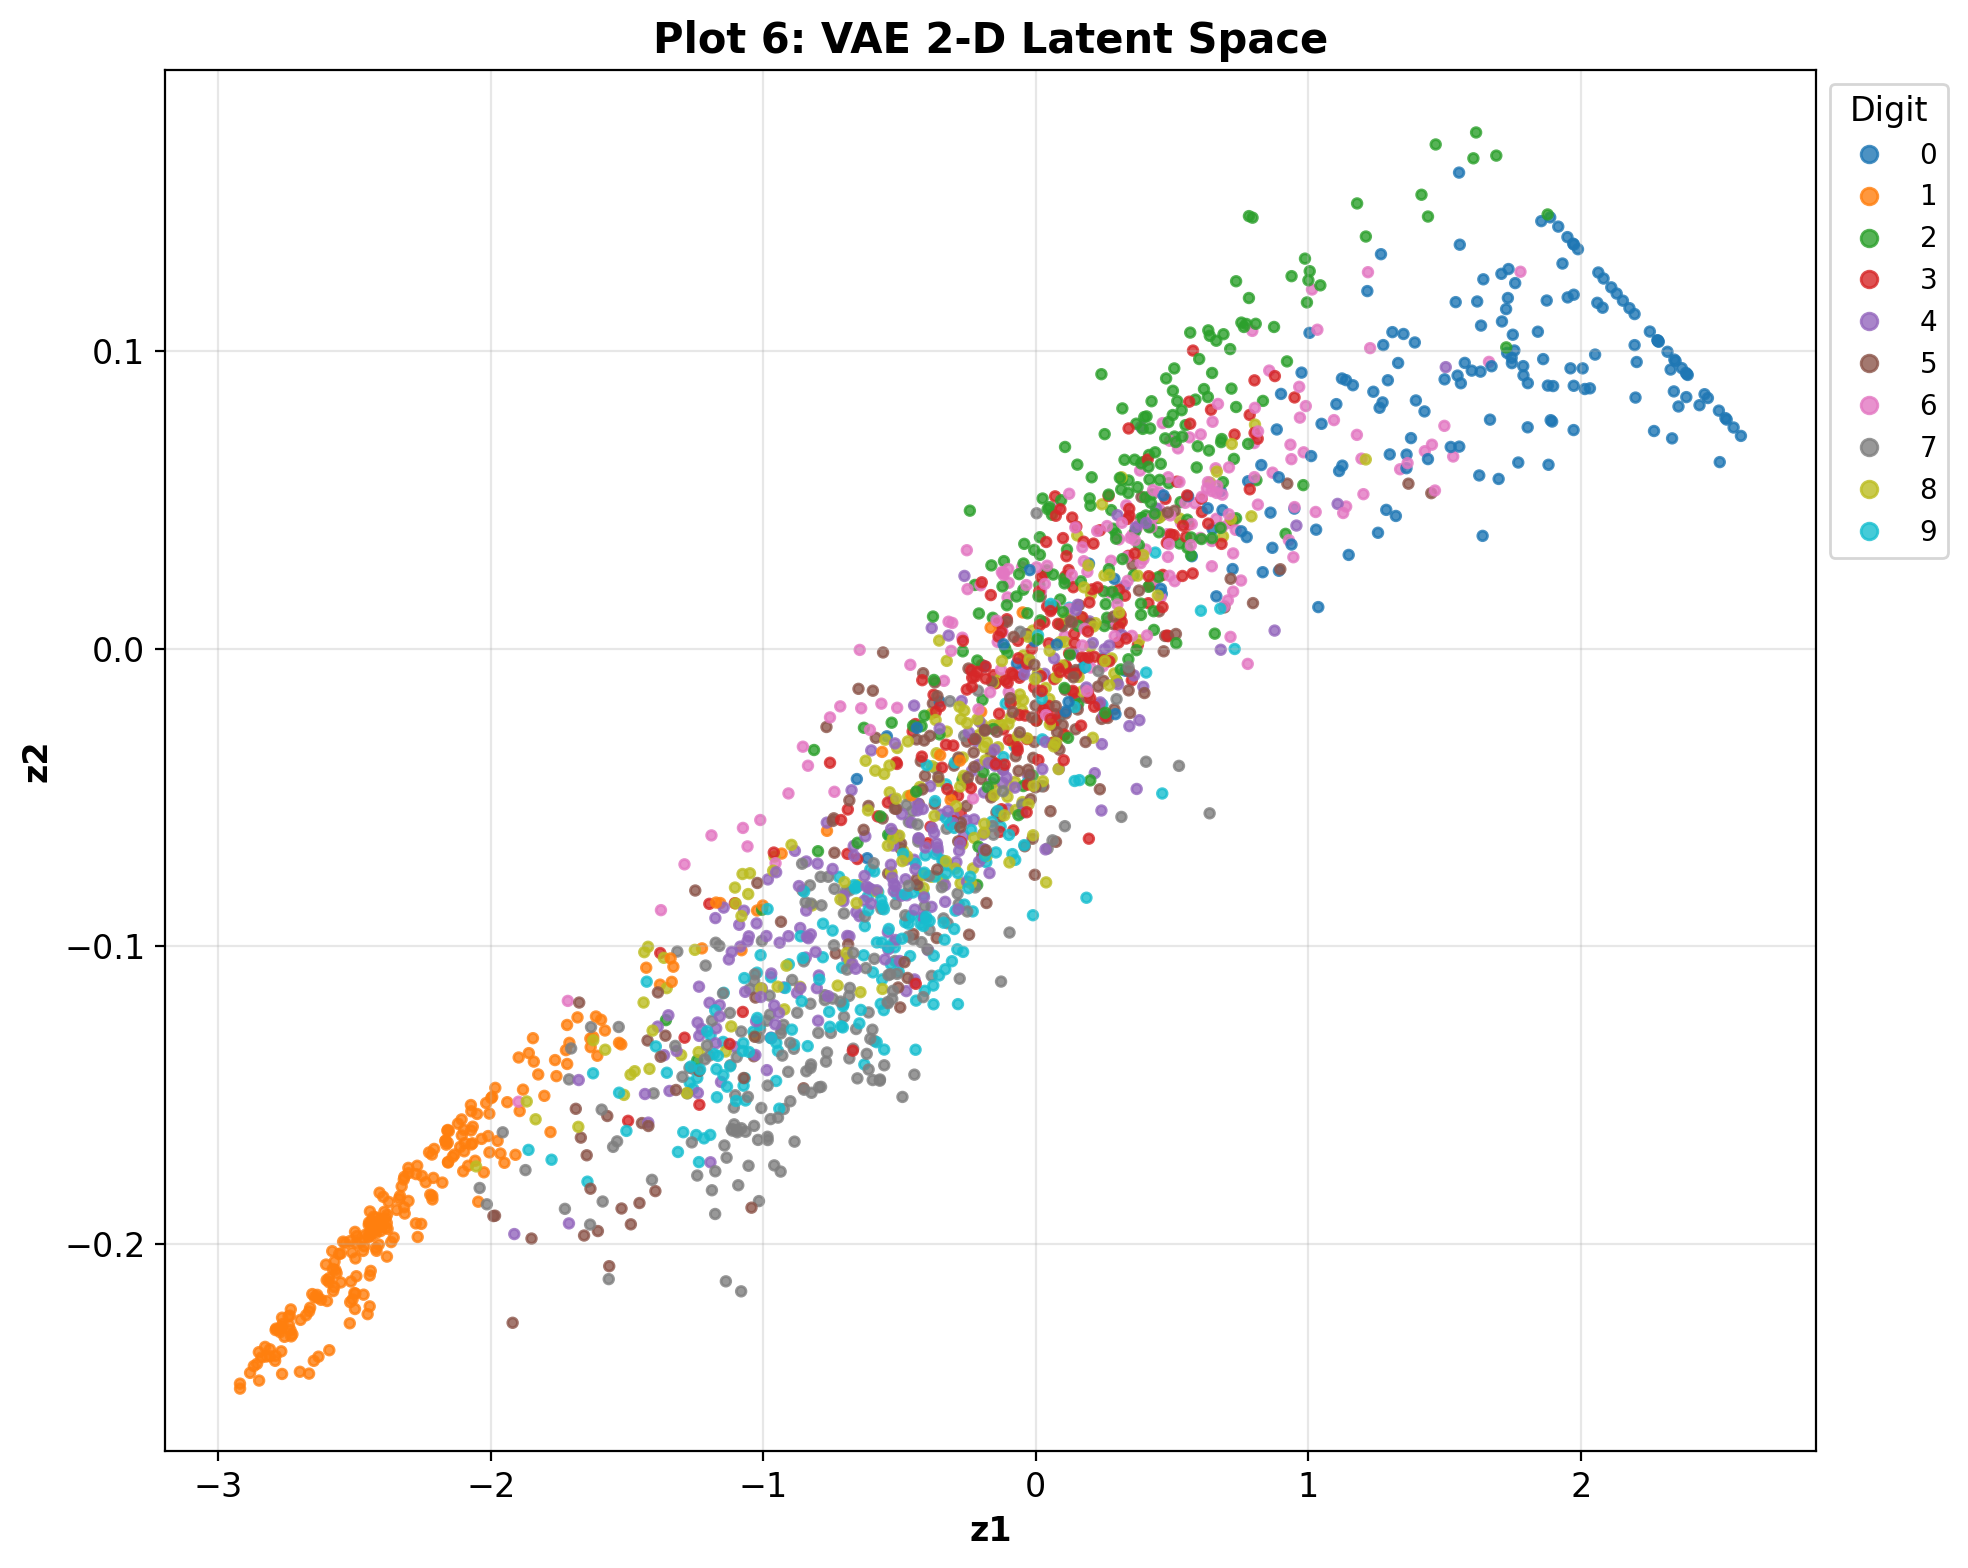

Saved: Experiment_7_Results/07_VAE_generated.png | DPI=200


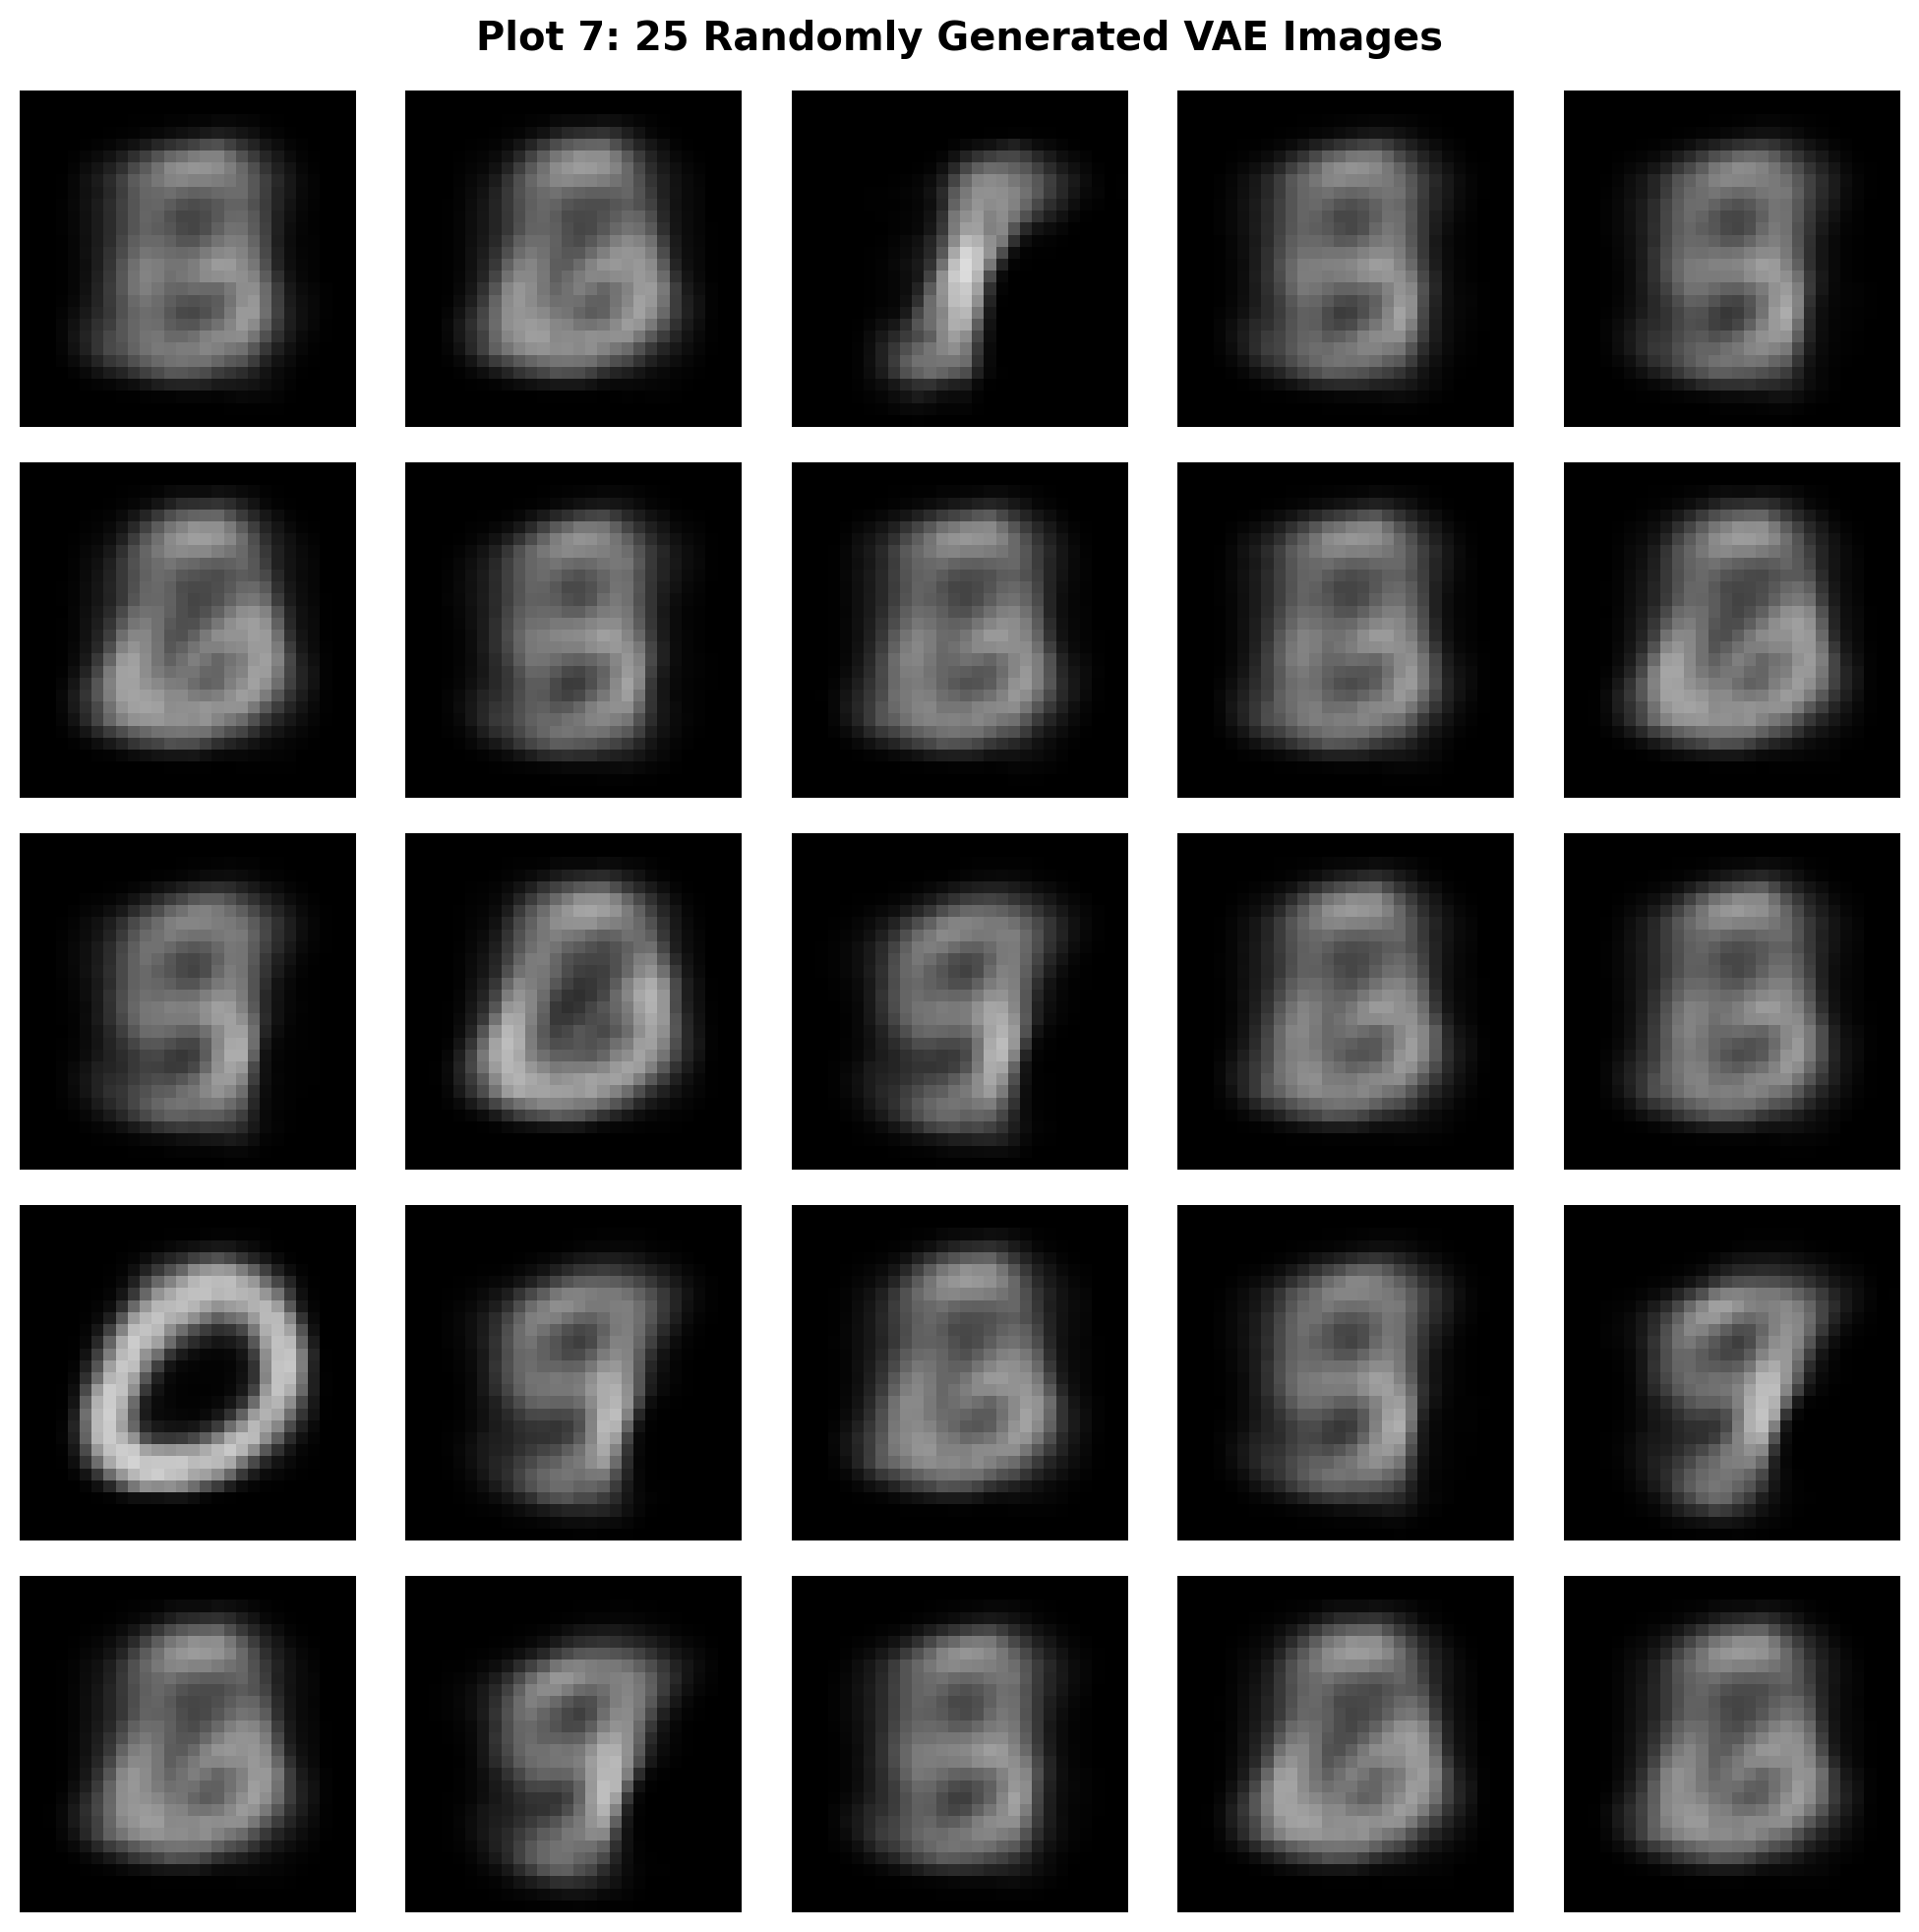

Saved: Experiment_7_Results/08_VAE_interpolation.png | DPI=200


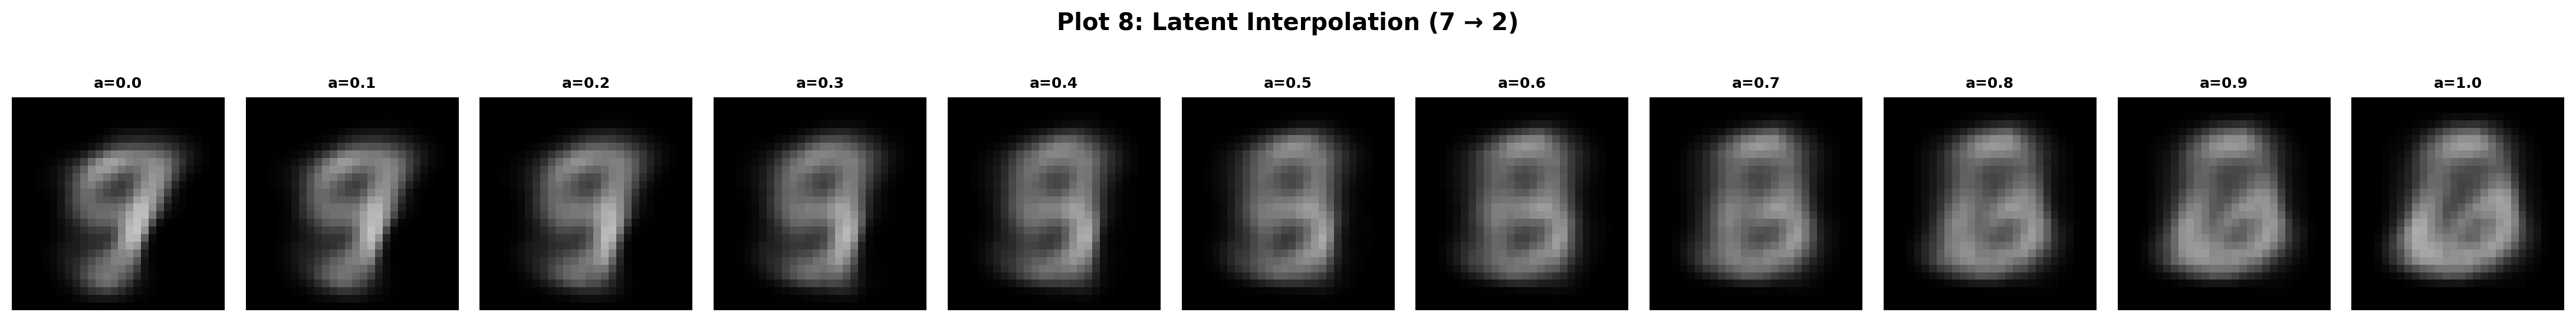

Saved: Experiment_7_Results/09_VAE_loss.png | DPI=200


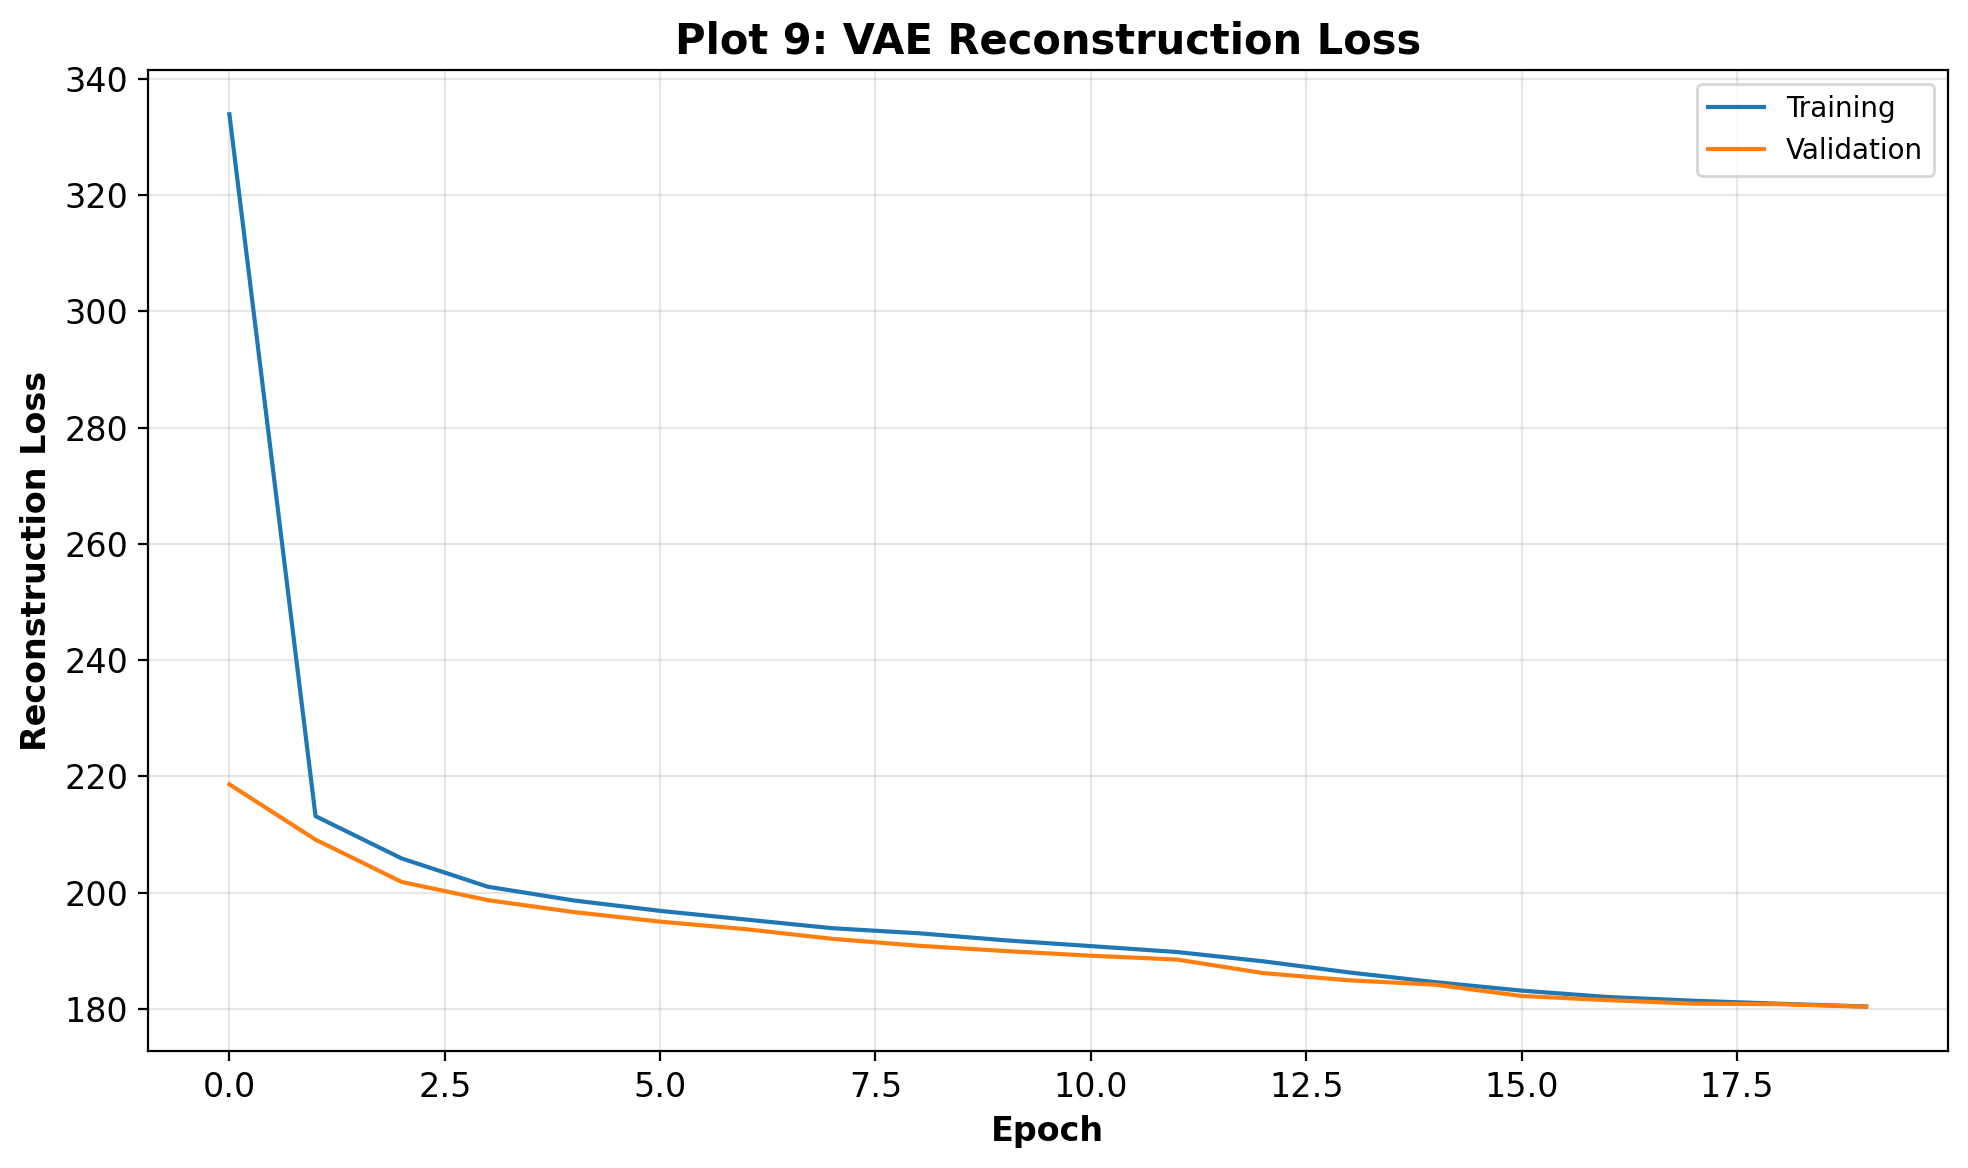

Saved: Experiment_7_Results/09b_VAE_loss_components.png | DPI=200


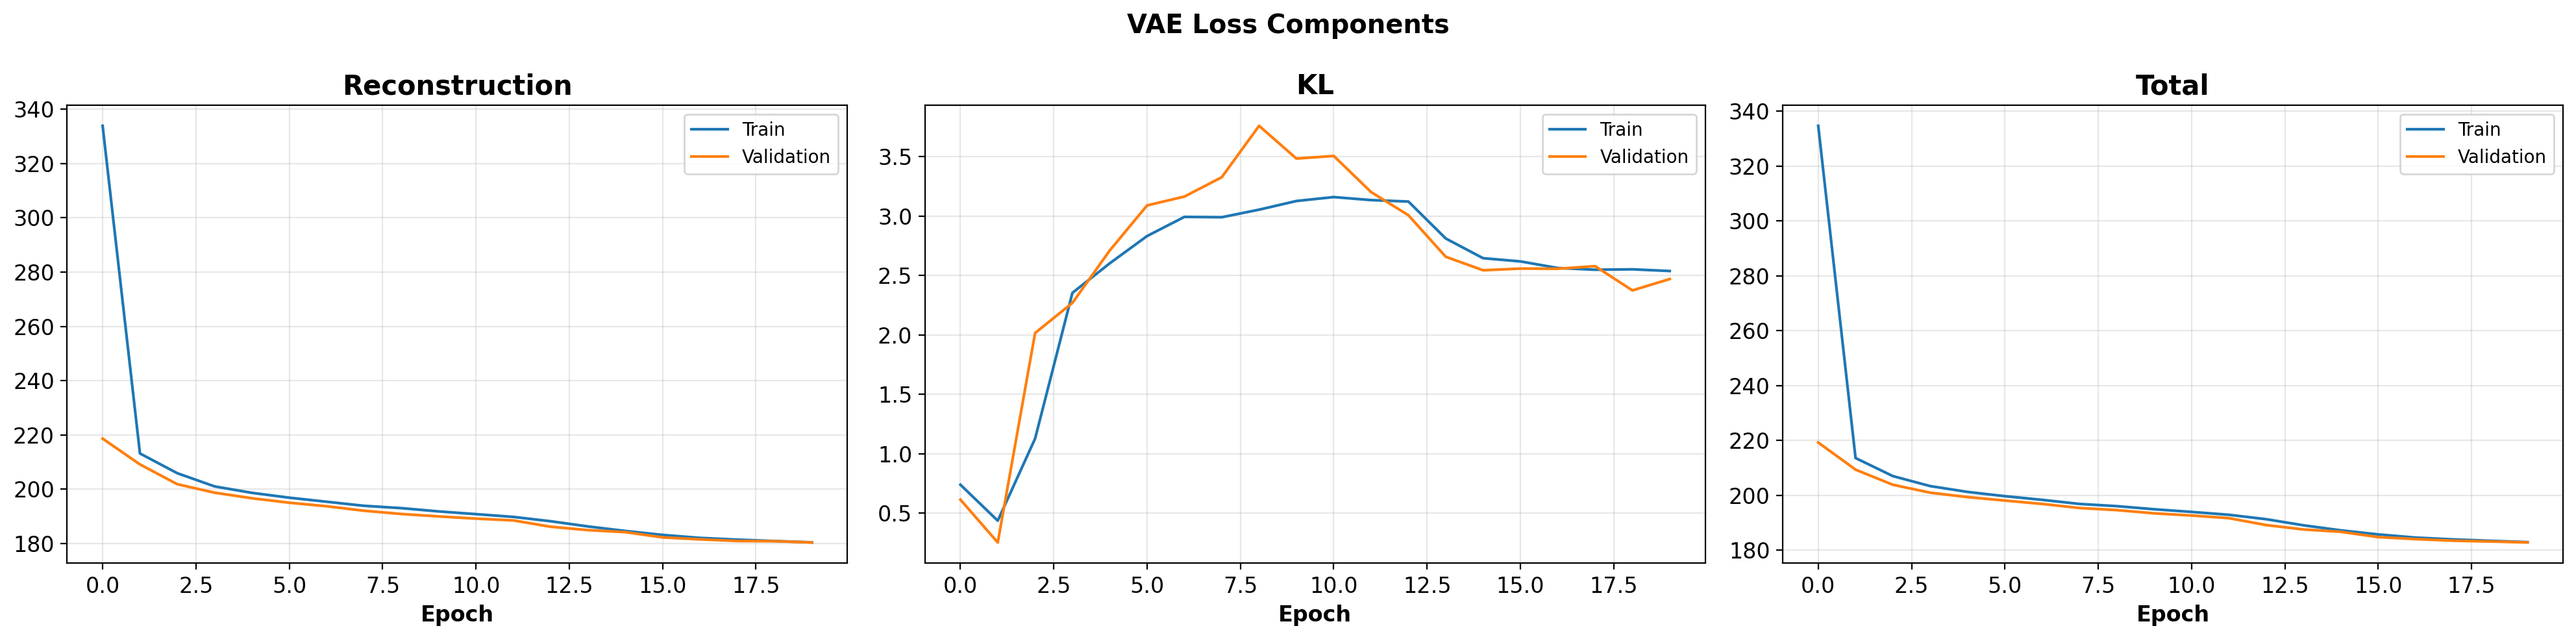

In [12]:
# Plot 6: latent space
z_mu,z_logvar,_=encoder.predict(x_test_cnn,verbose=0)
fig,ax=plt.subplots(figsize=(10,8)); sc=ax.scatter(z_mu[:,0],z_mu[:,1],c=y_test,cmap="tab10",s=12,alpha=.8); ax.set(xlabel="z1",ylabel="z2",title="Plot 6: VAE 2-D Latent Space"); ax.legend(*sc.legend_elements(),title="Digit",bbox_to_anchor=(1,1)); ax.grid(alpha=.3); save_fig(fig,"06_VAE_latent.png"); plt.show()

# Plot 7: 25 generated samples
rng=np.random.default_rng(SEED); gen25=decoder.predict(rng.normal(size=(25,2)).astype("float32"),verbose=0)
fig,ax=plt.subplots(5,5,figsize=(10,10))
for i,a in enumerate(ax.flat): a.imshow(gen25[i].squeeze(),cmap="gray",vmin=0,vmax=1); a.axis("off")
fig.suptitle("Plot 7: 25 Randomly Generated VAE Images",fontweight="bold"); save_fig(fig,"07_VAE_generated.png"); plt.show()

# Plot 8: interpolation between two test latent points
za,zb=z_mu[0],z_mu[1]; alphas=np.linspace(0,1,11); zint=np.array([(1-a)*za+a*zb for a in alphas],dtype="float32"); intimgs=decoder.predict(zint,verbose=0)
fig,ax=plt.subplots(1,11,figsize=(22,3))
for i,a in enumerate(ax): a.imshow(intimgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); a.set_title(f"a={alphas[i]:.1f}",fontsize=9); a.axis("off")
fig.suptitle(f"Plot 8: Latent Interpolation ({y_test[0]} → {y_test[1]})",fontweight="bold"); save_fig(fig,"08_VAE_interpolation.png"); plt.show()

# Plot 9: VAE reconstruction loss
fig,ax=plt.subplots(figsize=(10,6)); ax.plot(vae_history.history["reconstruction_loss"],label="Training"); ax.plot(vae_history.history["val_reconstruction_loss"],label="Validation"); ax.set(xlabel="Epoch",ylabel="Reconstruction Loss",title="Plot 9: VAE Reconstruction Loss"); ax.legend(); ax.grid(alpha=.3); save_fig(fig,"09_VAE_loss.png"); plt.show()

# Detailed VAE loss components
fig,ax=plt.subplots(1,3,figsize=(20,5))
for a,tr,va,title in zip(ax,["reconstruction_loss","kl_loss","loss"],["val_reconstruction_loss","val_kl_loss","val_loss"],["Reconstruction","KL","Total"]): a.plot(vae_history.history[tr],label="Train"); a.plot(vae_history.history[va],label="Validation"); a.set(title=title,xlabel="Epoch"); a.legend(); a.grid(alpha=.3)
fig.suptitle("VAE Loss Components",fontweight="bold"); save_fig(fig,"09b_VAE_loss_components.png"); plt.show()

## 8. Reconstruction Error Distribution and Highest-Error Samples

Saved: Experiment_7_Results/09_Error_distribution.png | DPI=200


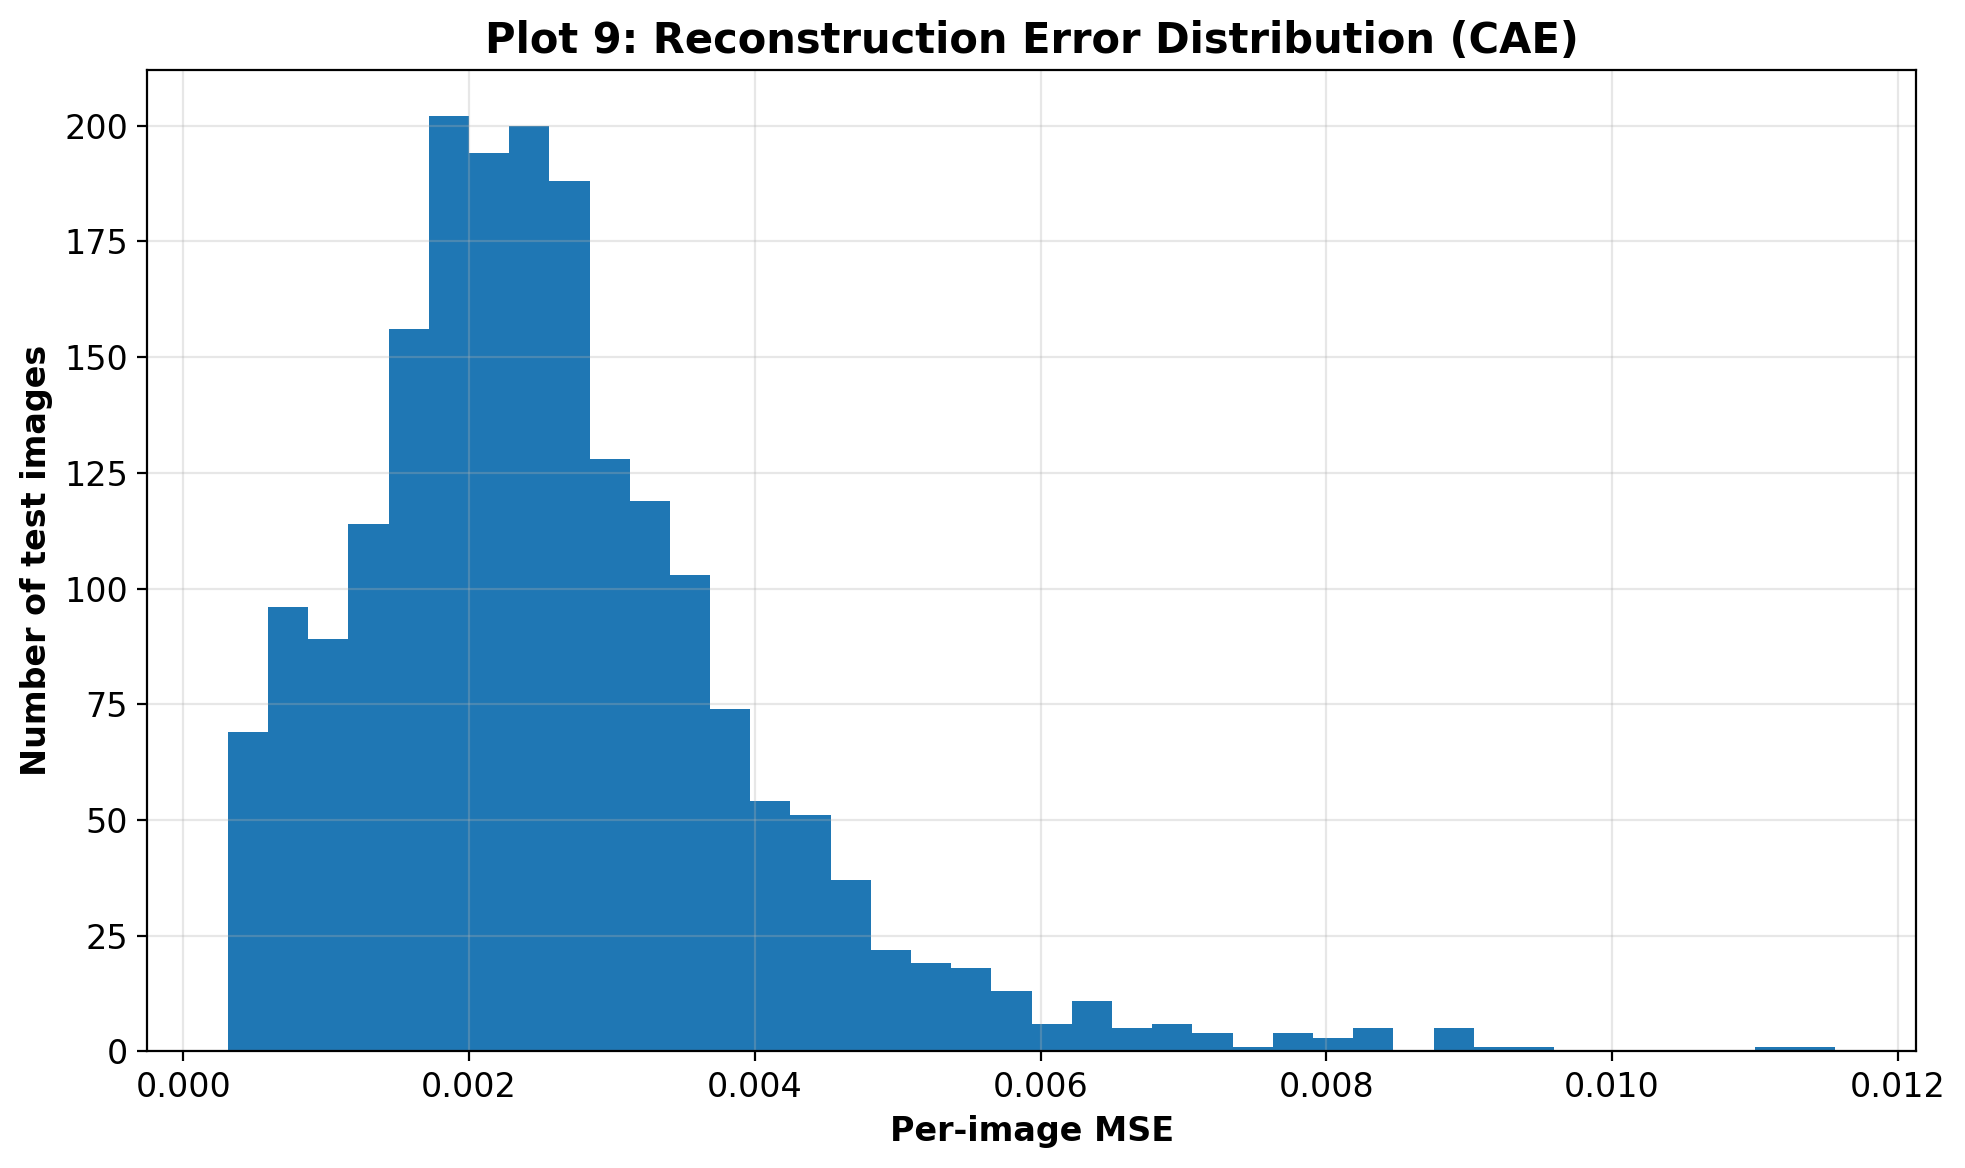

Mean: 0.0025928405 Std: 0.0014083569 Min: 0.00031112853 Max: 0.011563372
Saved: Experiment_7_Results/09b_High_error_samples.png | DPI=200


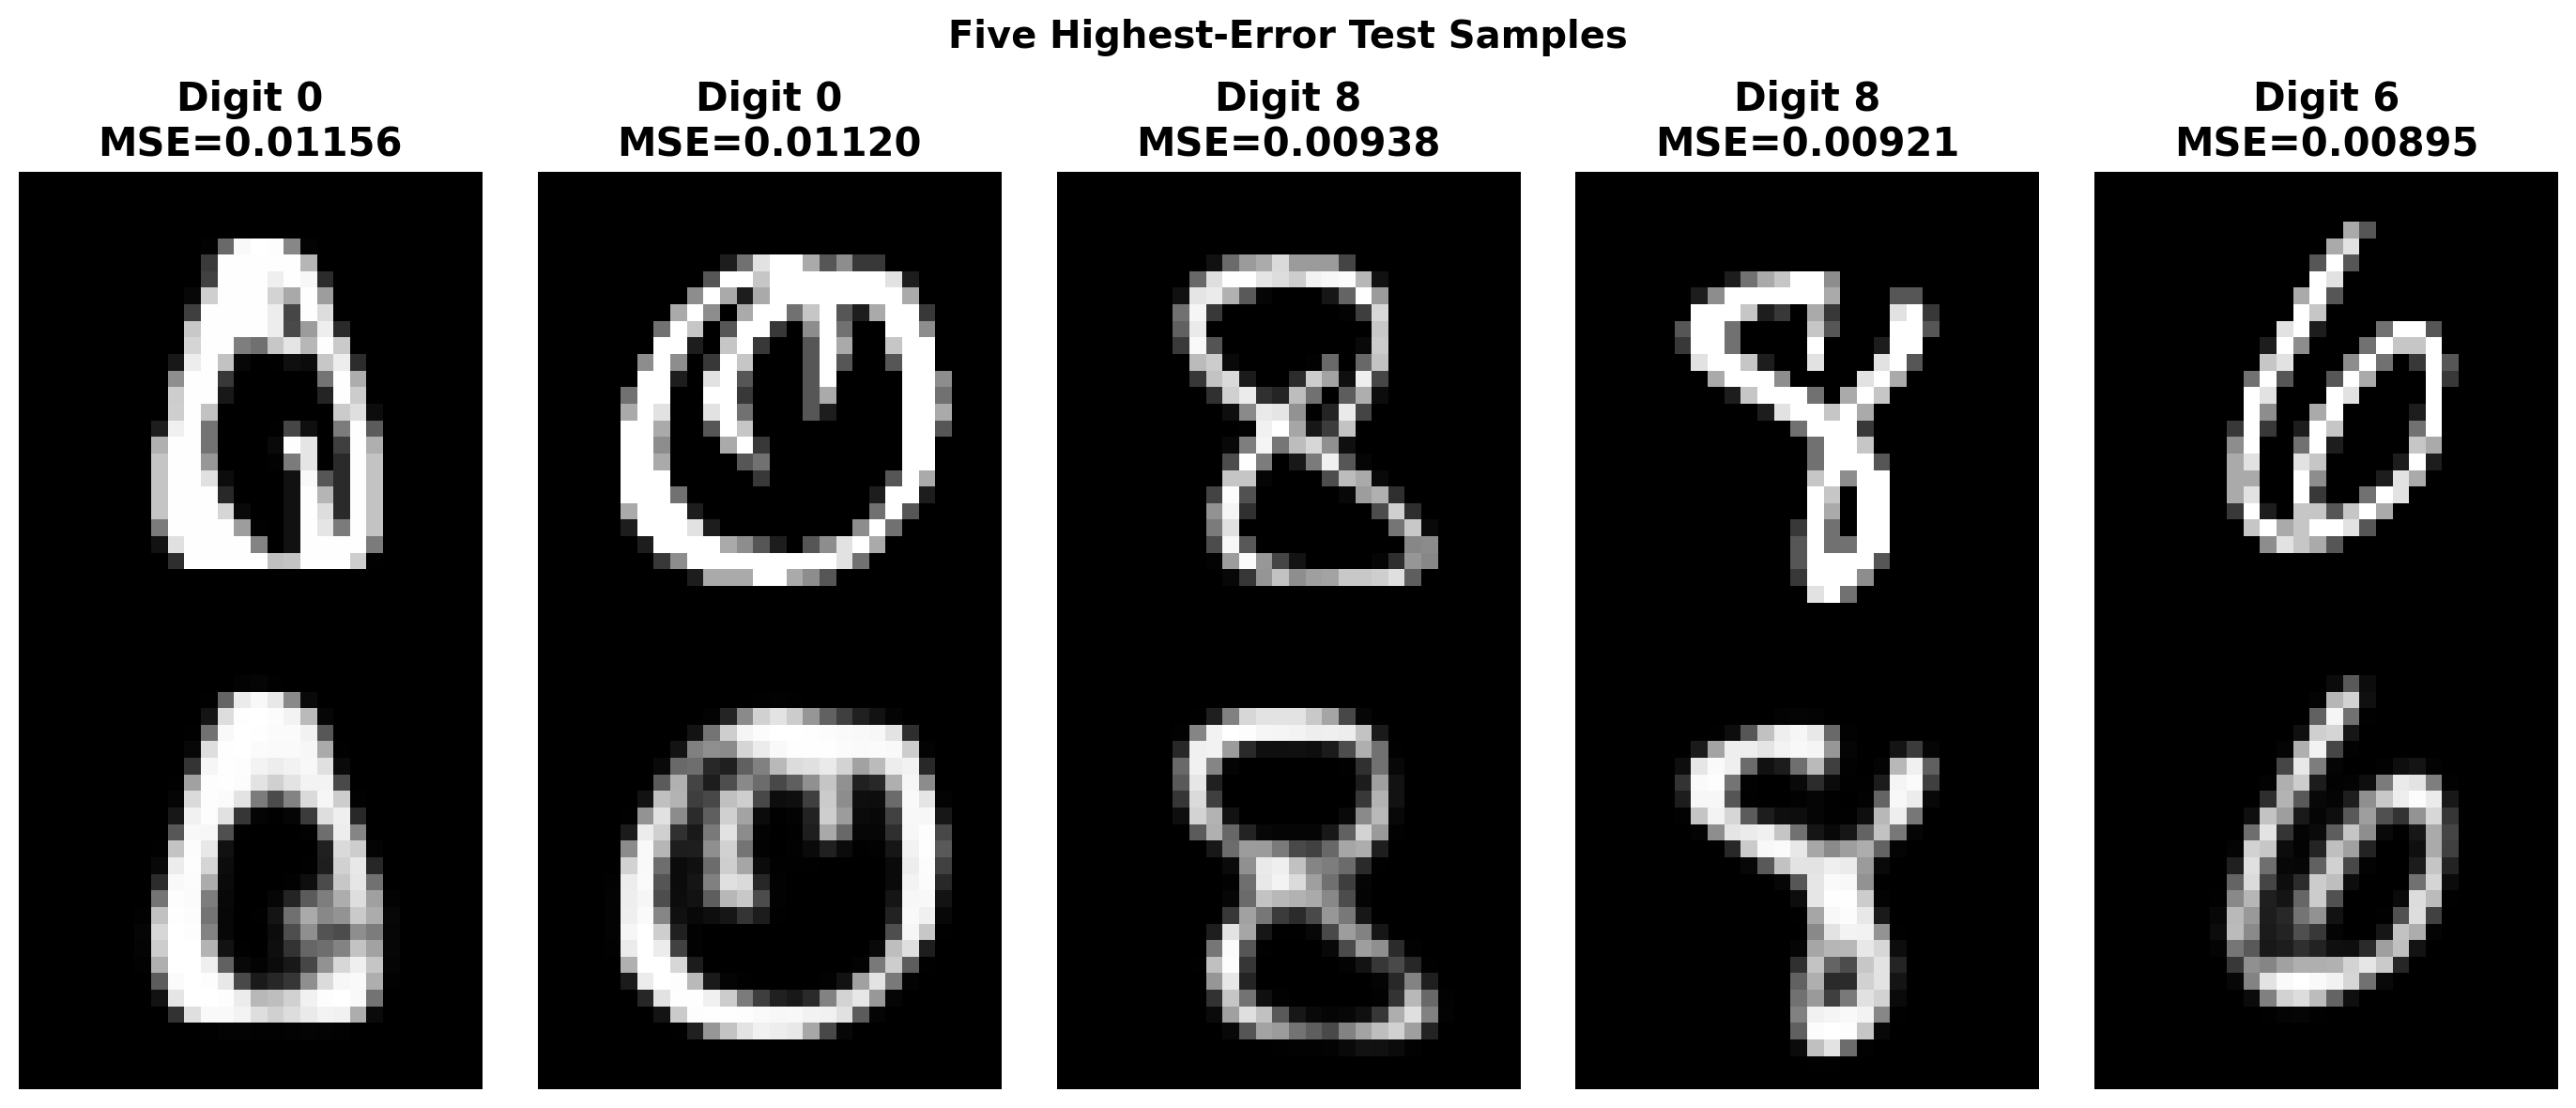

In [13]:
errors=per_image_mse(x_test_cnn,cae_recon)
fig,ax=plt.subplots(figsize=(10,6)); ax.hist(errors,bins=40); ax.set(xlabel="Per-image MSE",ylabel="Number of test images",title="Plot 9: Reconstruction Error Distribution (CAE)"); ax.grid(alpha=.3); save_fig(fig,"09_Error_distribution.png"); plt.show()
print("Mean:",errors.mean(),"Std:",errors.std(),"Min:",errors.min(),"Max:",errors.max())

top5=np.argsort(errors)[-5:][::-1]
fig,ax=plt.subplots(2,5,figsize=(14,6))
for j,idx in enumerate(top5):
    ax[0,j].imshow(x_test_cnn[idx].squeeze(),cmap="gray"); ax[0,j].set_title(f"Digit {y_test[idx]}\nMSE={errors[idx]:.5f}"); ax[1,j].imshow(cae_recon[idx].squeeze(),cmap="gray");
    ax[0,j].axis("off"); ax[1,j].axis("off")
ax[0,0].set_ylabel("Original",fontweight="bold"); ax[1,0].set_ylabel("Reconstructed",fontweight="bold")
fig.suptitle("Five Highest-Error Test Samples",fontweight="bold"); save_fig(fig,"09b_High_error_samples.png"); plt.show()

## 9. Consolidated Main-Model Results

                      MSE      MAE     SSIM  Parameters  Time (s)
FC Autoencoder    0.02239  0.05884  0.73280    211040.0  10.79631
Convolutional AE  0.00259  0.01511  0.97309     74497.0  18.40516
Denoising CAE     0.00468  0.02138  0.94422     74497.0  15.63018
VAE               0.05533  0.12939  0.30906    134165.0  20.97708
Saved: Experiment_7_Results/19a_Consolidated_results_table.png | DPI=200
Saved: Experiment_7_Results/15_VAE_final_metrics_table.png | DPI=200
Saved: Experiment_7_Results/16_Reconstruction_comparison_all_models.png | DPI=200


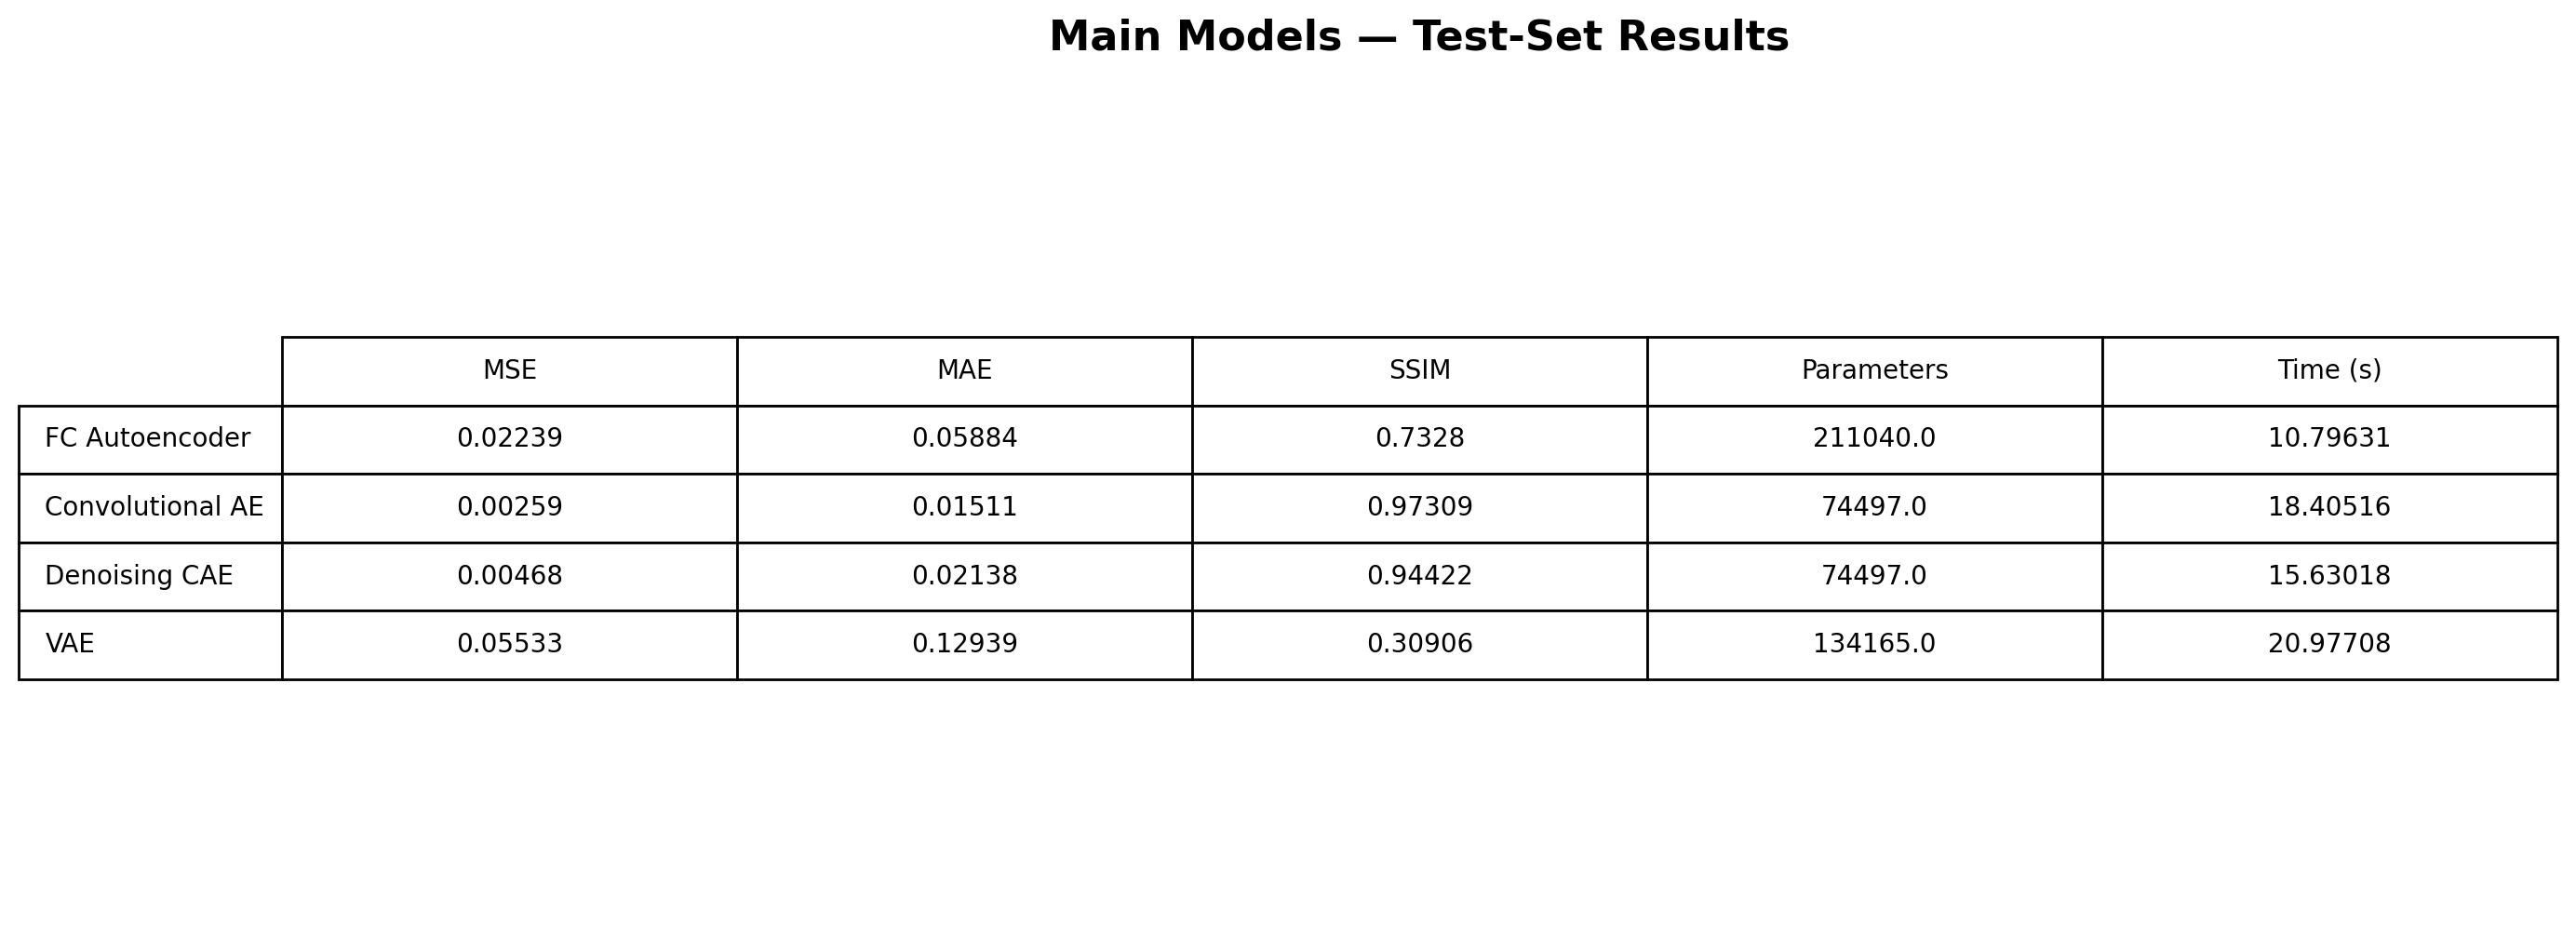

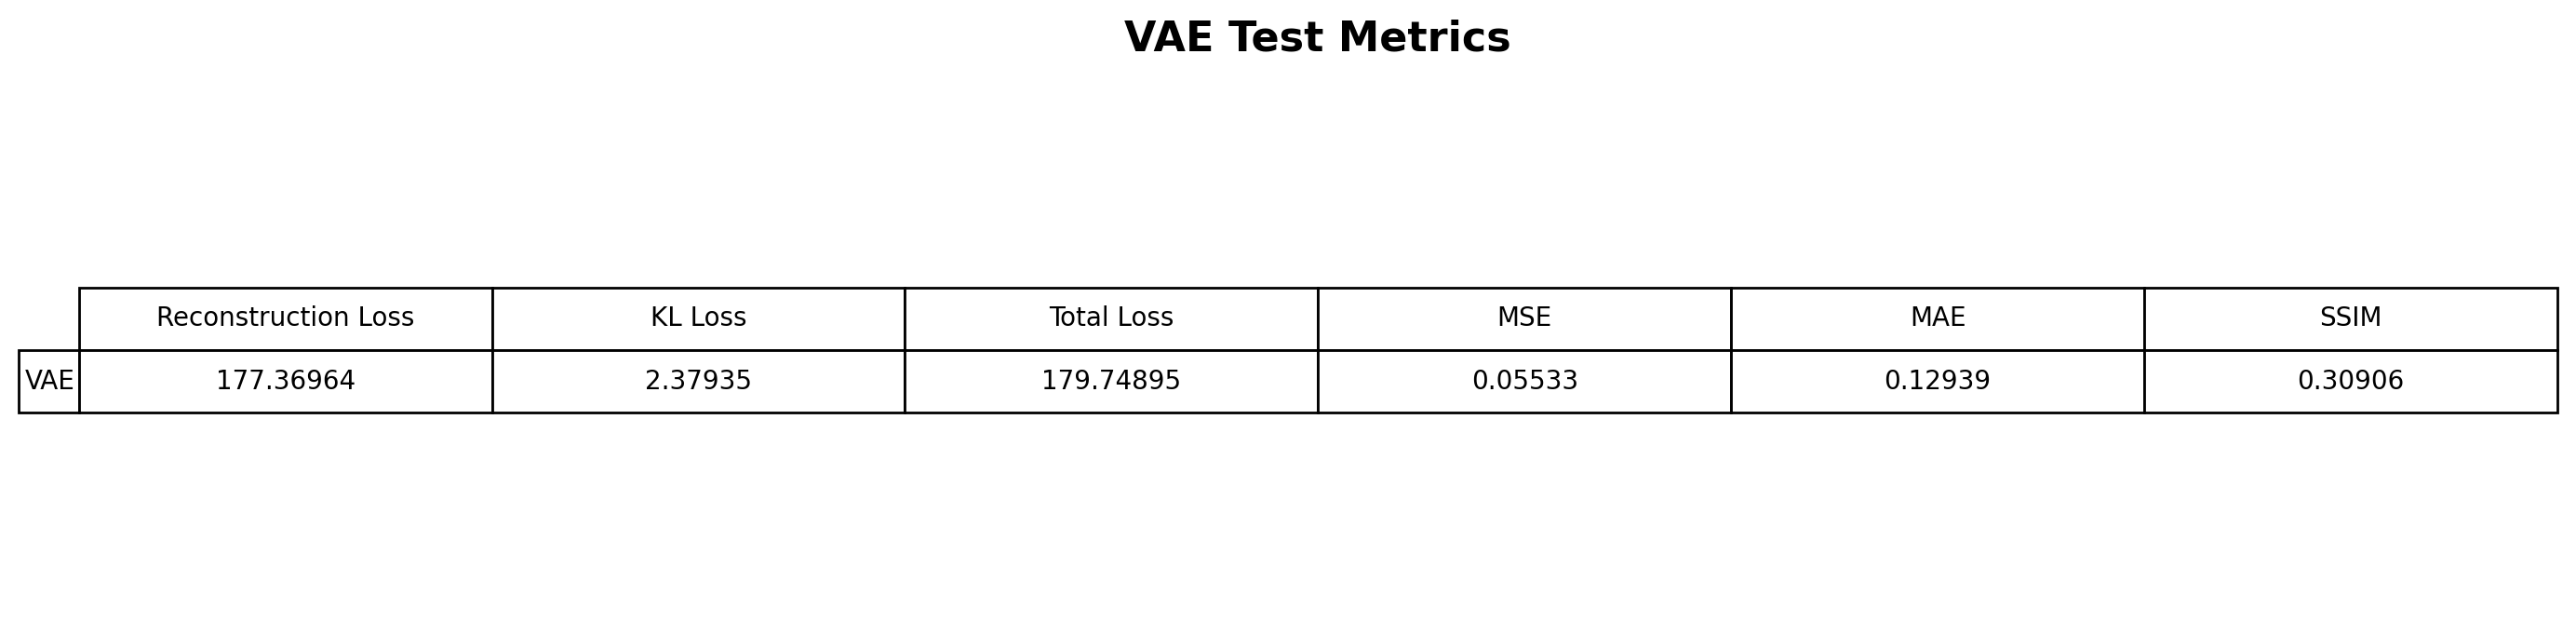

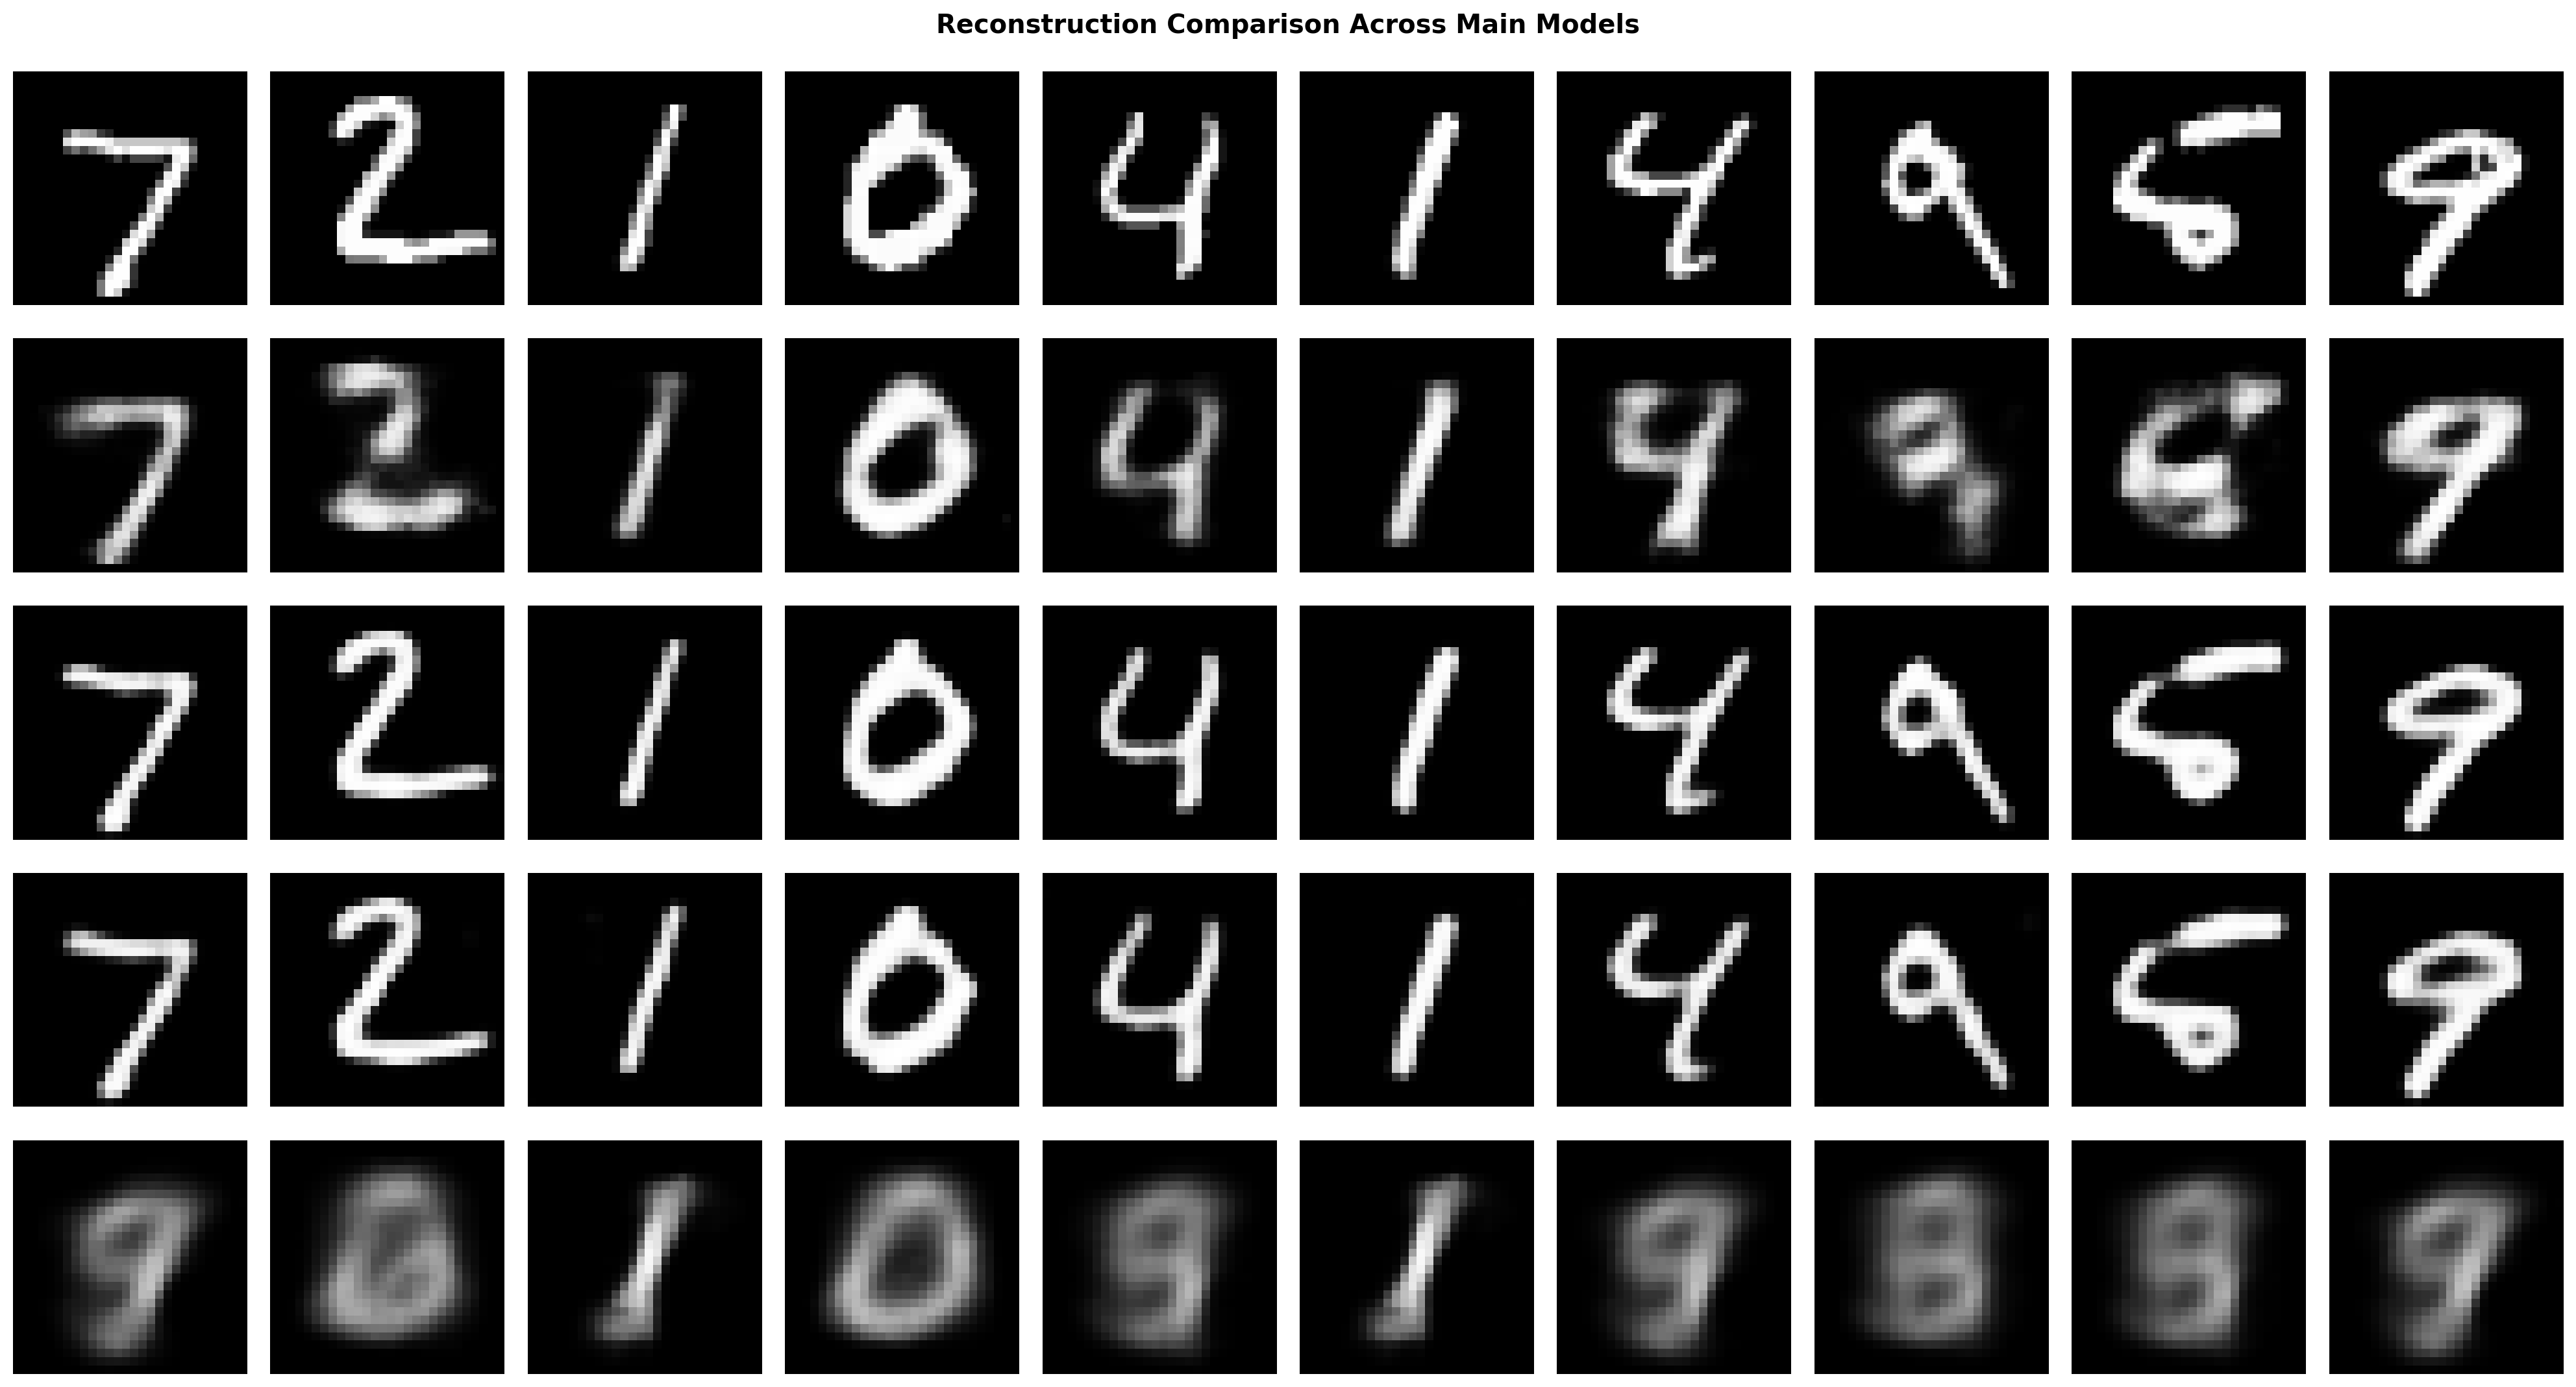

In [14]:
main_results=pd.DataFrame({
"FC Autoencoder":{**fc_metrics,"Parameters":count_params(fc_ae),"Time (s)":fc_time},
"Convolutional AE":{**cae_metrics,"Parameters":count_params(cae),"Time (s)":cae_time},
"Denoising CAE":{**denoise_metrics,"Parameters":count_params(denoise_ae),"Time (s)":denoise_time},
"VAE":{k:vae2[k] for k in ["MSE","MAE","SSIM"]}|{"Parameters":count_params(encoder)+count_params(decoder),"Time (s)":vae_time}
}).T
print(main_results.round(5).to_string())
save_table_png(main_results,"19a_Consolidated_results_table.png","Main Models — Test-Set Results")

# VAE-specific metrics
vae_table=pd.DataFrame([{"Reconstruction Loss":vae2["recon_loss"],"KL Loss":vae2["kl"],"Total Loss":vae2["total"],"MSE":vae2["MSE"],"MAE":vae2["MAE"],"SSIM":vae2["SSIM"]},],index=["VAE"])
save_table_png(vae_table,"15_VAE_final_metrics_table.png","VAE Test Metrics")

# Final reconstruction comparison
fig,ax=plt.subplots(5,n_show,figsize=(20,11))
for r,(lbl,imgs) in enumerate([("Original",x_test_cnn),("FC-AE",fc_recon),("CAE",cae_recon),("Denoising CAE",denoised),("VAE",vae2["recon"])]):
    for i in range(n_show): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); ax[r,i].axis("off")
    ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Reconstruction Comparison Across Main Models",fontweight="bold"); save_fig(fig,"16_Reconstruction_comparison_all_models.png"); plt.show()

## 10. Additional Exercise 1 — CAE Latent Dimensions 4, 8, 16, 32

4 {'MSE': 0.03476893901824951, 'MAE': 0.08358476310968399, 'SSIM': 0.6152830426480862} Params 65797 Time 16.5
8 {'MSE': 0.02097204513847828, 'MAE': 0.05545599013566971, 'SSIM': 0.7621918750194707} Params 90889 Time 16.5
16 {'MSE': 0.011146367527544498, 'MAE': 0.03462011367082596, 'SSIM': 0.8805565586934551} Params 141073 Time 16.6
32 {'MSE': 0.00658191554248333, 'MAE': 0.024884020909667015, 'SSIM': 0.9299808996574118} Params 241441 Time 16.5
                      MSE      MAE     SSIM  Parameters  Time (s)
Latent Dimension                                                 
4                 0.03477  0.08358  0.61528       65797  16.52931
8                 0.02097  0.05546  0.76219       90889  16.48152
16                0.01115  0.03462  0.88056      141073  16.58236
32                0.00658  0.02488  0.92998      241441  16.47920
Saved: Experiment_7_Results/20_CAE_latent_dim_MSE.png | DPI=200


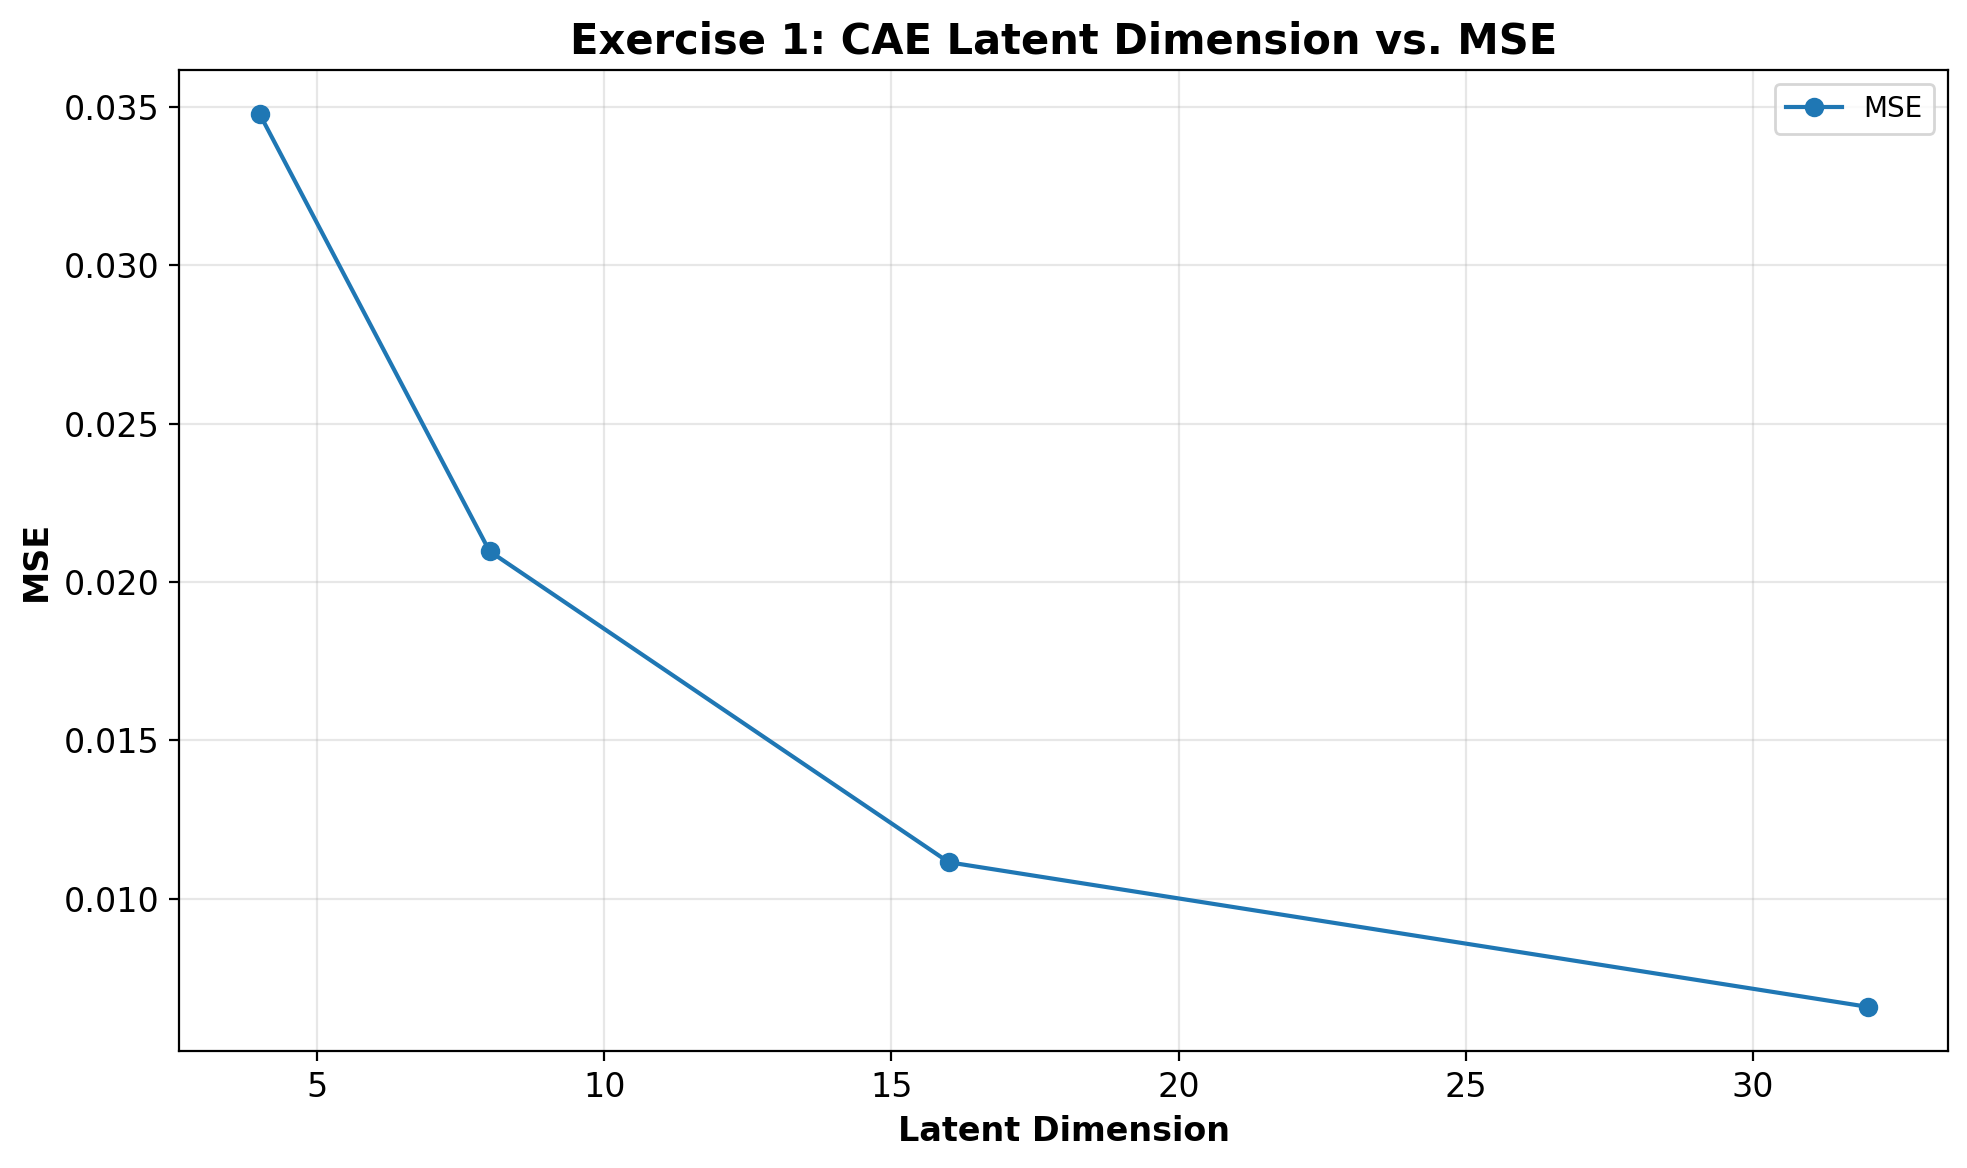

Saved: Experiment_7_Results/21_CAE_latent_dim_reconstructions.png | DPI=200


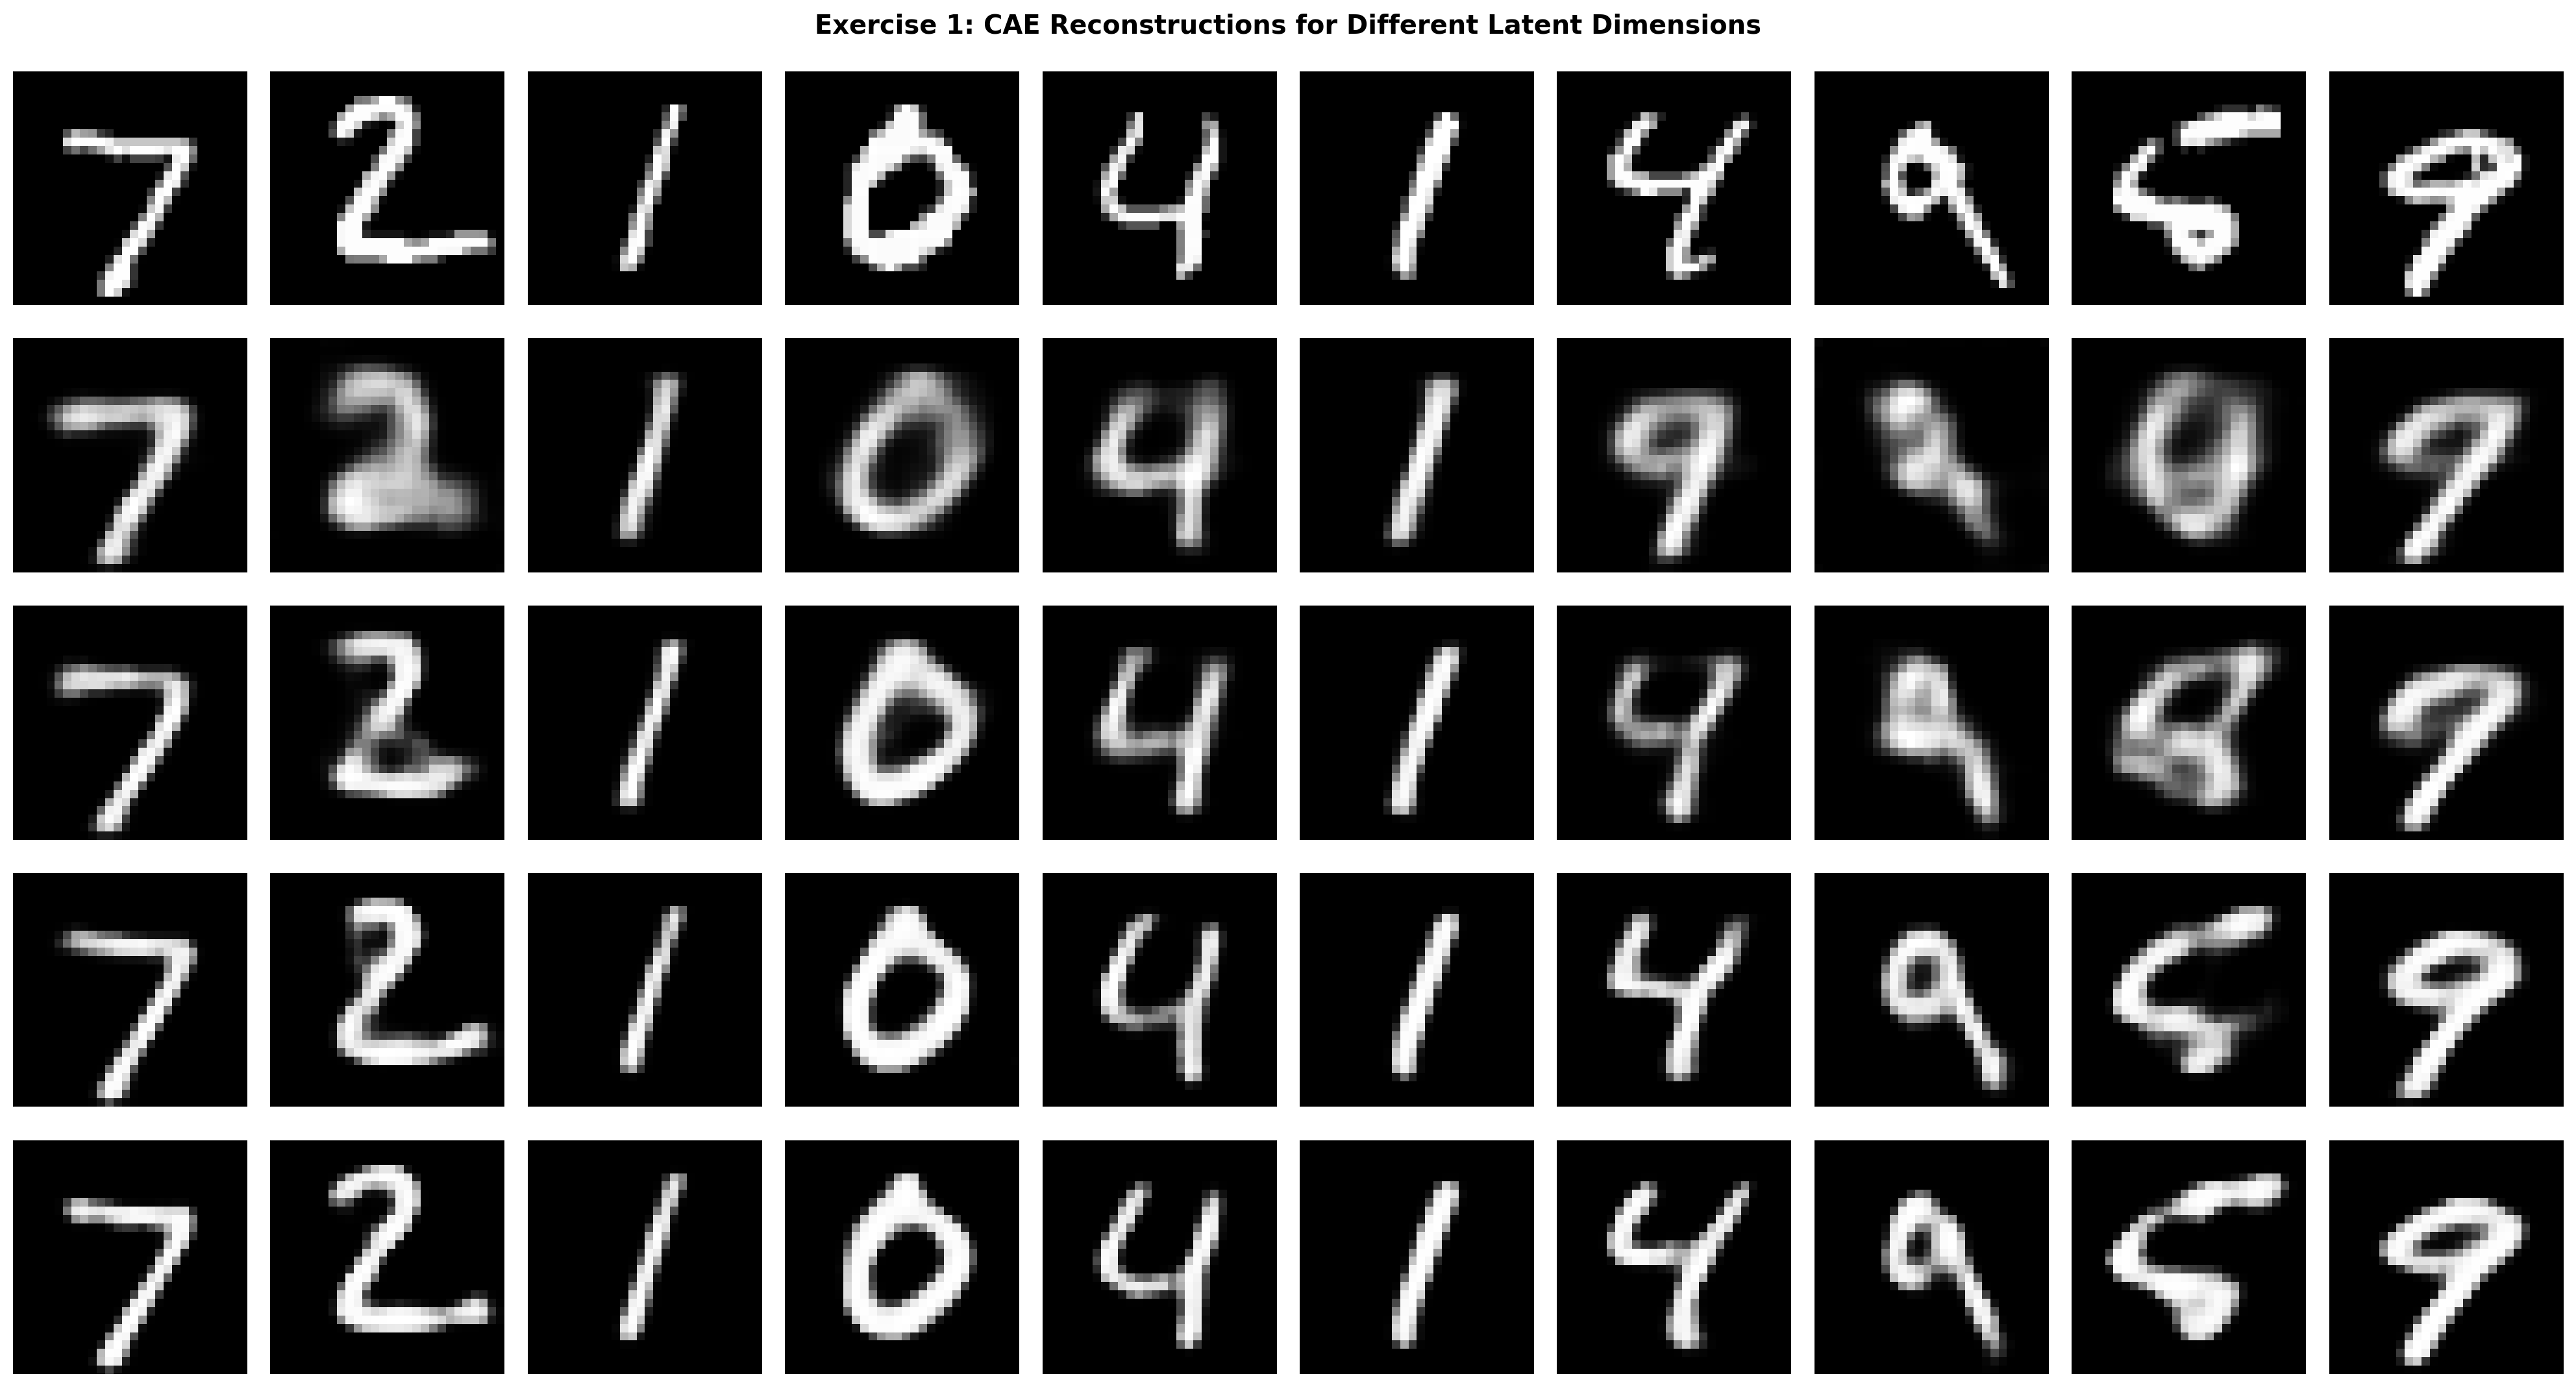

In [15]:
def build_cae_dense_latent(d):
    inp=Input((28,28,1)); x=layers.Conv2D(32,3,activation="relu",padding="same")(inp); x=layers.MaxPooling2D(2,padding="same")(x); x=layers.Conv2D(64,3,activation="relu",padding="same")(x); x=layers.MaxPooling2D(2,padding="same")(x); x=layers.Flatten()(x); z=layers.Dense(d)(x); x=layers.Dense(7*7*64,activation="relu")(z); x=layers.Reshape((7,7,64))(x); x=layers.UpSampling2D(2)(x); x=layers.Conv2D(32,3,activation="relu",padding="same")(x); x=layers.UpSampling2D(2)(x); out=layers.Conv2D(1,3,activation="sigmoid",padding="same")(x); m=Model(inp,out); m.compile(optimizer=keras.optimizers.Adam(1e-3),loss="binary_crossentropy"); return m

cae_lat_runs={}
for d in [4,8,16,32]:
    keras.utils.set_random_seed(SEED+d); m=build_cae_dense_latent(d); t0=time.time(); h=m.fit(x_tr_cnn,x_tr_cnn,validation_data=(x_val_cnn,x_val_cnn),epochs=20,batch_size=128,verbose=0); dt=time.time()-t0; rec=m.predict(x_test_cnn,verbose=0); cae_lat_runs[d]=(m,h,rec,dt)
    print(d,metrics_dict(x_test_cnn,rec),"Params",count_params(m),"Time",round(dt,1))
cae_lat_df=pd.DataFrame([{**{"Latent Dimension":d},**metrics_dict(x_test_cnn,cae_lat_runs[d][2]),"Parameters":count_params(cae_lat_runs[d][0]),"Time (s)":cae_lat_runs[d][3]} for d in cae_lat_runs]).set_index("Latent Dimension")
print(cae_lat_df.round(5)); cae_lat_df.to_csv(os.path.join(RESULTS_DIR,"cae_latent_dimension_study.csv"))
fig,ax=plt.subplots(figsize=(10,6)); ax.plot(cae_lat_df.index,cae_lat_df["MSE"],marker="o",label="MSE"); ax.set(xlabel="Latent Dimension",ylabel="MSE",title="Exercise 1: CAE Latent Dimension vs. MSE"); ax.grid(alpha=.3); ax.legend(); save_fig(fig,"20_CAE_latent_dim_MSE.png"); plt.show()
fig,ax=plt.subplots(5,n_show,figsize=(20,11))
for r,(lbl,imgs) in enumerate([("Original",x_test_cnn)]+[(f"d={d}",cae_lat_runs[d][2]) for d in cae_lat_runs]):
    for i in range(n_show): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray"); ax[r,i].axis("off")
    ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Exercise 1: CAE Reconstructions for Different Latent Dimensions",fontweight="bold"); save_fig(fig,"21_CAE_latent_dim_reconstructions.png"); plt.show()

## 11. Additional Exercise 2 — Gaussian vs. Salt-and-Pepper Noise
The same CAE architecture is used for both corruption types. Both models use proper train/validation splits and are evaluated on the untouched test set.

                        MSE      MAE     SSIM
Noise                                        
Gaussian sigma=0.2  0.00468  0.02138  0.94422
S&P p=0.10          0.00501  0.02152  0.94284
Saved: Experiment_7_Results/22_Gaussian_vs_SP_table.png | DPI=200
Saved: Experiment_7_Results/22_Gaussian_vs_SP.png | DPI=200


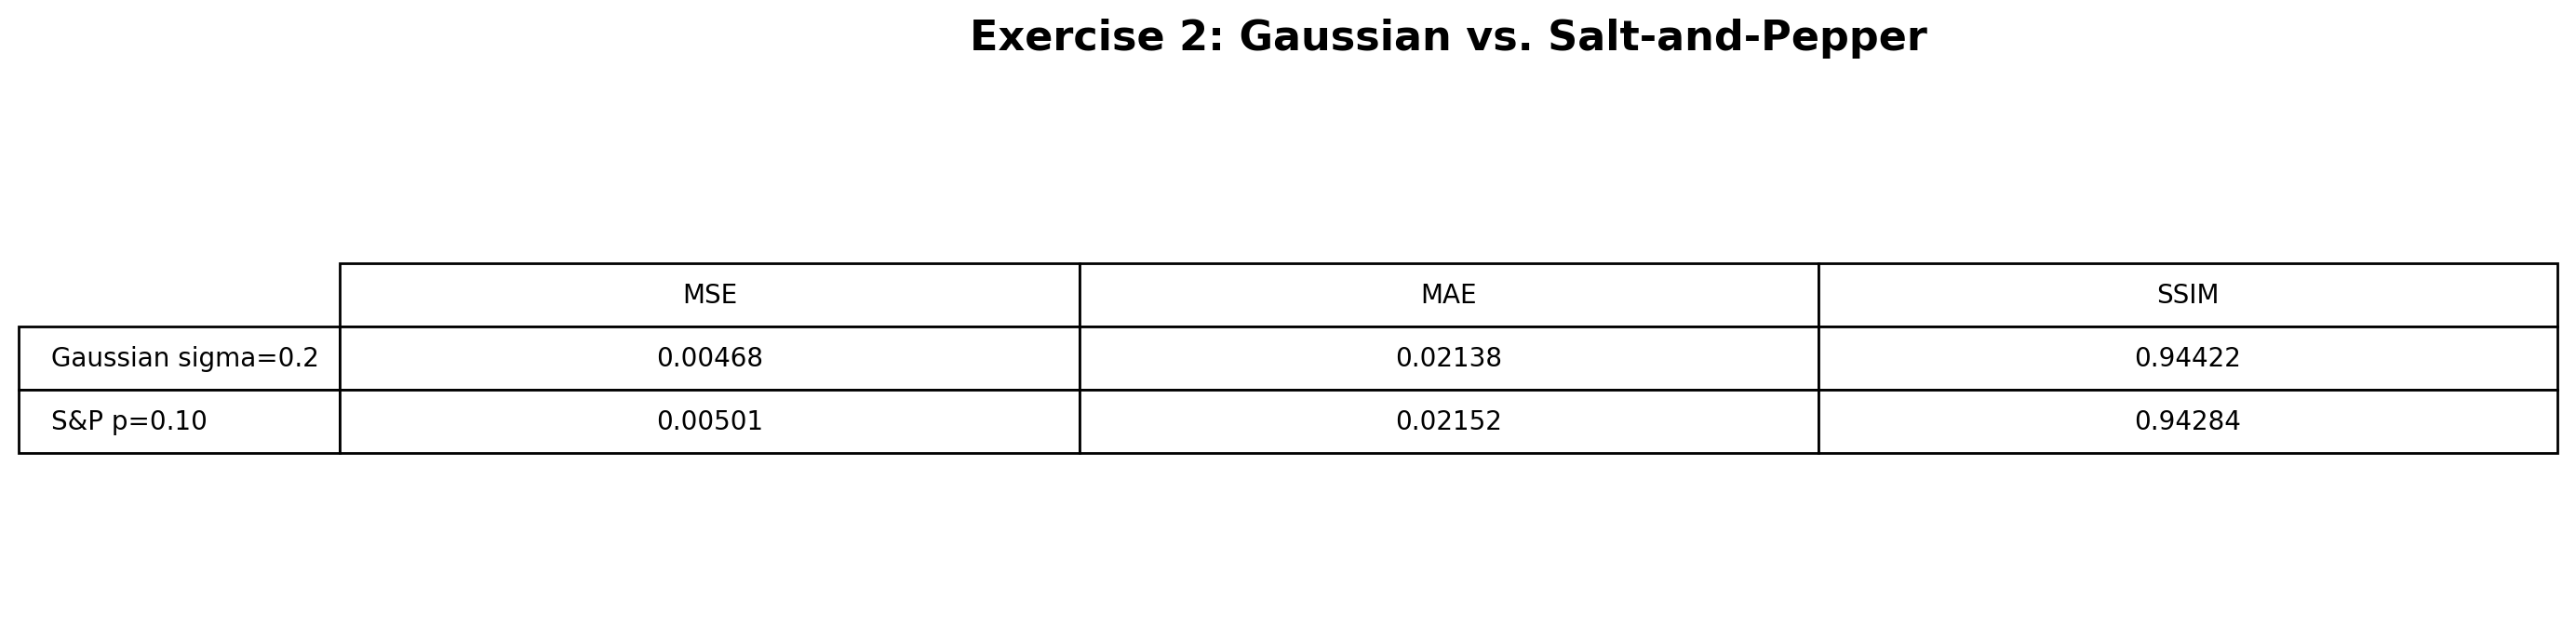

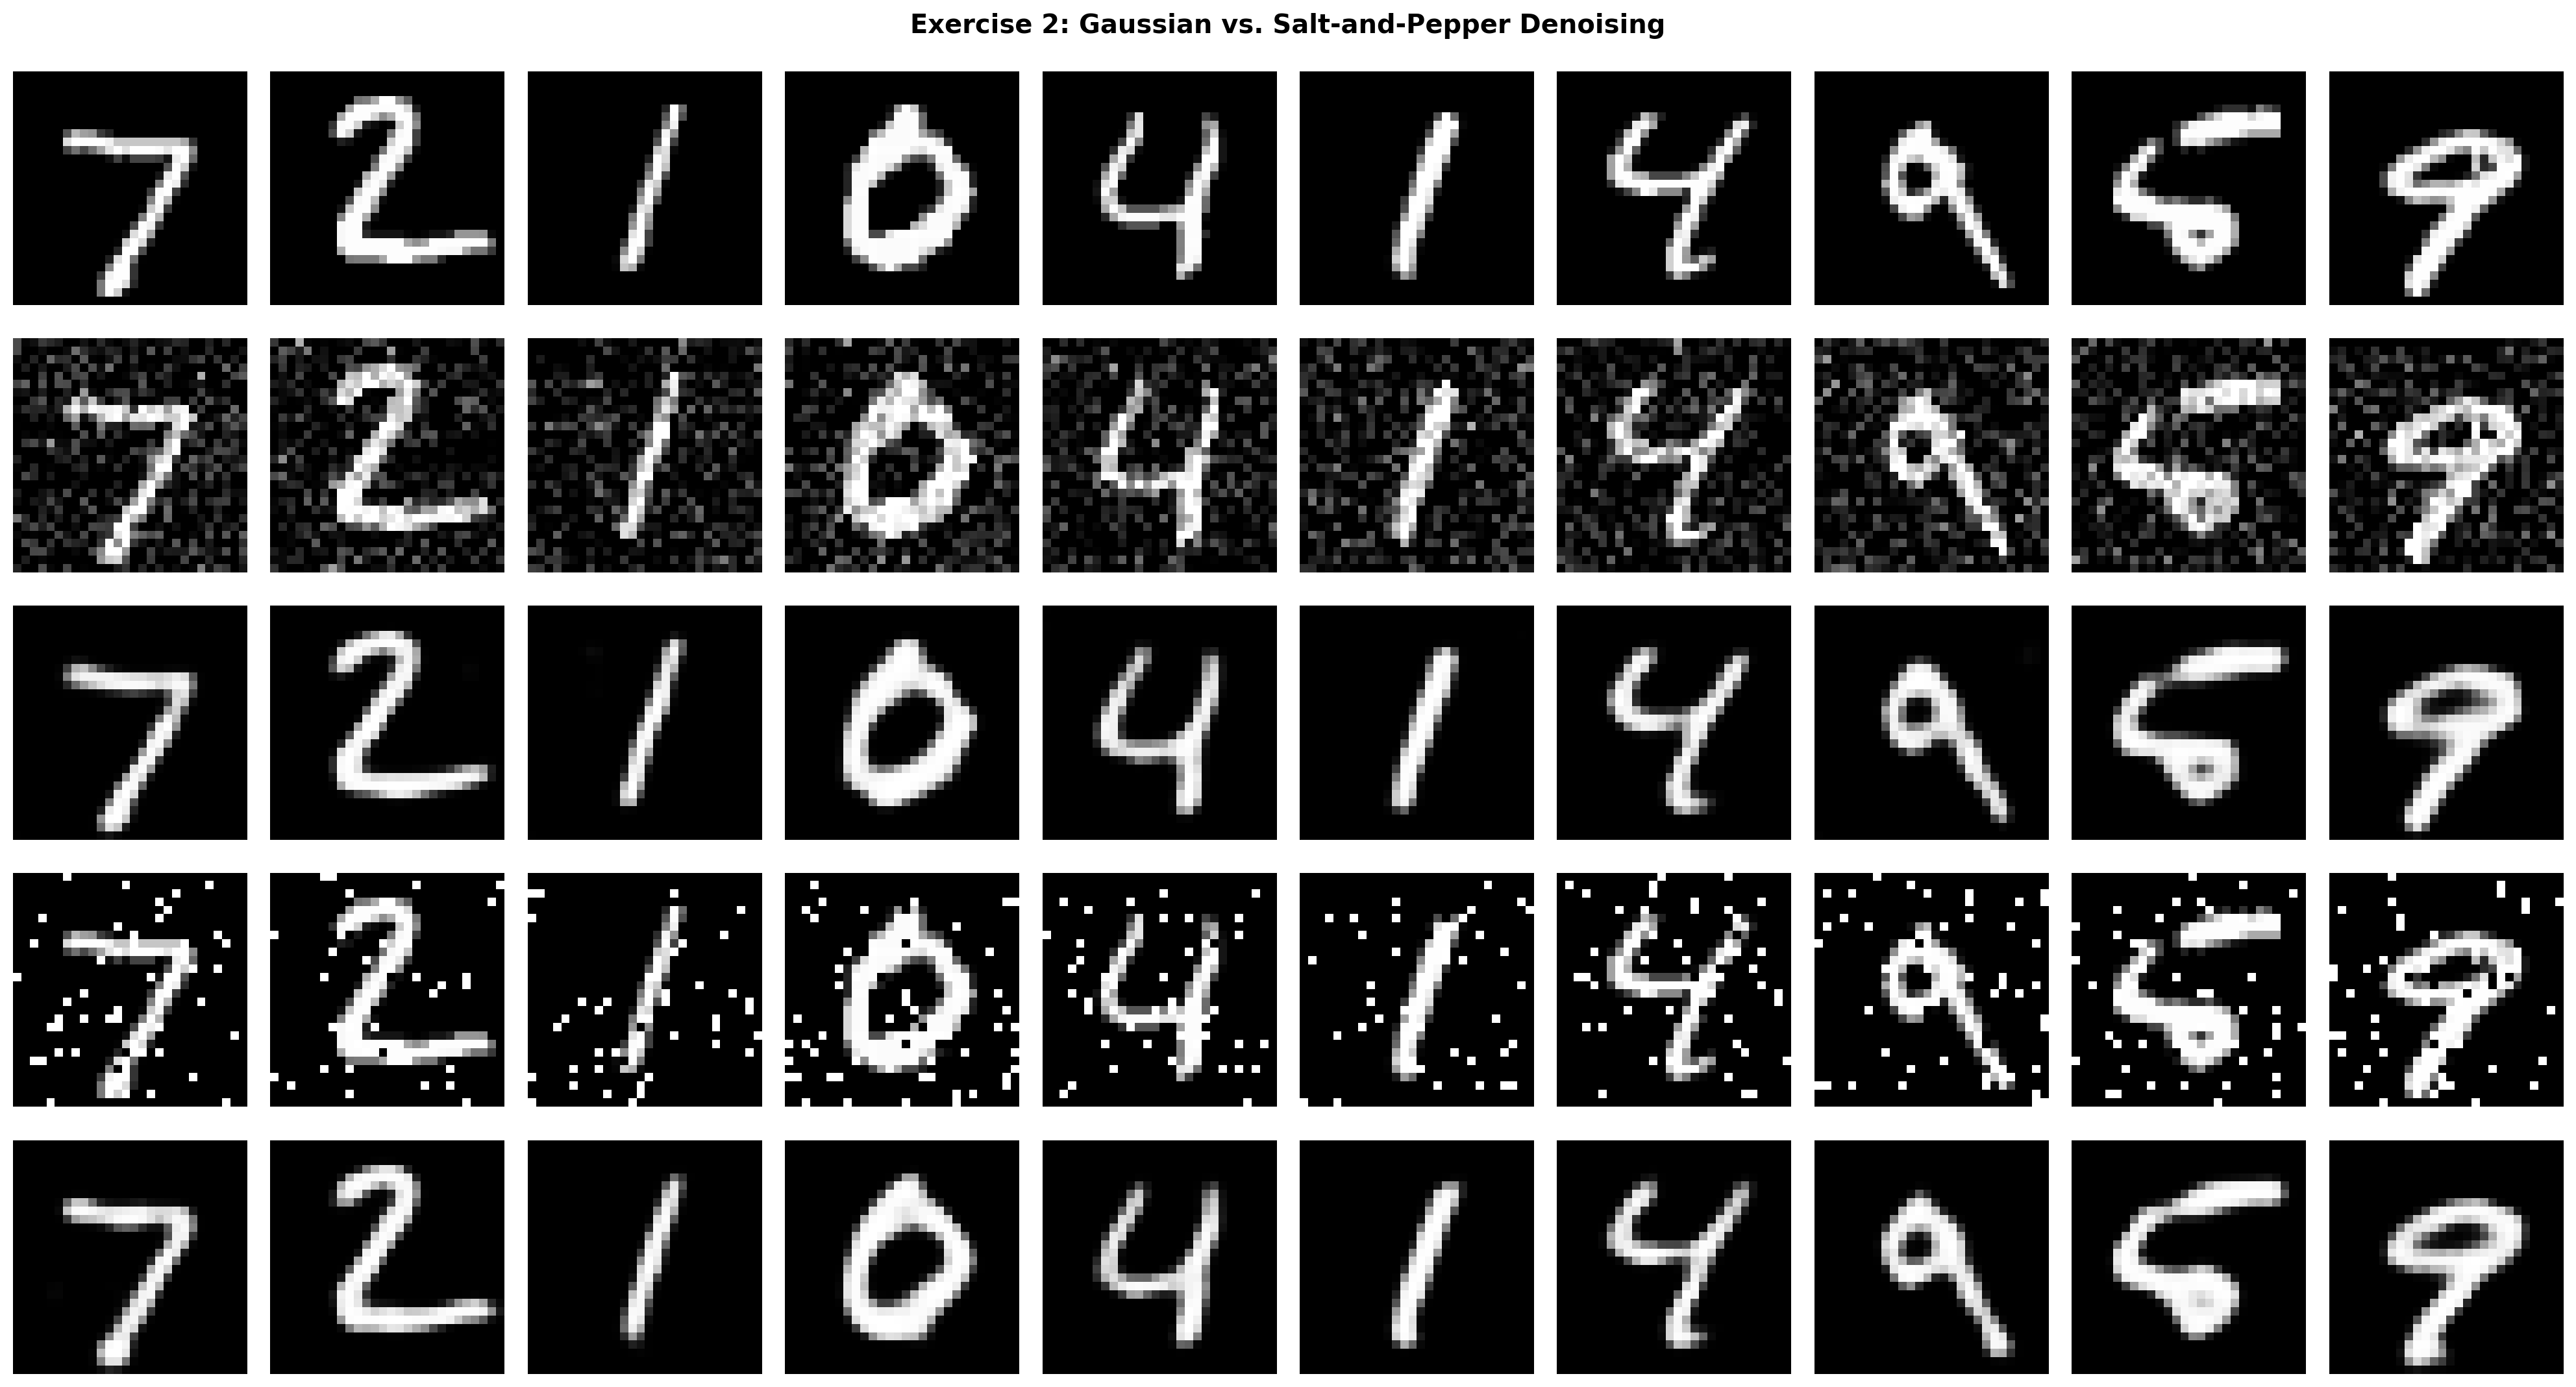

In [16]:
comparison_rows=[]
for name,model,inp in [("Gaussian sigma=0.2",denoise_ae,x_test_noisy),("S&P p=0.10",sp_ae,sp_noisy[0.10])]:
    rec=model.predict(inp,verbose=0); m=metrics_dict(x_test_cnn,rec); comparison_rows.append({"Noise":name,**m})
noise_compare=pd.DataFrame(comparison_rows).set_index("Noise"); print(noise_compare.round(5)); save_table_png(noise_compare,"22_Gaussian_vs_SP_table.png","Exercise 2: Gaussian vs. Salt-and-Pepper")
fig,ax=plt.subplots(5,n_show,figsize=(20,11))
rows=[("Clean",x_test_cnn),("Gaussian noisy",x_test_noisy),("Gaussian denoised",denoised),("S&P noisy",sp_noisy[0.10]),("S&P denoised",sp_recon[0.10])]
for r,(lbl,imgs) in enumerate(rows):
    for i in range(n_show): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray"); ax[r,i].axis("off")
    ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Exercise 2: Gaussian vs. Salt-and-Pepper Denoising",fontweight="bold"); save_fig(fig,"22_Gaussian_vs_SP.png"); plt.show()

## 12. Additional Exercise 3 — Train Denoising AEs at Two Noise Levels

sigma 0.1 {'MSE': 0.0035621162969619036, 'MAE': 0.01819450408220291, 'SSIM': 0.9606794247144865}
sigma 0.3 {'MSE': 0.0071639688685536385, 'MAE': 0.02755085937678814, 'SSIM': 0.9127130162052488}
         MSE      MAE     SSIM
0.1  0.00356  0.01819  0.96068
0.3  0.00716  0.02755  0.91271
Saved: Experiment_7_Results/Ex3_SSIM_comparison.png | DPI=200


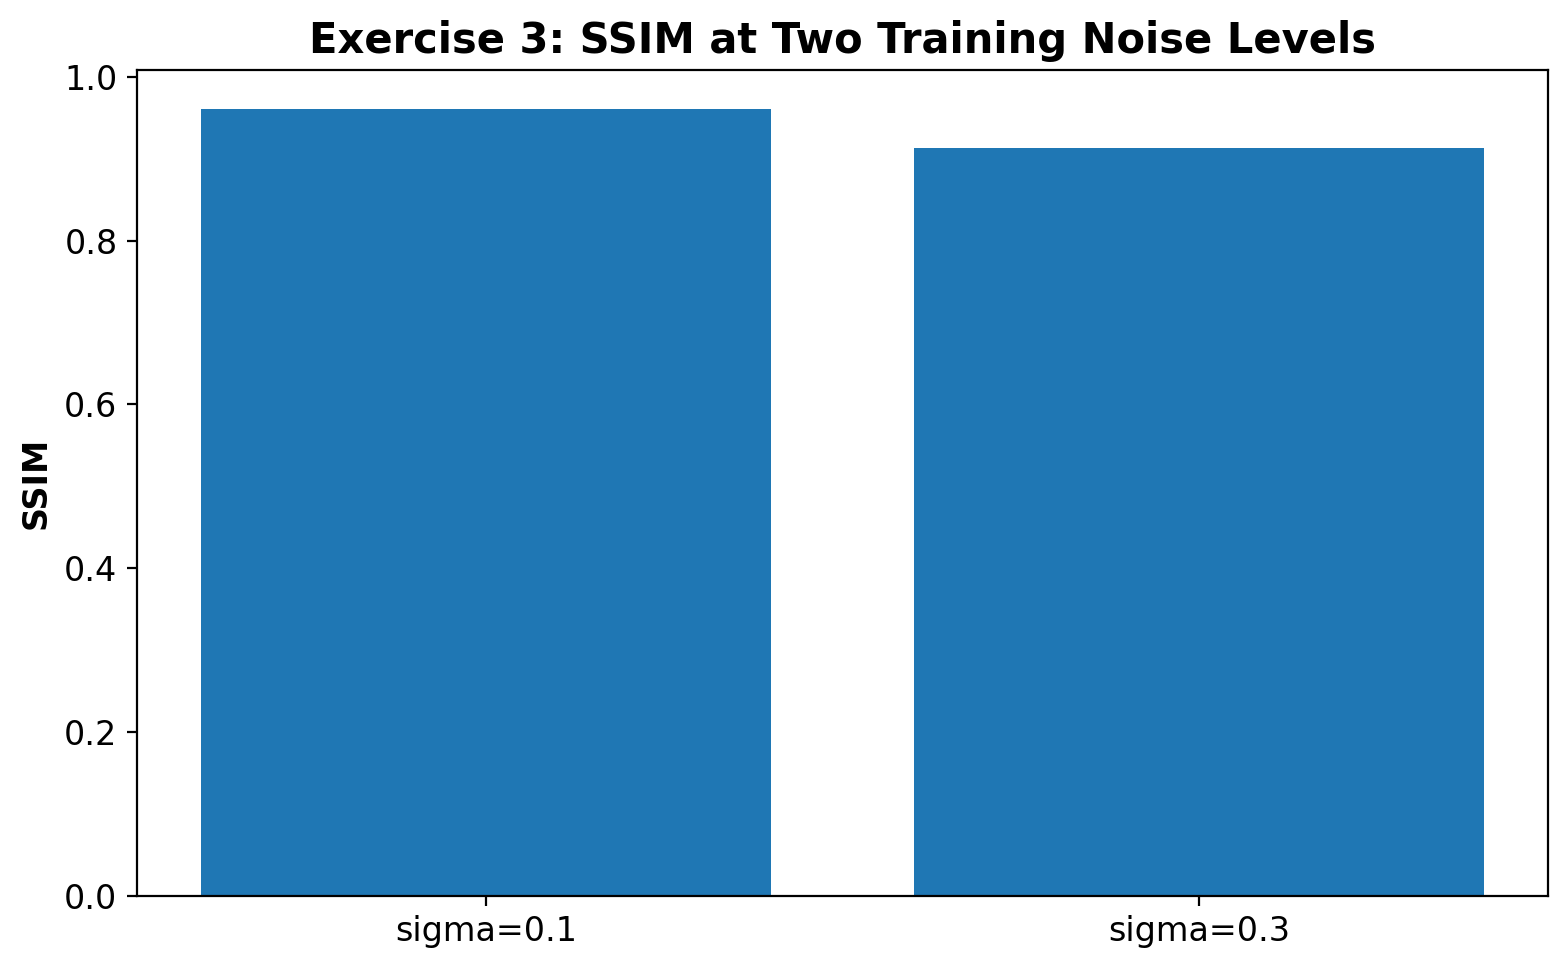

In [17]:
ex3_runs={}
for s in [0.1,0.3]:
    keras.utils.set_random_seed(SEED+int(s*100)); m=build_conv_autoencoder(); trn=add_gaussian_noise(x_tr_cnn,s,500); valn=add_gaussian_noise(x_val_cnn,s,501); tst=add_gaussian_noise(x_test_cnn,s,502); t0=time.time(); h=m.fit(trn,x_tr_cnn,validation_data=(valn,x_val_cnn),epochs=20,batch_size=128,verbose=0); rec=m.predict(tst,verbose=0); ex3_runs[s]=(m,h,rec,time.time()-t0,metrics_dict(x_test_cnn,rec)); print("sigma",s,ex3_runs[s][-1])
ex3_df=pd.DataFrame({s:ex3_runs[s][4] for s in ex3_runs}).T; print(ex3_df.round(5))
fig,ax=plt.subplots(figsize=(8,5)); ax.bar(["sigma=0.1","sigma=0.3"],[ex3_runs[.1][4]["SSIM"],ex3_runs[.3][4]["SSIM"]]); ax.set(ylabel="SSIM",title="Exercise 3: SSIM at Two Training Noise Levels"); save_fig(fig,"Ex3_SSIM_comparison.png"); plt.show()

## 13. Additional Exercise 4 — Conv2DTranspose vs. UpSampling2D

Epoch 1/20
63/63 - 5s - 85ms/step - loss: 0.4046 - val_loss: 0.1793
Epoch 2/20
63/63 - 1s - 9ms/step - loss: 0.1499 - val_loss: 0.1138
Epoch 3/20
63/63 - 0s - 7ms/step - loss: 0.0968 - val_loss: 0.0883
Epoch 4/20
63/63 - 0s - 7ms/step - loss: 0.0843 - val_loss: 0.0810
Epoch 5/20
63/63 - 0s - 7ms/step - loss: 0.0794 - val_loss: 0.0779
Epoch 6/20
63/63 - 0s - 7ms/step - loss: 0.0768 - val_loss: 0.0758
Epoch 7/20
63/63 - 0s - 7ms/step - loss: 0.0750 - val_loss: 0.0742
Epoch 8/20
63/63 - 0s - 7ms/step - loss: 0.0737 - val_loss: 0.0731
Epoch 9/20
63/63 - 0s - 7ms/step - loss: 0.0728 - val_loss: 0.0722
Epoch 10/20
63/63 - 0s - 7ms/step - loss: 0.0720 - val_loss: 0.0715
Epoch 11/20
63/63 - 0s - 7ms/step - loss: 0.0714 - val_loss: 0.0709
Epoch 12/20
63/63 - 0s - 7ms/step - loss: 0.0708 - val_loss: 0.0704
Epoch 13/20
63/63 - 0s - 7ms/step - loss: 0.0704 - val_loss: 0.0700
Epoch 14/20
63/63 - 0s - 7ms/step - loss: 0.0700 - val_loss: 0.0697
Epoch 15/20
63/63 - 0s - 7ms/step - loss: 0.0696 - val_l

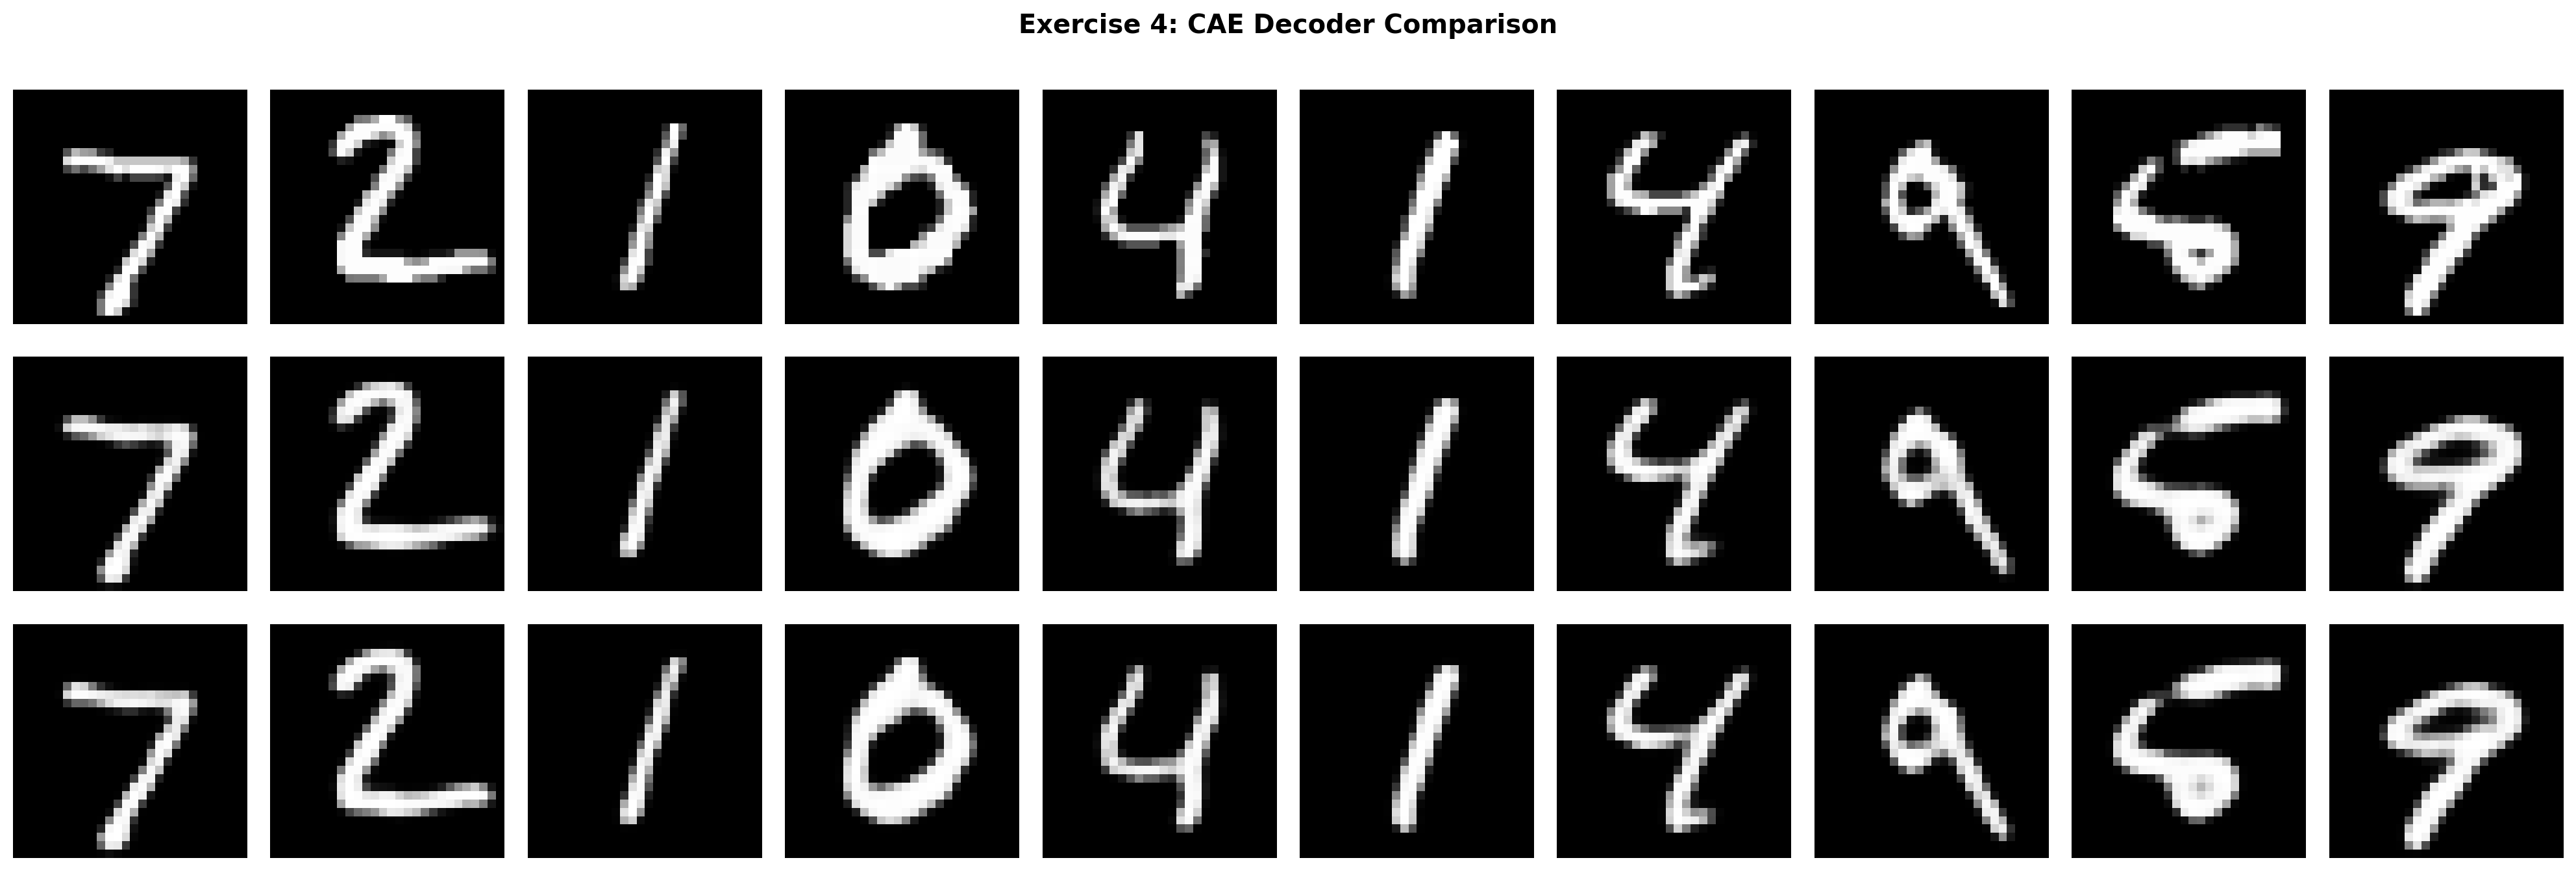

In [18]:
def build_transpose_cae():
    inp=Input((28,28,1)); x=layers.Conv2D(32,3,activation="relu",padding="same")(inp); x=layers.MaxPooling2D(2,padding="same")(x); x=layers.Conv2D(64,3,activation="relu",padding="same")(x); x=layers.MaxPooling2D(2,padding="same")(x); x=layers.Conv2D(64,3,activation="relu",padding="same")(x); x=layers.Conv2DTranspose(32,3,strides=2,activation="relu",padding="same")(x); out=layers.Conv2DTranspose(1,3,strides=2,activation="sigmoid",padding="same")(x); m=Model(inp,out); m.compile(optimizer=keras.optimizers.Adam(1e-3),loss="binary_crossentropy"); return m
keras.utils.set_random_seed(SEED); cae_t=build_transpose_cae(); t0=time.time(); cae_t_hist=cae_t.fit(x_tr_cnn,x_tr_cnn,validation_data=(x_val_cnn,x_val_cnn),epochs=20,batch_size=128,verbose=2); cae_t_time=time.time()-t0; cae_t_rec=cae_t.predict(x_test_cnn,verbose=0); cae_t_metrics=metrics_dict(x_test_cnn,cae_t_rec)
print("UpSampling:",cae_metrics); print("Conv2DTranspose:",cae_t_metrics)
fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,imgs in enumerate([x_test_cnn,cae_recon,cae_t_rec]): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray"); ax[r,i].axis("off")
for r,lbl in enumerate(["Original","UpSampling2D","Conv2DTranspose"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Exercise 4: CAE Decoder Comparison",fontweight="bold"); save_fig(fig,"23_CAE_decoder_comparison.png"); plt.show()

## 14. Additional Exercise 5 — VAE Latent Dimensions 2 and 8

Epoch 1/20
63/63 - 10s - 152ms/step - kl_loss: 3.7013 - loss: 310.4252 - reconstruction_loss: 306.7239 - val_kl_loss: 3.3752 - val_loss: 216.9484 - val_reconstruction_loss: 213.5733
Epoch 2/20
63/63 - 1s - 10ms/step - kl_loss: 3.8681 - loss: 213.1392 - reconstruction_loss: 209.2711 - val_kl_loss: 4.6558 - val_loss: 207.2842 - val_reconstruction_loss: 202.6284
Epoch 3/20
63/63 - 1s - 8ms/step - kl_loss: 4.2606 - loss: 204.1370 - reconstruction_loss: 199.8764 - val_kl_loss: 5.1328 - val_loss: 199.9860 - val_reconstruction_loss: 194.8532
Epoch 4/20
63/63 - 1s - 8ms/step - kl_loss: 4.4194 - loss: 198.7578 - reconstruction_loss: 194.3384 - val_kl_loss: 4.8601 - val_loss: 195.2088 - val_reconstruction_loss: 190.3486
Epoch 5/20
63/63 - 1s - 8ms/step - kl_loss: 4.8015 - loss: 194.5529 - reconstruction_loss: 189.7514 - val_kl_loss: 5.4458 - val_loss: 191.2507 - val_reconstruction_loss: 185.8049
Epoch 6/20
63/63 - 1s - 8ms/step - kl_loss: 5.4000 - loss: 190.3870 - reconstruction_loss: 184.9871 -

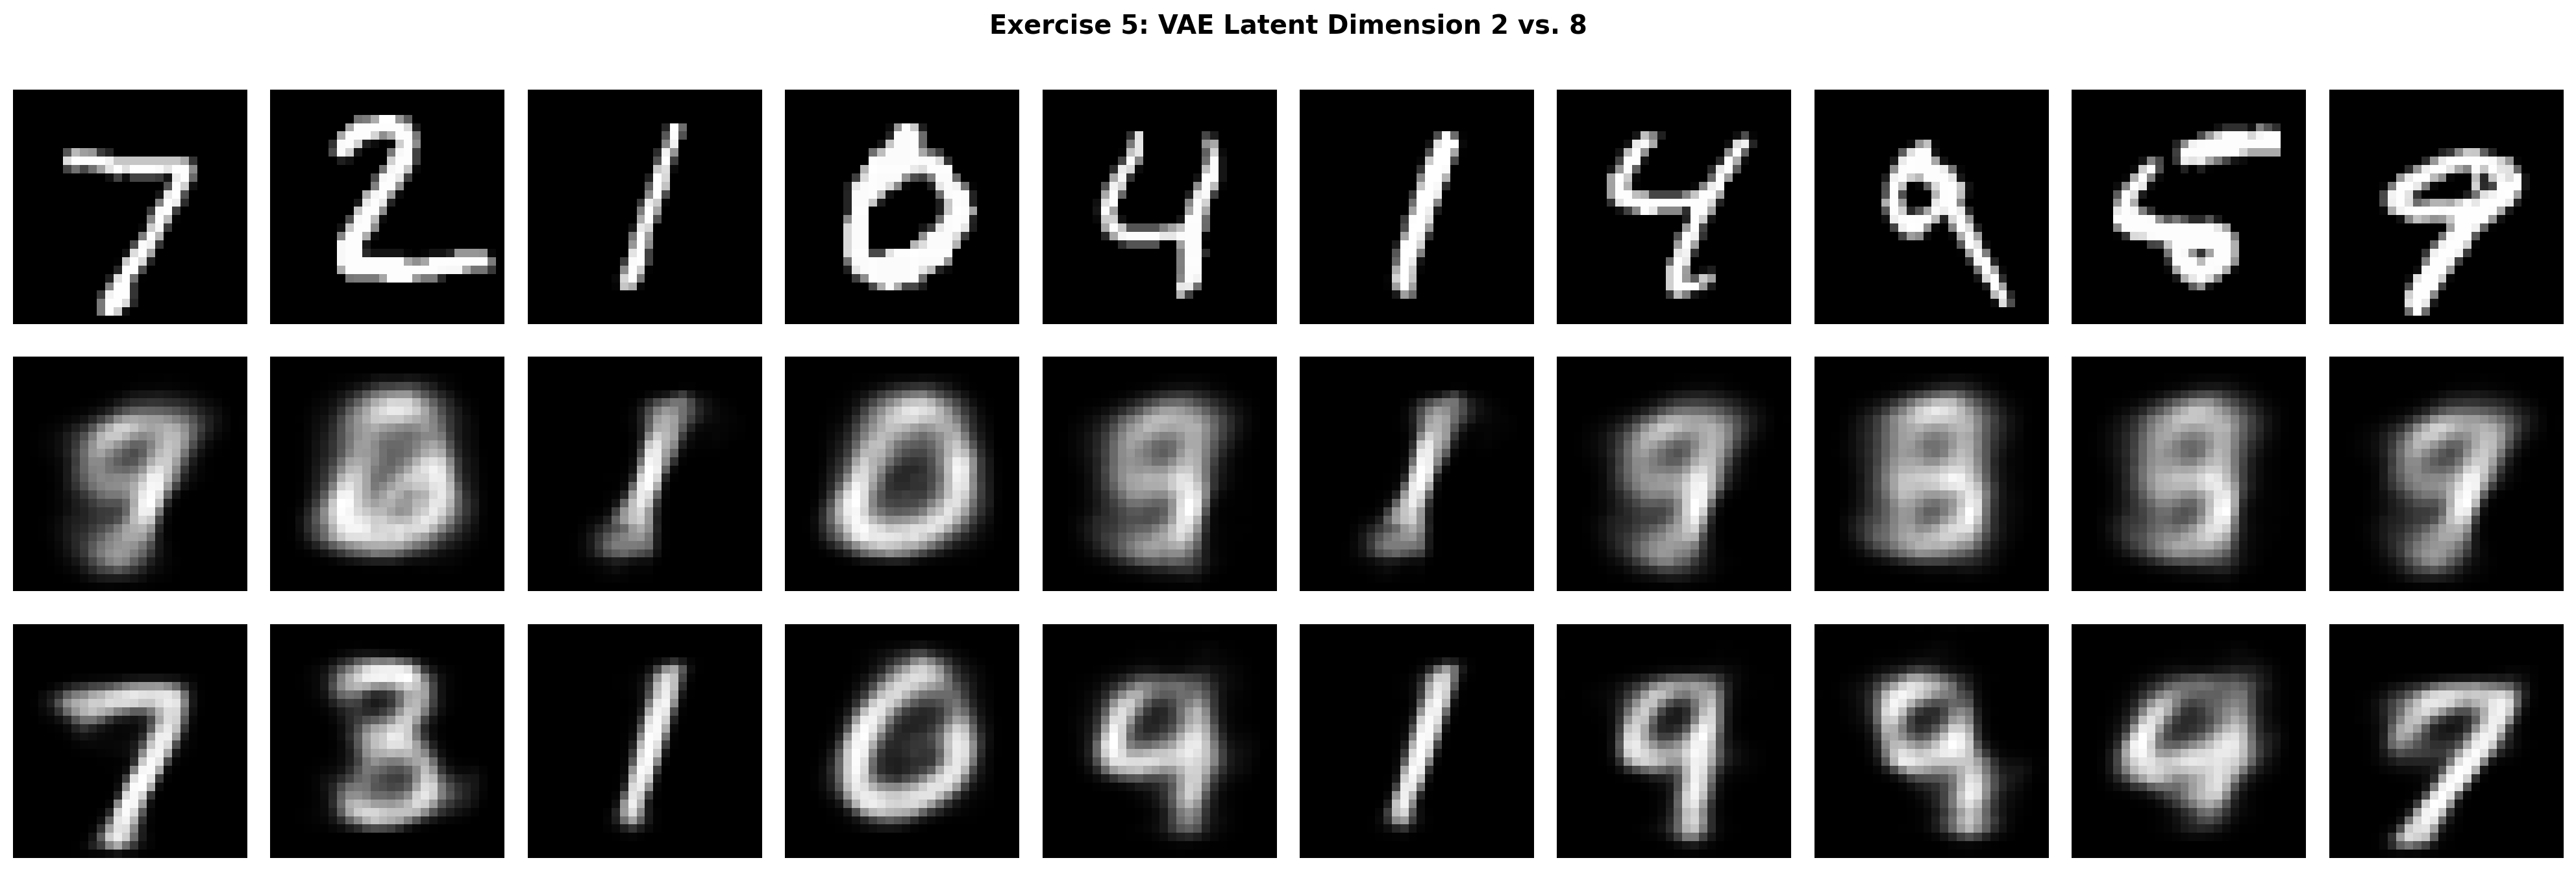

Saved: Experiment_7_Results/25_VAE_latent_spaces.png | DPI=200


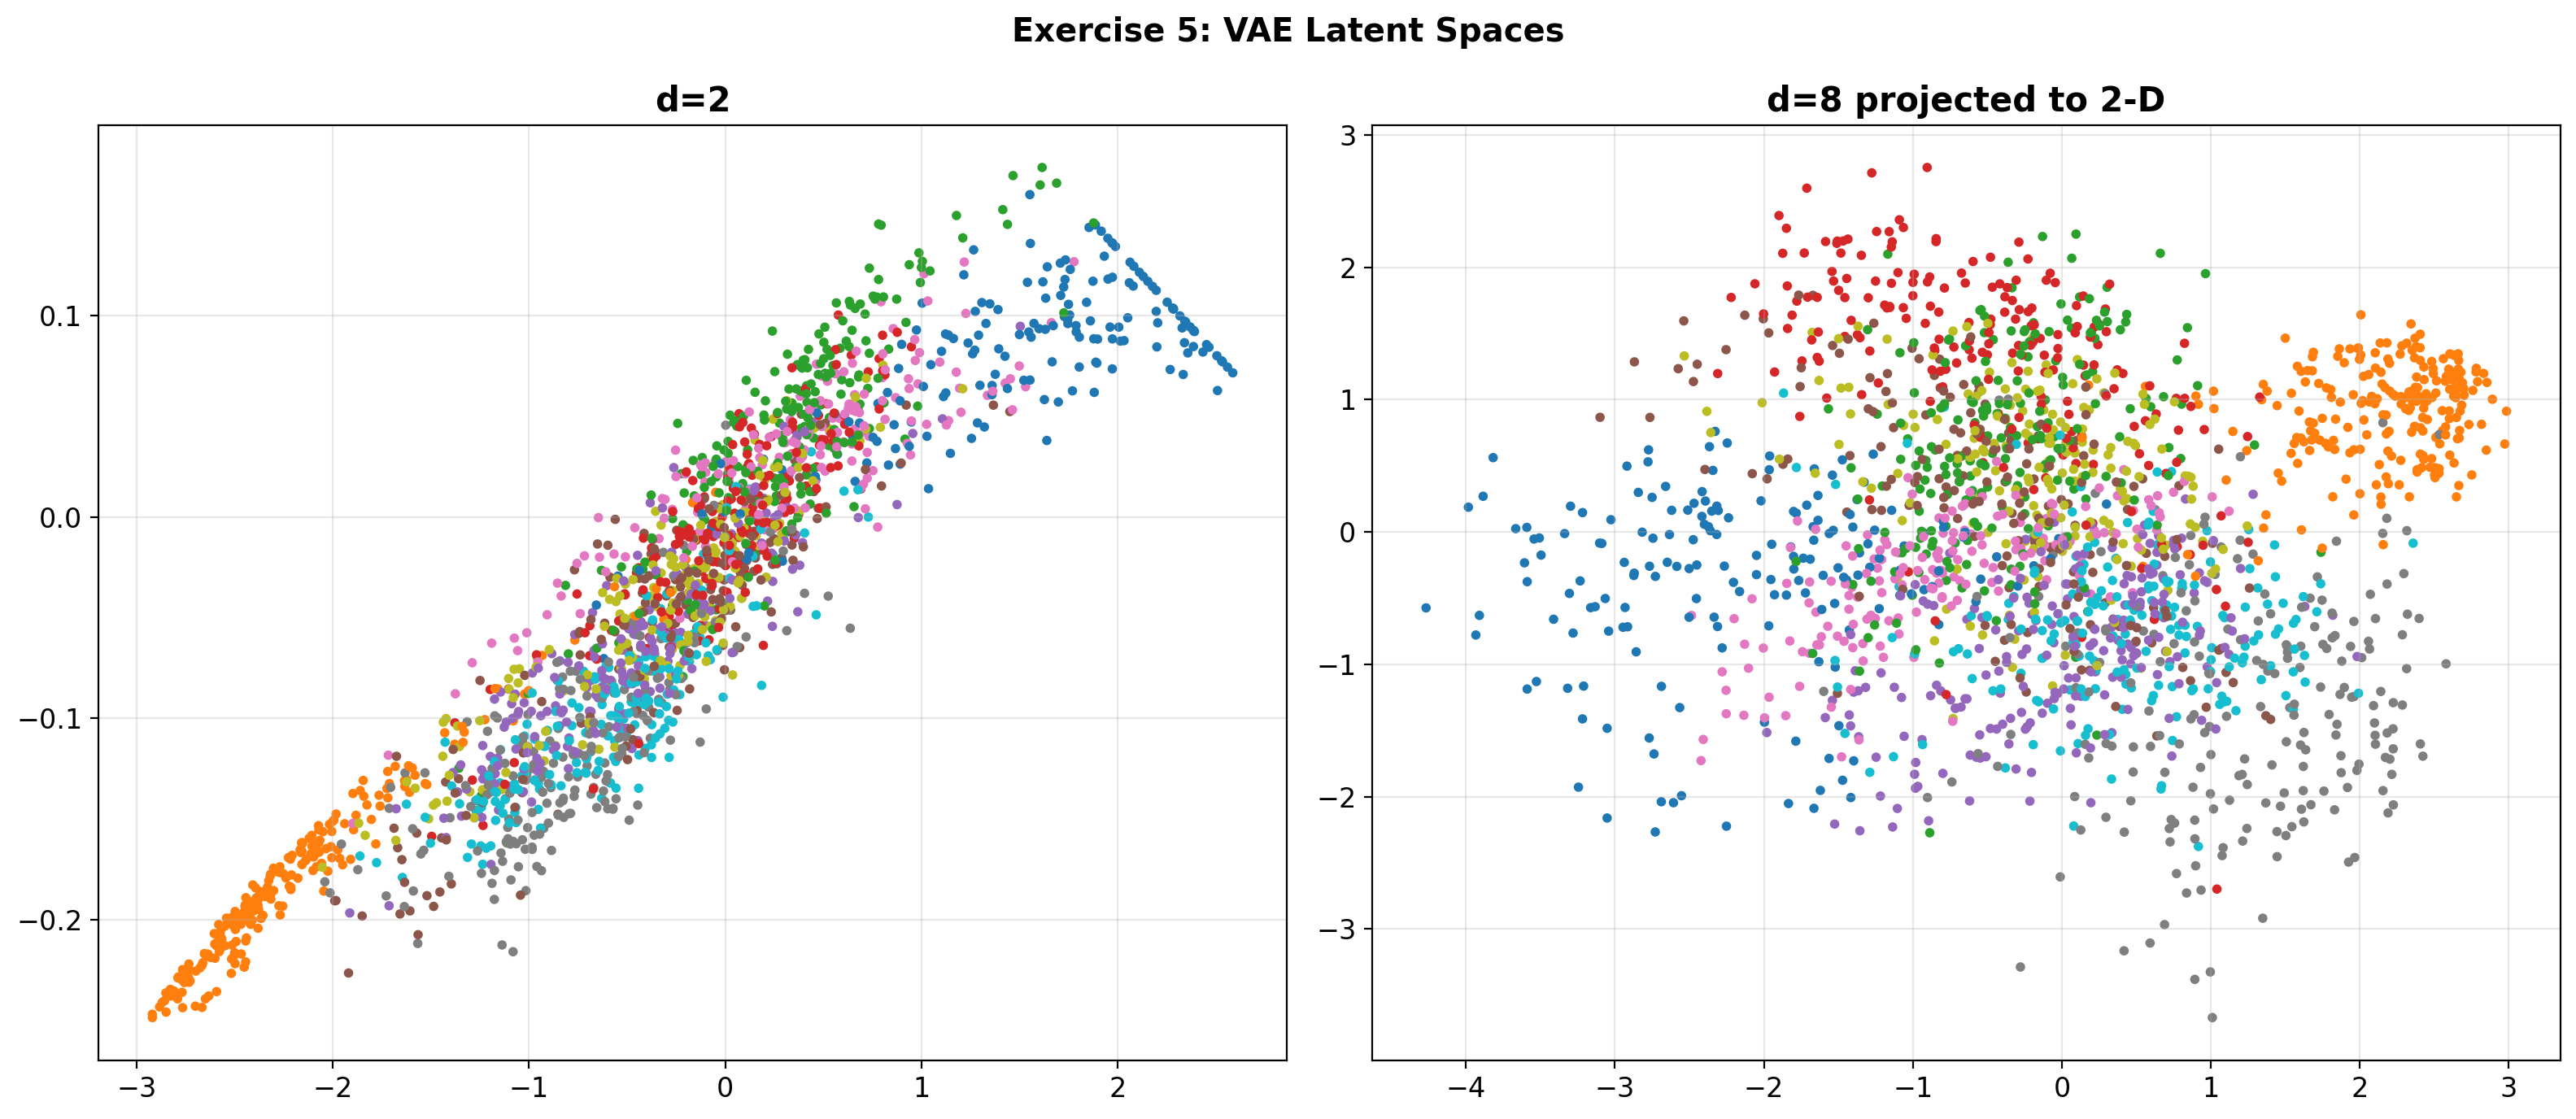

In [19]:
vae8,enc8,dec8,vae8_hist,vae8_time=train_vae(8,1.0); vae8_eval=vae_eval(vae8,enc8,dec8)
vae_dim_df=pd.DataFrame({2:{k:vae2[k] for k in ["MSE","MAE","SSIM","recon_loss","kl","total"]},8:{k:vae8_eval[k] for k in ["MSE","MAE","SSIM","recon_loss","kl","total"]}}).T
print(vae_dim_df.round(5))
fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,imgs in enumerate([x_test_cnn,vae2["recon"],vae8_eval["recon"]]): ax[r,i].imshow(imgs[i].squeeze(),cmap="gray"); ax[r,i].axis("off")
for r,lbl in enumerate(["Original","VAE d=2","VAE d=8"]): ax[r,0].set_ylabel(lbl,fontweight="bold")
fig.suptitle("Exercise 5: VAE Latent Dimension 2 vs. 8",fontweight="bold"); save_fig(fig,"24_VAE_latent_dim_comparison.png"); plt.show()

mu8=vae8_eval["mu"]; mu8c=mu8-mu8.mean(0); _,s,vt=np.linalg.svd(mu8c,full_matrices=False); proj=mu8c@vt[:2].T
fig,ax=plt.subplots(1,2,figsize=(16,7)); ax[0].scatter(z_mu[:,0],z_mu[:,1],c=y_test,cmap="tab10",s=10); ax[0].set_title("d=2"); ax[1].scatter(proj[:,0],proj[:,1],c=y_test,cmap="tab10",s=10); ax[1].set_title("d=8 projected to 2-D");
for a in ax: a.grid(alpha=.3)
fig.suptitle("Exercise 5: VAE Latent Spaces",fontweight="bold"); save_fig(fig,"25_VAE_latent_spaces.png"); plt.show()

## 15. Additional Exercise 6 — Increase the KL Contribution (beta-VAE)

Epoch 1/20
63/63 - 9s - 139ms/step - kl_loss: 0.9361 - loss: 342.4654 - reconstruction_loss: 342.3718 - val_kl_loss: 5.5509 - val_loss: 214.8114 - val_reconstruction_loss: 214.2563
Epoch 2/20
63/63 - 1s - 10ms/step - kl_loss: 11.5299 - loss: 206.2888 - reconstruction_loss: 205.1358 - val_kl_loss: 16.4499 - val_loss: 198.6927 - val_reconstruction_loss: 197.0477
Epoch 3/20
63/63 - 1s - 8ms/step - kl_loss: 14.6637 - loss: 195.2646 - reconstruction_loss: 193.7982 - val_kl_loss: 14.8199 - val_loss: 191.0047 - val_reconstruction_loss: 189.5227
Epoch 4/20
63/63 - 1s - 8ms/step - kl_loss: 15.1234 - loss: 189.8150 - reconstruction_loss: 188.3026 - val_kl_loss: 16.3798 - val_loss: 186.6094 - val_reconstruction_loss: 184.9715
Epoch 5/20
63/63 - 1s - 8ms/step - kl_loss: 15.6030 - loss: 185.0345 - reconstruction_loss: 183.4743 - val_kl_loss: 16.7625 - val_loss: 181.5142 - val_reconstruction_loss: 179.8380
Epoch 6/20
63/63 - 1s - 8ms/step - kl_loss: 17.8504 - loss: 179.8901 - reconstruction_loss: 17

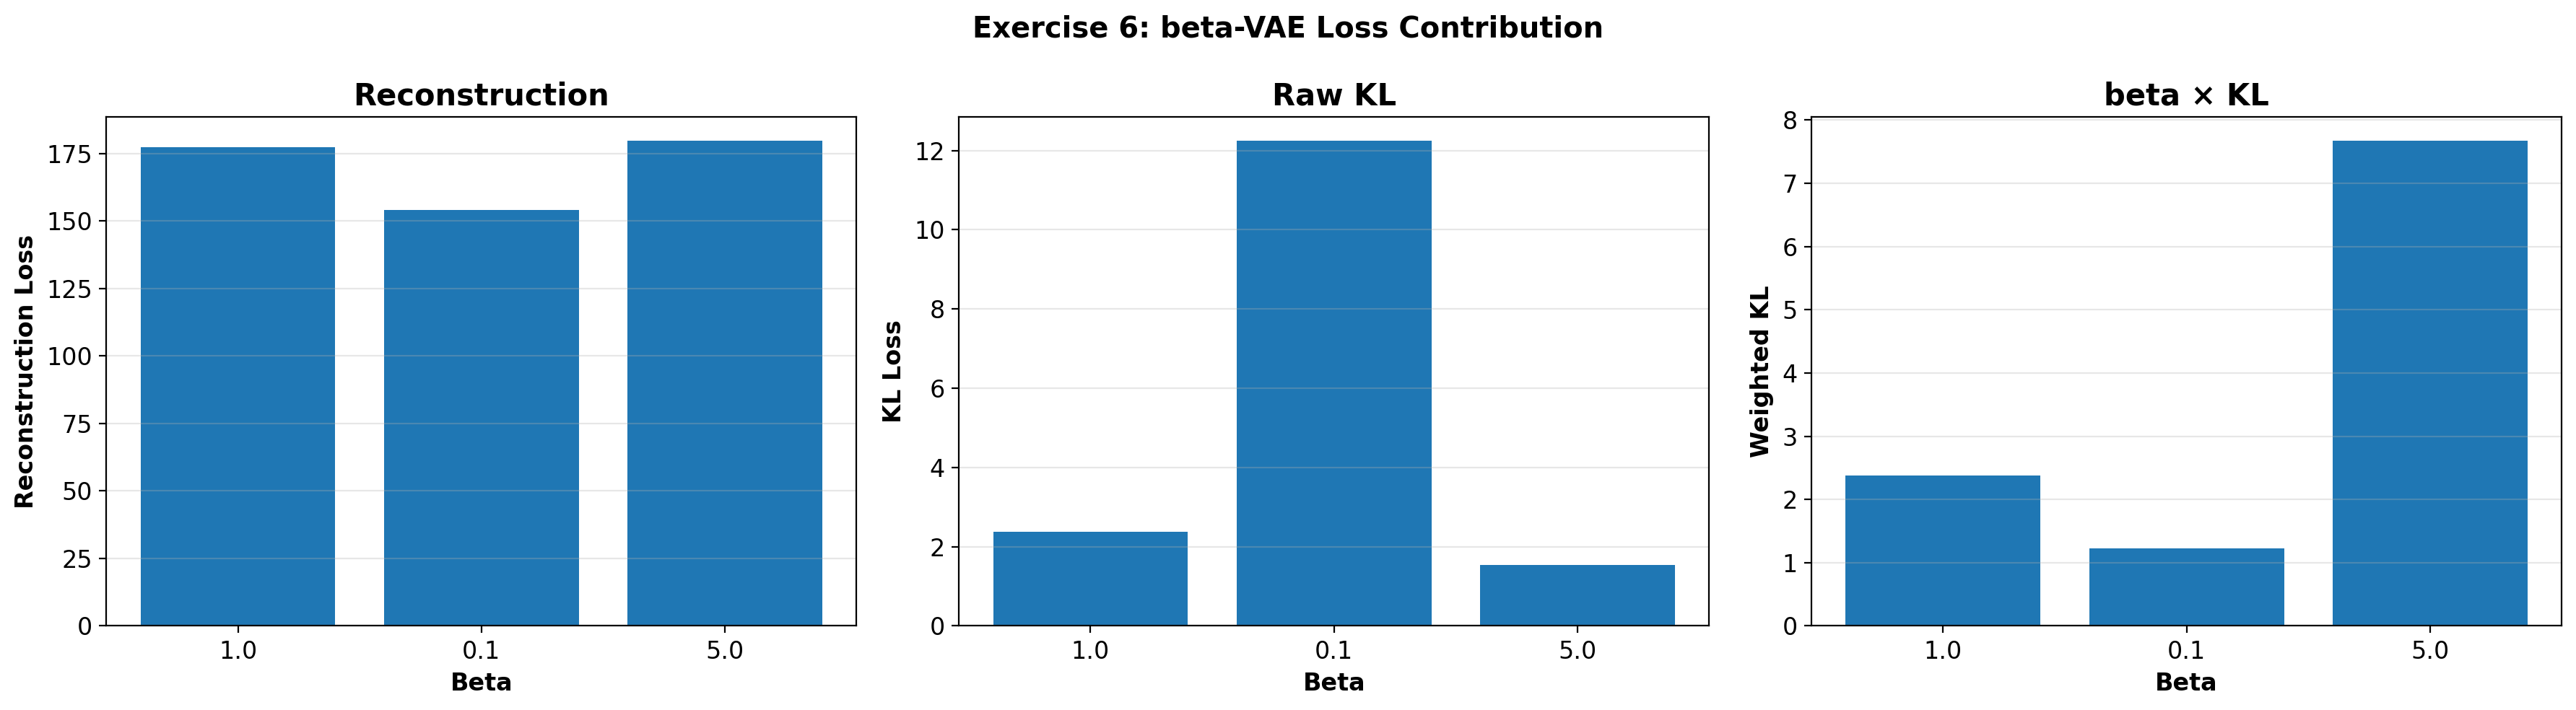

Saved: Experiment_7_Results/27_BetaVAE_reconstructions.png | DPI=200


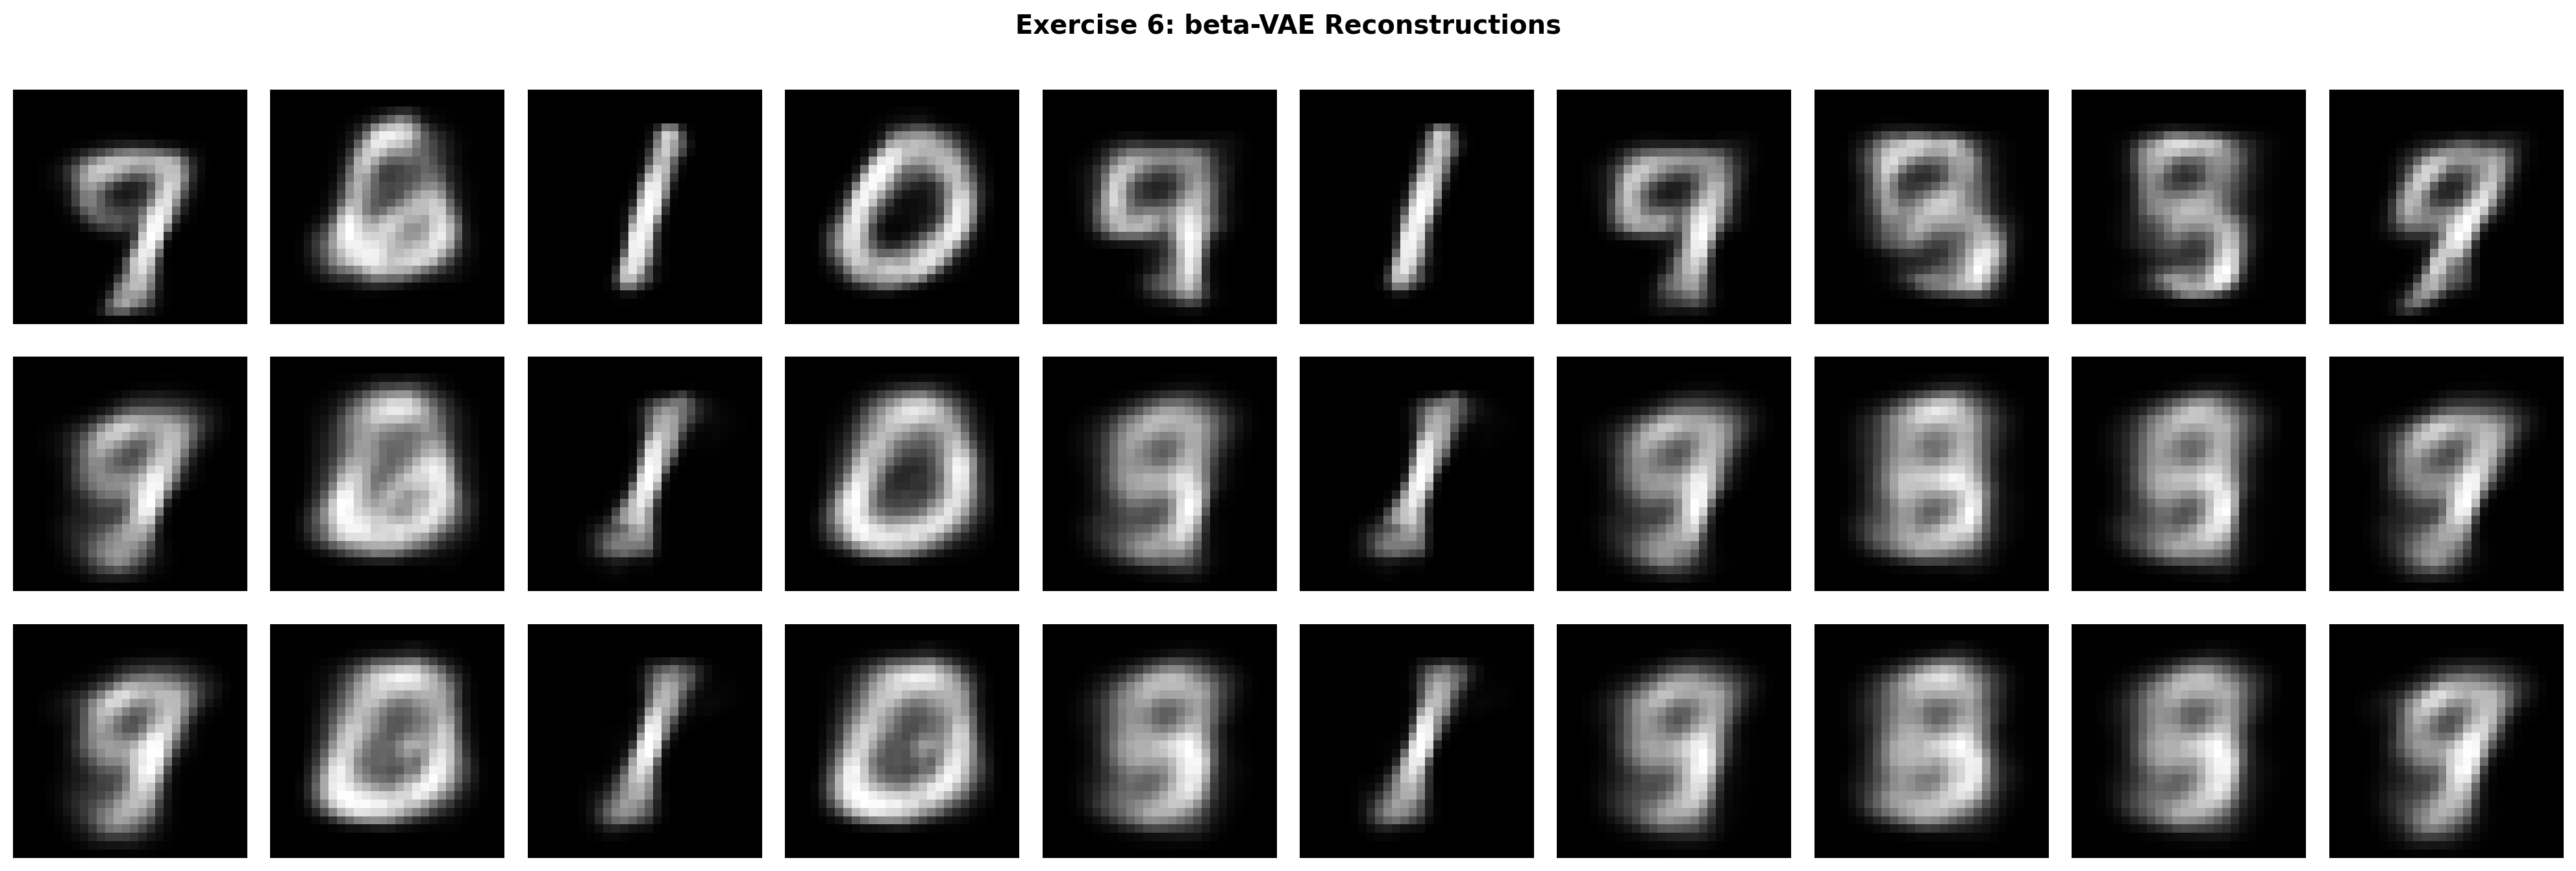

Saved: Experiment_7_Results/28_BetaVAE_latent_spaces.png | DPI=200


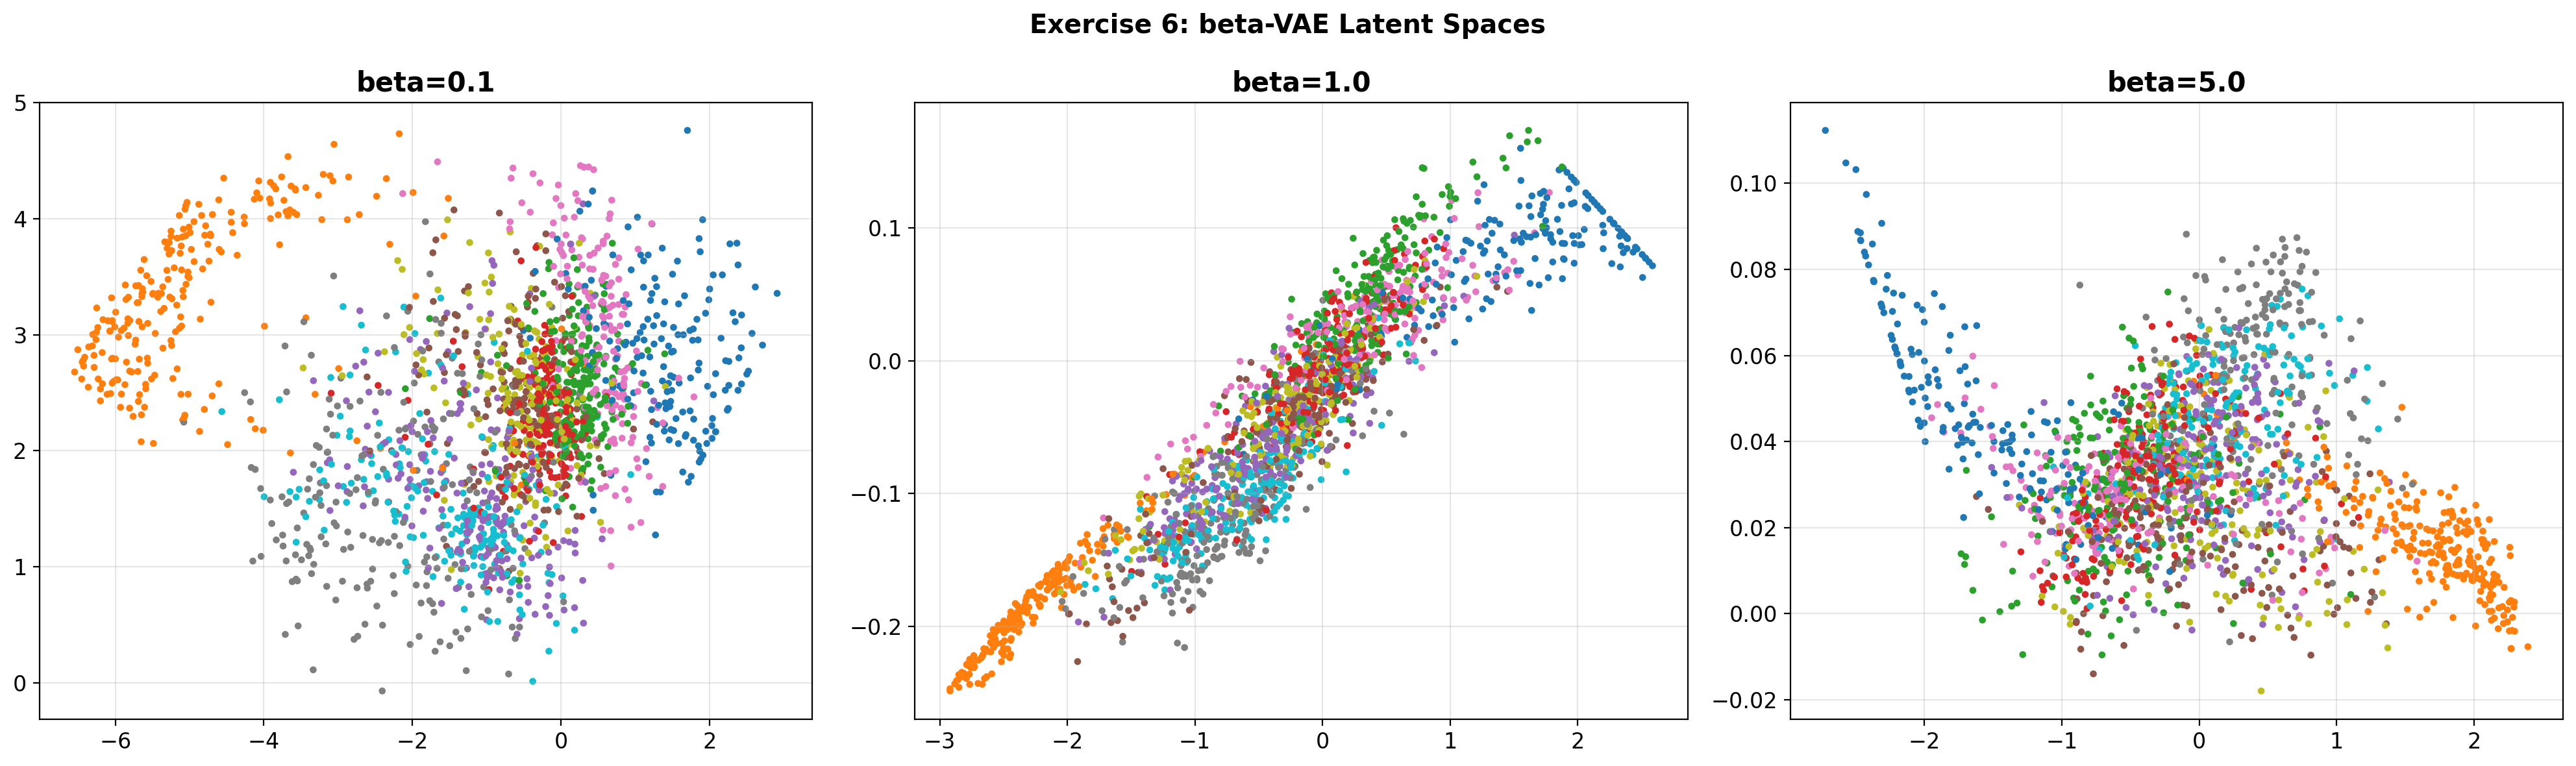

In [20]:
beta_runs={1.0:(vae,encoder,decoder,vae_history,vae_time,vae2)}
for b in [0.1,5.0]:
    beta_runs[b]=(*train_vae(2,b),)
    beta_runs[b]=(*beta_runs[b],vae_eval(beta_runs[b][0],beta_runs[b][1],beta_runs[b][2]))
# normalize tuple for beta=1
beta_rows=[]
for b,v in beta_runs.items():
    ev=v[5] if b==1.0 else v[5]
    beta_rows.append({"Beta":b,"Reconstruction Loss":ev["recon_loss"],"KL Loss":ev["kl"],"Weighted KL":b*ev["kl"],"Total":ev["recon_loss"]+b*ev["kl"],"MSE":ev["MSE"],"MAE":ev["MAE"],"SSIM":ev["SSIM"]})
beta_df=pd.DataFrame(beta_rows).set_index("Beta"); print(beta_df.round(5))
fig,ax=plt.subplots(1,3,figsize=(18,5))
for a,k,title in zip(ax,["Reconstruction Loss","KL Loss","Weighted KL"],["Reconstruction","Raw KL","beta × KL"]): a.bar(beta_df.index.astype(str),beta_df[k]); a.set(title=title,xlabel="Beta",ylabel=k); a.grid(axis="y",alpha=.3)
fig.suptitle("Exercise 6: beta-VAE Loss Contribution",fontweight="bold"); save_fig(fig,"26_BetaVAE_loss.png"); plt.show()
fig,ax=plt.subplots(3,n_show,figsize=(20,7))
for i in range(n_show):
    for r,b in enumerate([0.1,1.0,5.0]): ax[r,i].imshow(beta_runs[b][5]["recon"][i].squeeze(),cmap="gray"); ax[r,i].axis("off")
for r,b in enumerate([0.1,1.0,5.0]): ax[r,0].set_ylabel(f"beta={b}",fontweight="bold")
fig.suptitle("Exercise 6: beta-VAE Reconstructions",fontweight="bold"); save_fig(fig,"27_BetaVAE_reconstructions.png"); plt.show()

# Latent spaces
fig,ax=plt.subplots(1,3,figsize=(20,6))
for a,b in zip(ax,[0.1,1.0,5.0]): mu=beta_runs[b][5]["mu"]; a.scatter(mu[:,0],mu[:,1],c=y_test,cmap="tab10",s=8); a.set_title(f"beta={b}"); a.grid(alpha=.3)
fig.suptitle("Exercise 6: beta-VAE Latent Spaces",fontweight="bold"); save_fig(fig,"28_BetaVAE_latent_spaces.png"); plt.show()

## 16. Additional Exercise 7 — Larger VAE Generated Sample Grid

Saved: Experiment_7_Results/29_VAE_generated_64_d2.png | DPI=200


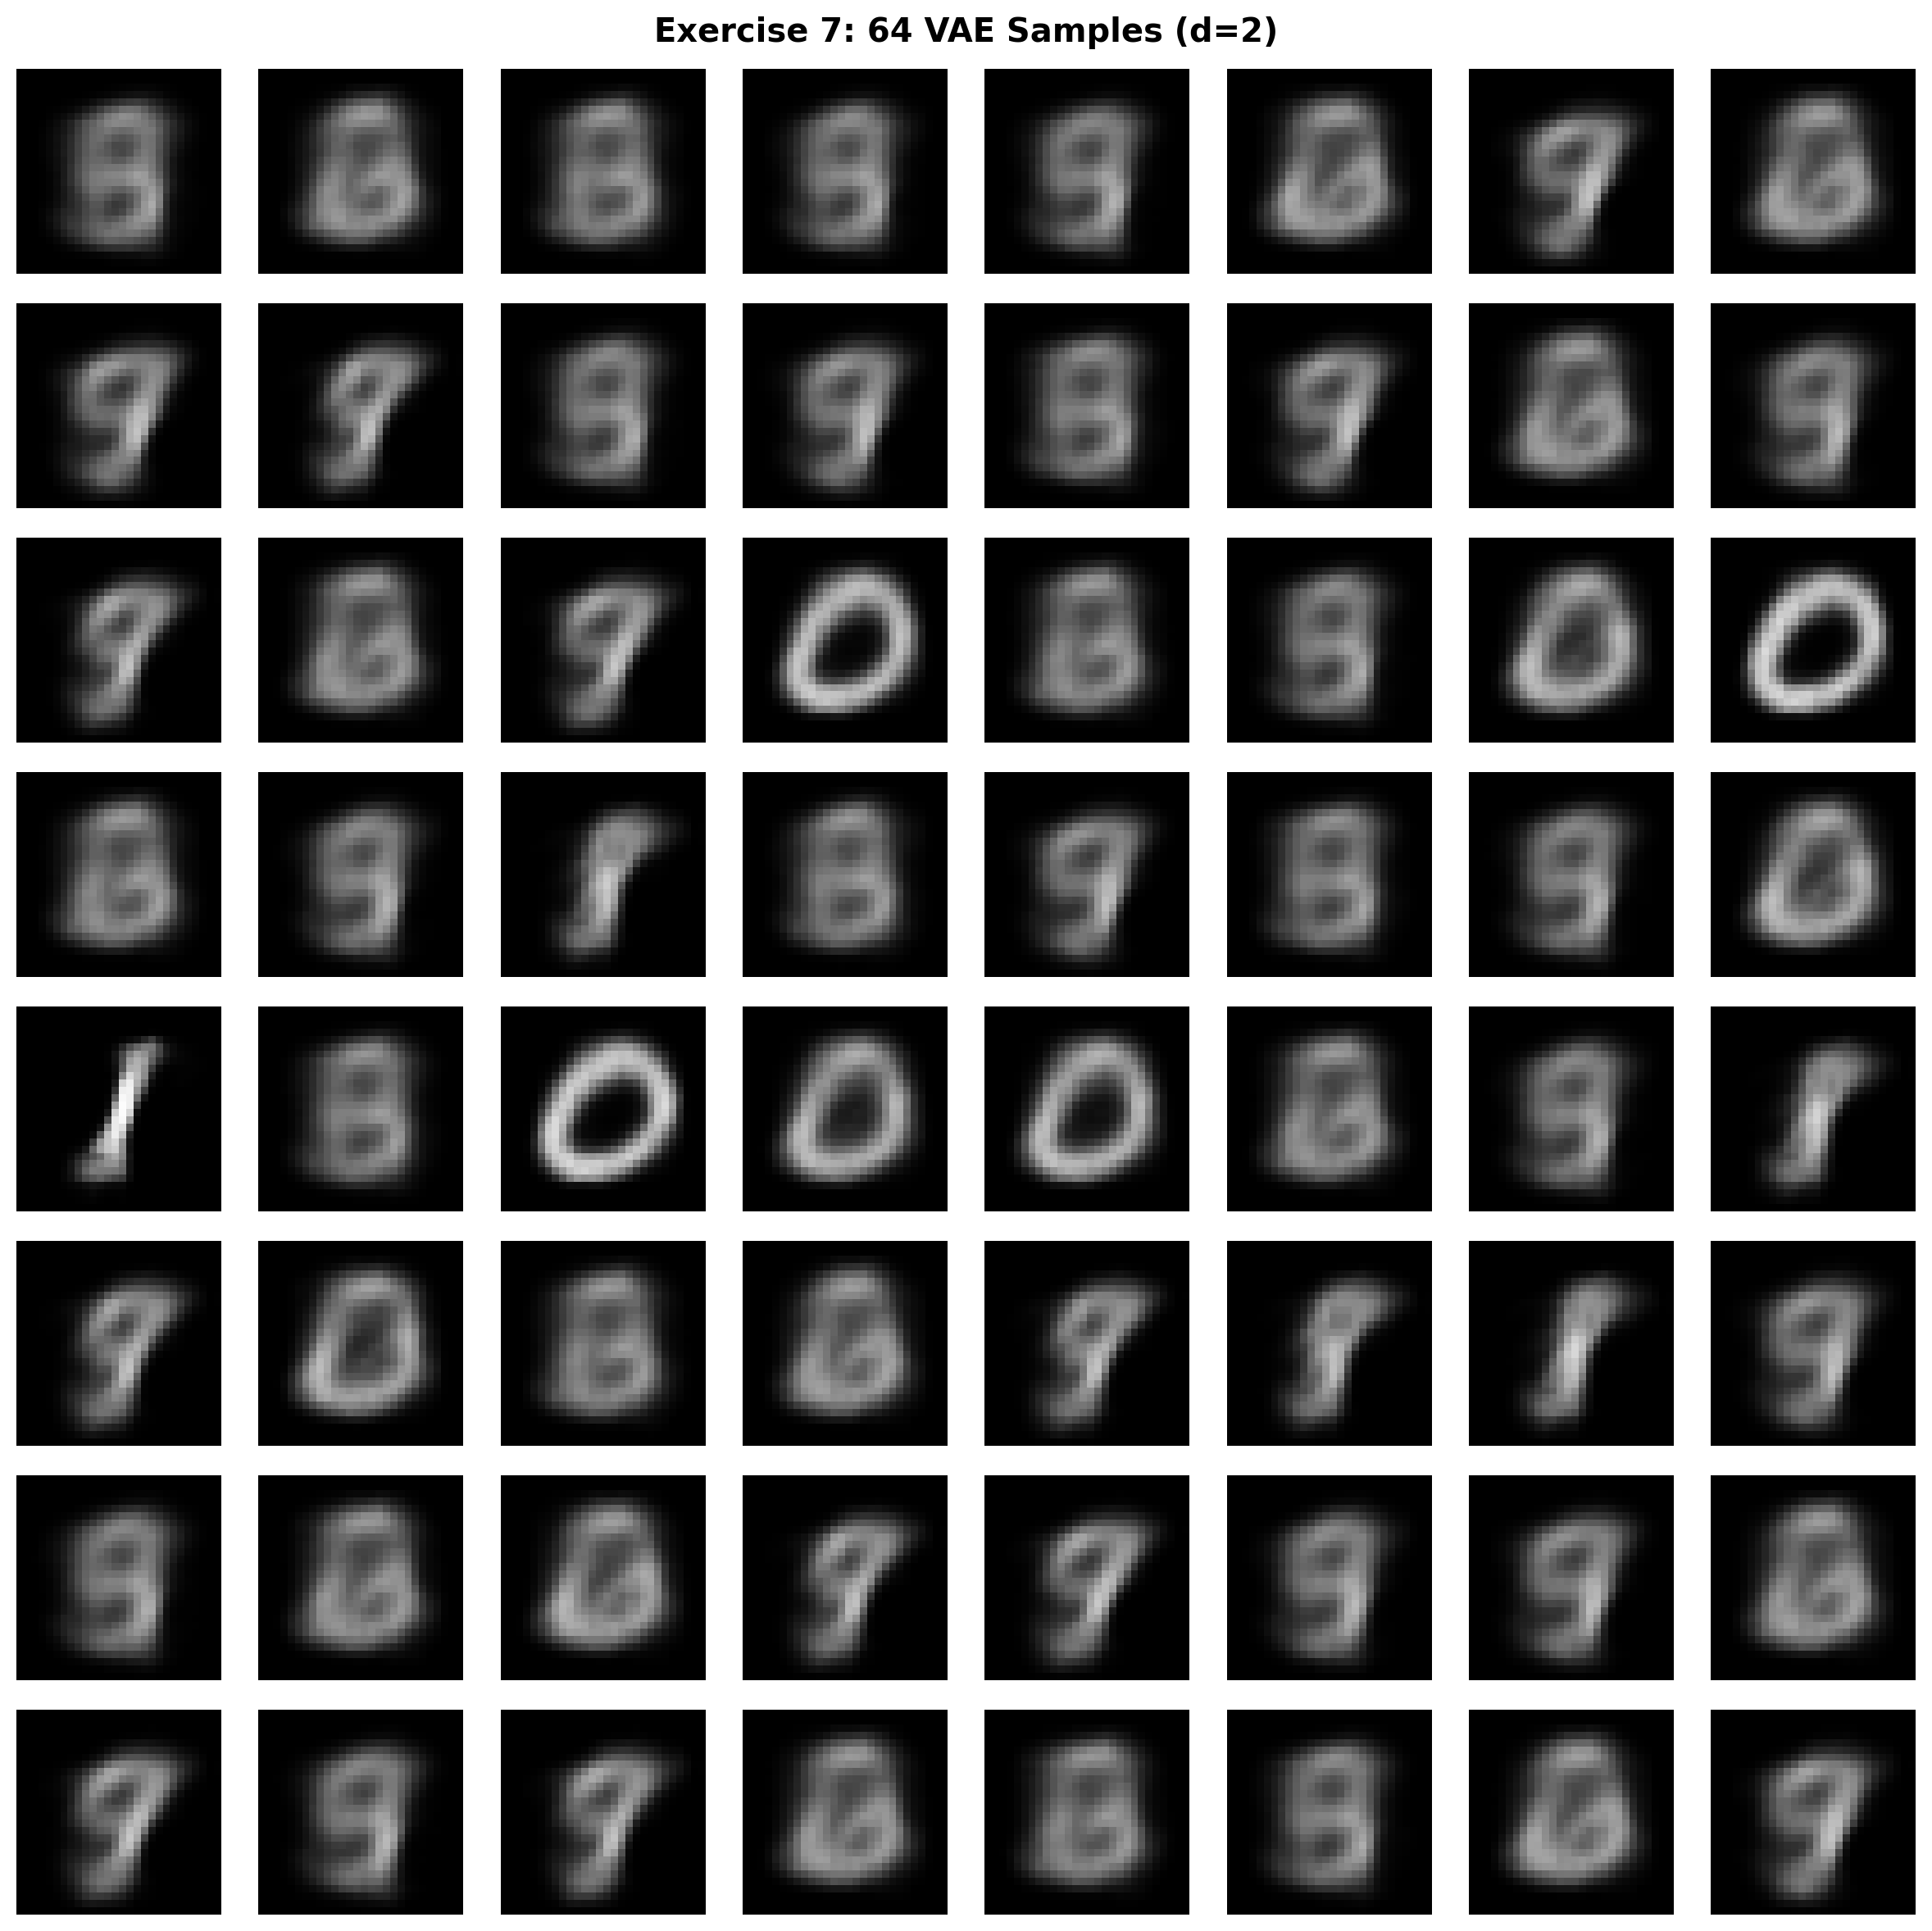

Saved: Experiment_7_Results/30_VAE_generated_64_d8.png | DPI=200


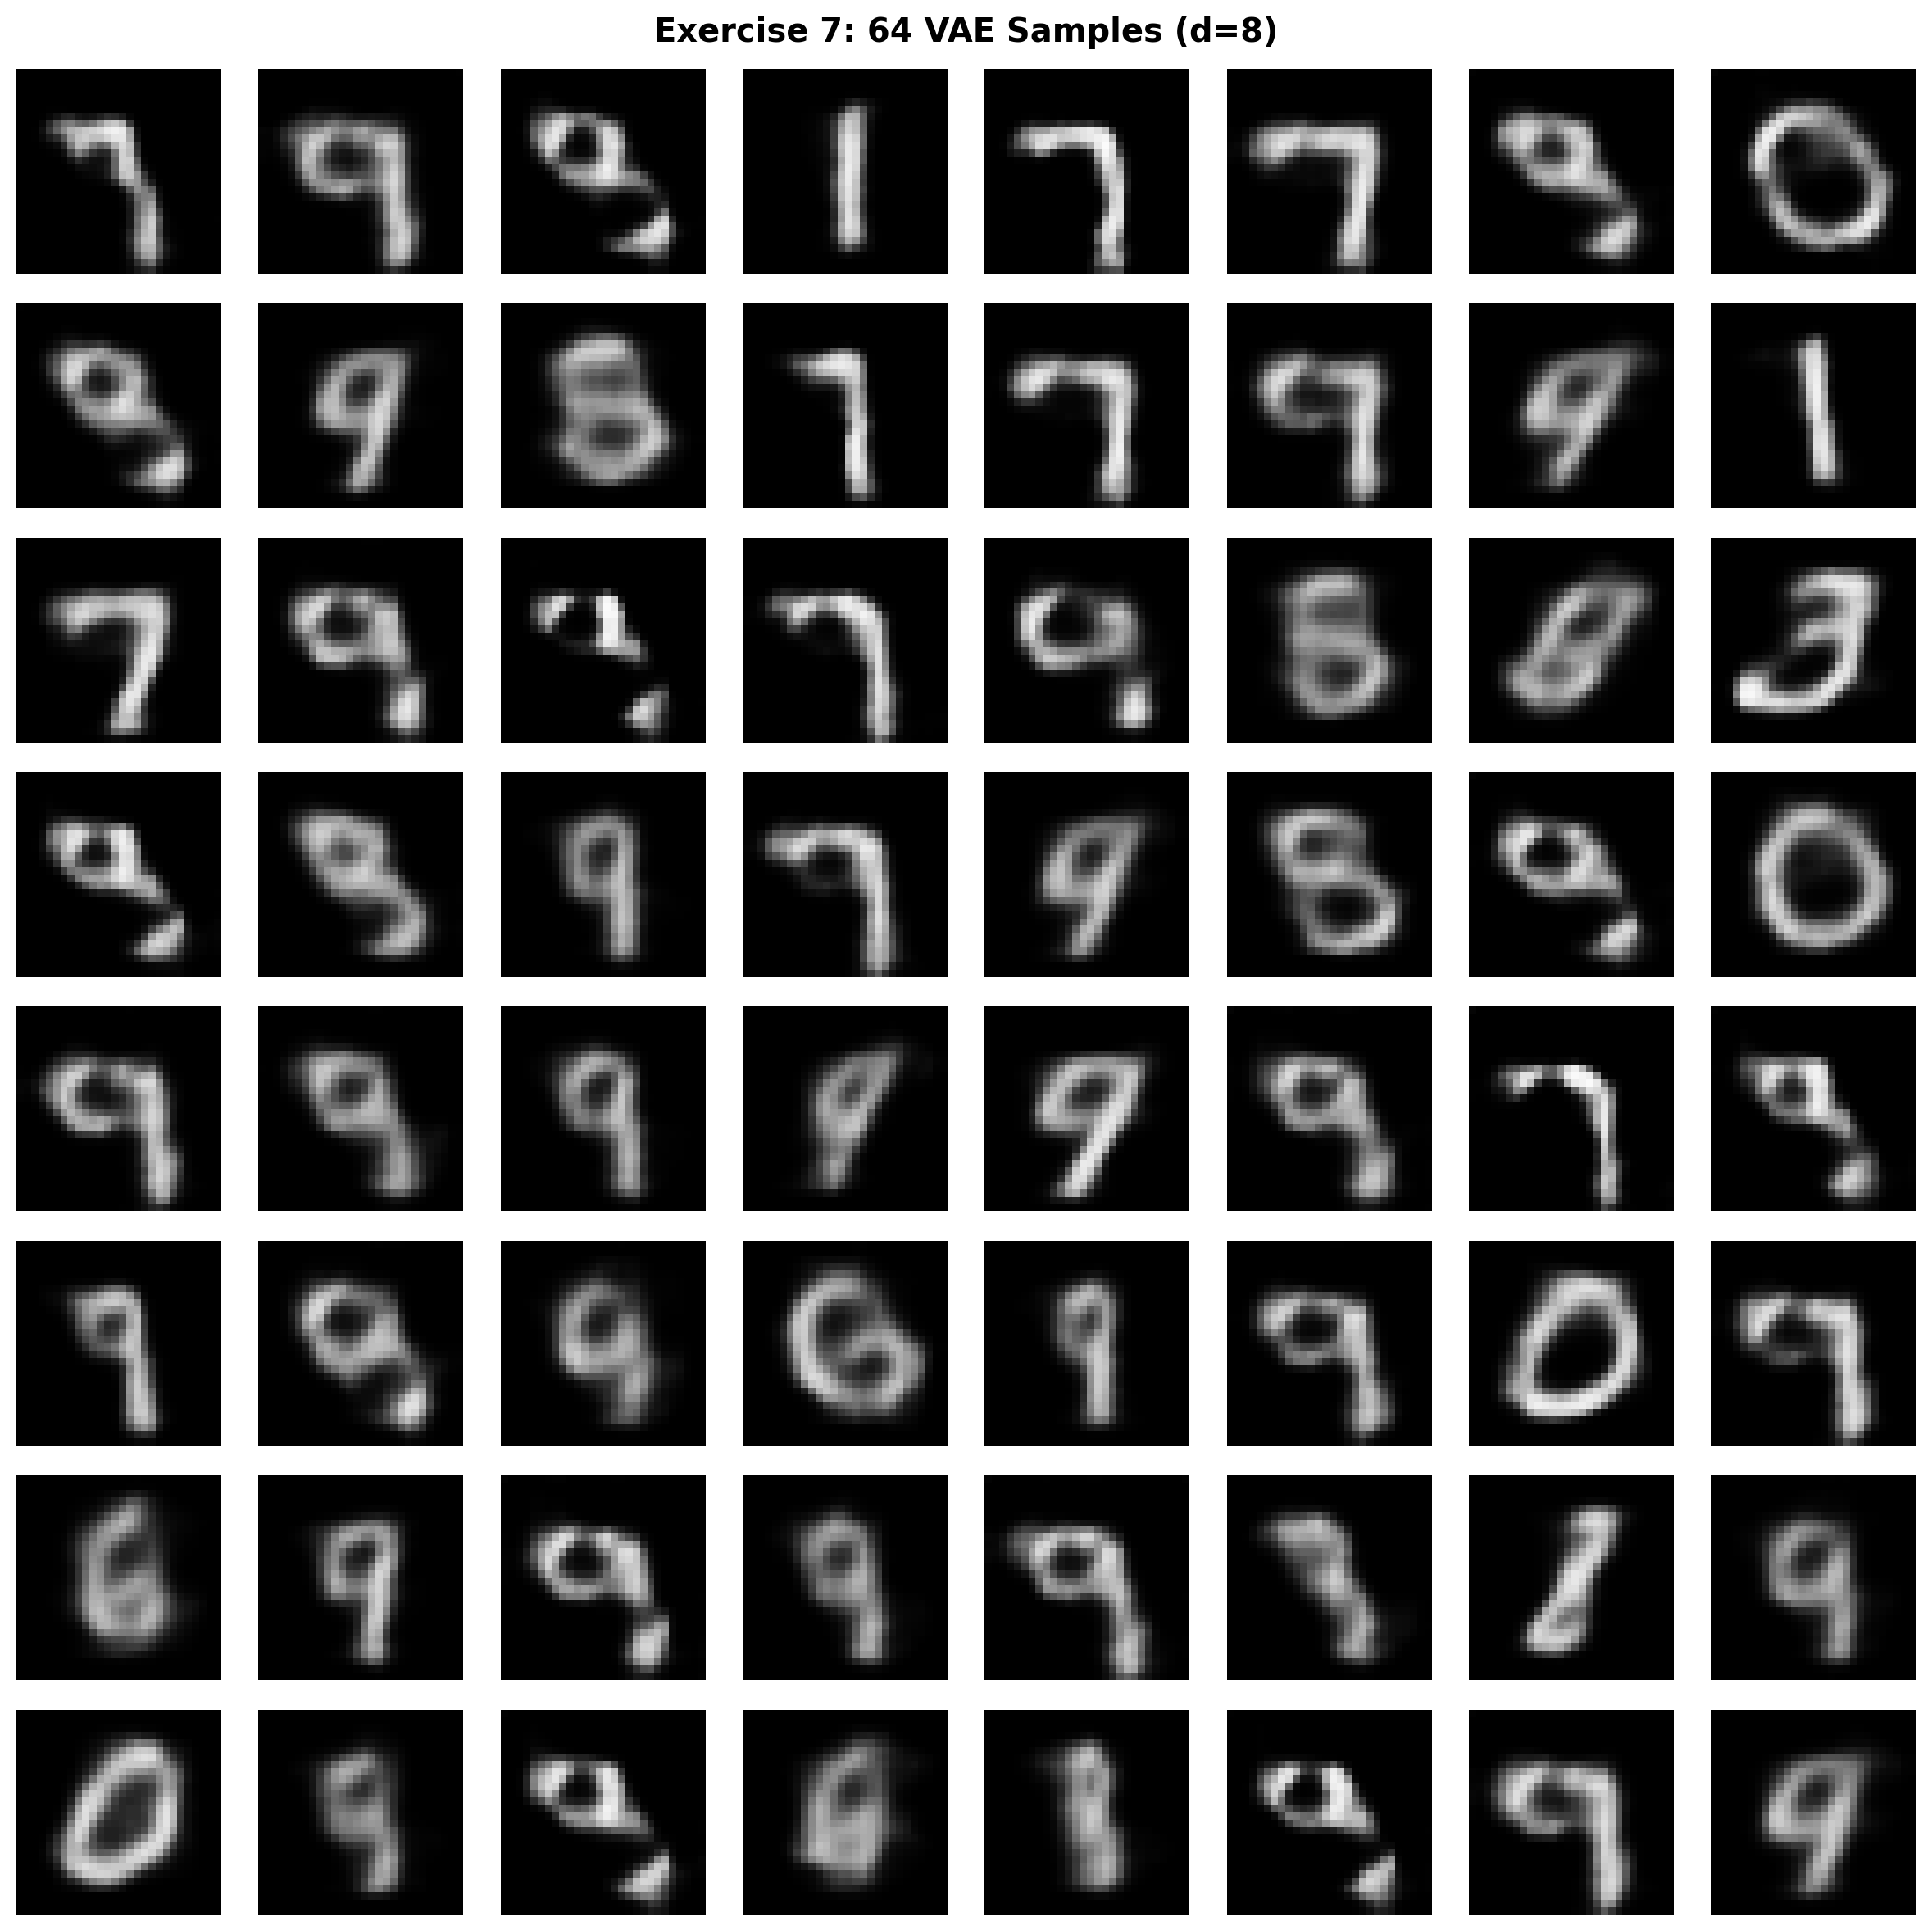

d=2 mean pairwise MSE: 0.01811
d=8 mean pairwise MSE: 0.05007


In [21]:
def generated_grid(decoder,dim,seed,title,filename):
    rng=np.random.default_rng(seed); imgs=decoder.predict(rng.normal(size=(64,dim)).astype("float32"),verbose=0)
    fig,ax=plt.subplots(8,8,figsize=(12,12))
    for i,a in enumerate(ax.flat): a.imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); a.axis("off")
    fig.suptitle(title,fontweight="bold"); save_fig(fig,filename); plt.show(); return imgs

gen64_d2=generated_grid(decoder,2,700,"Exercise 7: 64 VAE Samples (d=2)","29_VAE_generated_64_d2.png")
gen64_d8=generated_grid(dec8,8,701,"Exercise 7: 64 VAE Samples (d=8)","30_VAE_generated_64_d8.png")
for label,g in [("d=2",gen64_d2),("d=8",gen64_d8)]:
    flat=g.reshape(len(g),-1); pair=((flat[:,None]-flat[None,:])**2).mean(2); print(label,"mean pairwise MSE:",round(pair[np.triu_indices(len(flat),1)].mean(),5))

## 17. Additional Exercise 8 — Interpolation Between Two Digit Regions

Saved: Experiment_7_Results/31_Ex8_latent_regions.png | DPI=200


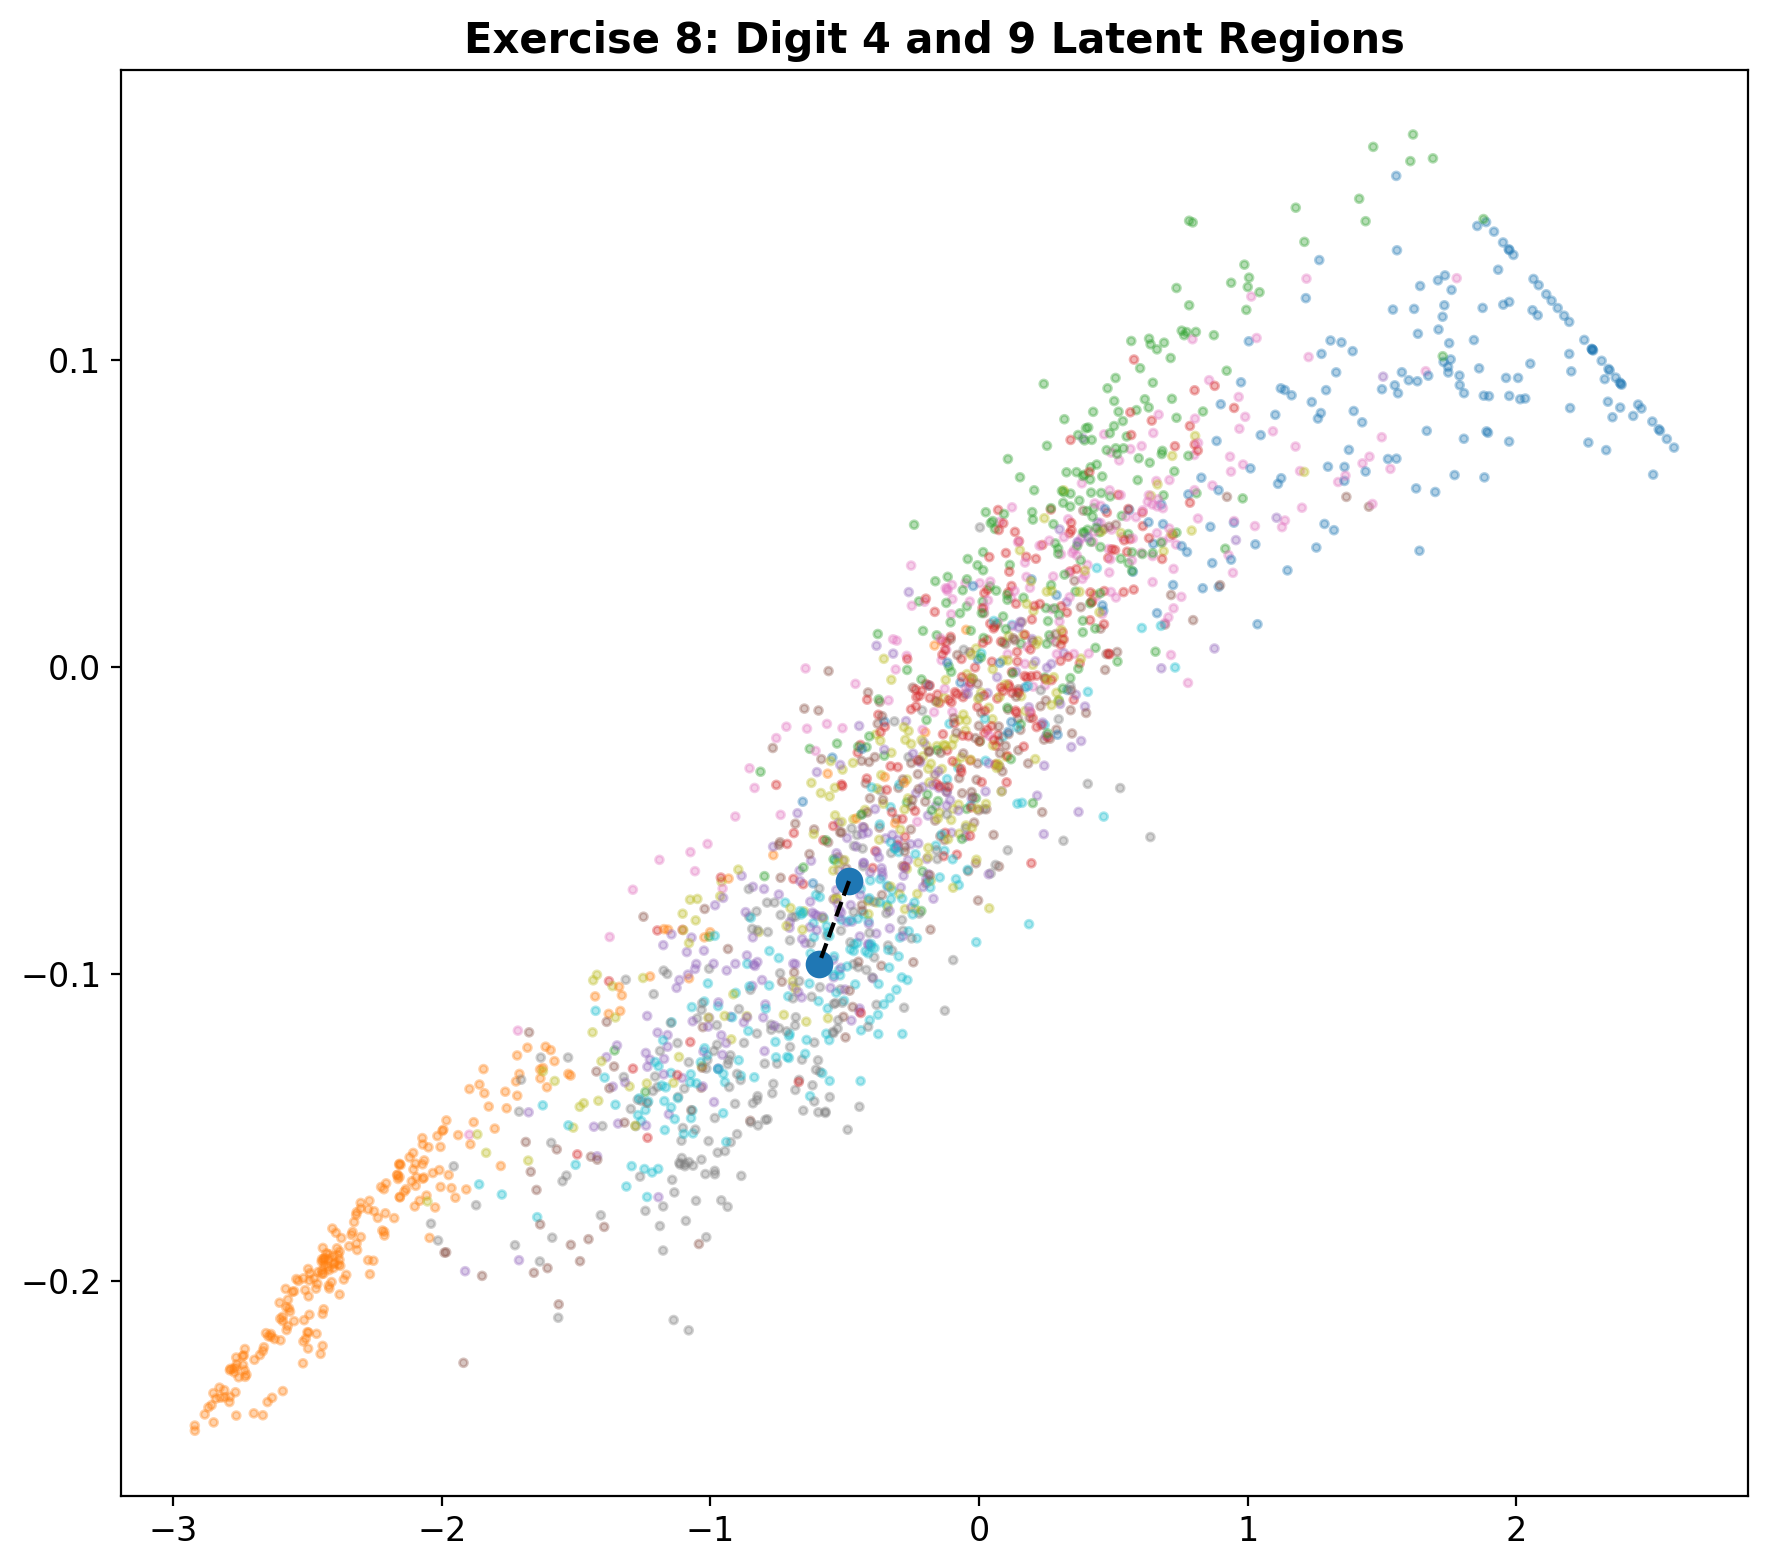

Saved: Experiment_7_Results/32_Ex8_interpolation.png | DPI=200


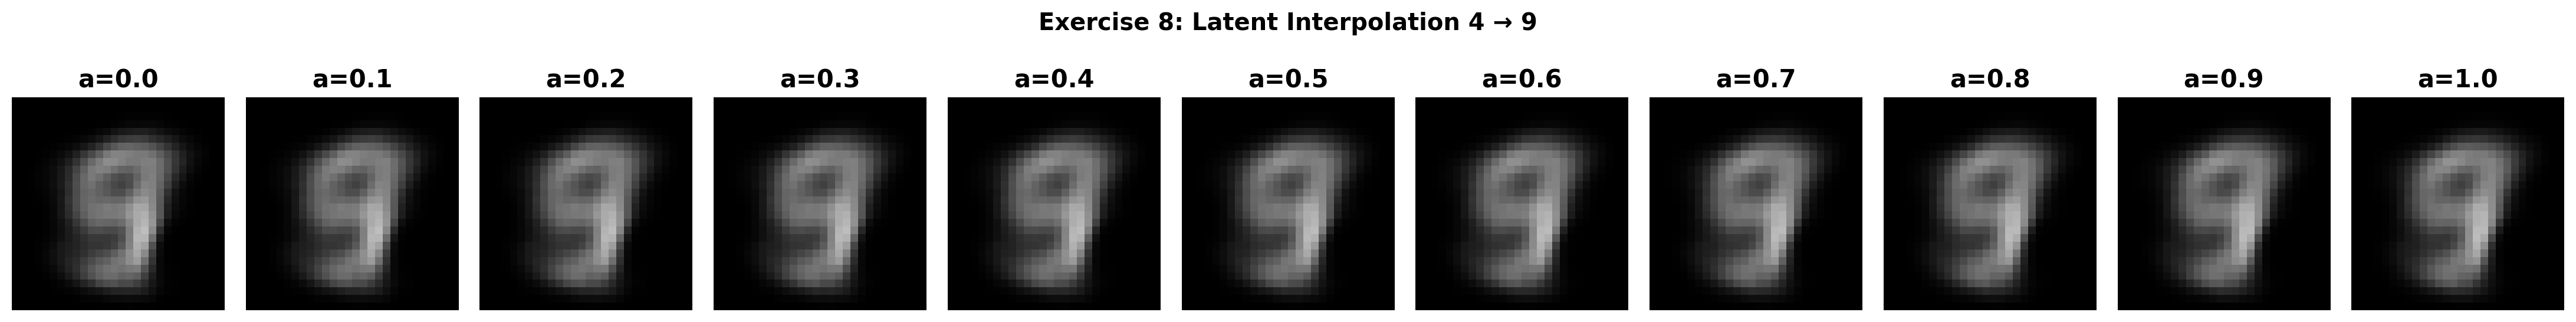

Mean frame-to-frame MSE: 3.2430962e-06 Max: 3.3998888e-06


In [22]:
CLASS_A,CLASS_B=4,9
z_a=z_mu[y_test==CLASS_A].mean(0); z_b=z_mu[y_test==CLASS_B].mean(0); al=np.linspace(0,1,11); zc=np.array([(1-a)*z_a+a*z_b for a in al],dtype="float32"); imgs=decoder.predict(zc,verbose=0)
fig,ax=plt.subplots(figsize=(9,8)); ax.scatter(z_mu[:,0],z_mu[:,1],c=y_test,cmap="tab10",s=8,alpha=.35); ax.plot([z_a[0],z_b[0]],[z_a[1],z_b[1]],"k--"); ax.scatter([z_a[0],z_b[0]],[z_a[1],z_b[1]],s=80); ax.set_title(f"Exercise 8: Digit {CLASS_A} and {CLASS_B} Latent Regions"); save_fig(fig,"31_Ex8_latent_regions.png"); plt.show()
fig,ax=plt.subplots(1,11,figsize=(22,3))
for i,a in enumerate(ax): a.imshow(imgs[i].squeeze(),cmap="gray",vmin=0,vmax=1); a.set_title(f"a={al[i]:.1f}"); a.axis("off")
fig.suptitle(f"Exercise 8: Latent Interpolation {CLASS_A} → {CLASS_B}",fontweight="bold"); save_fig(fig,"32_Ex8_interpolation.png"); plt.show()
steps=np.mean(np.diff(imgs,axis=0)**2,axis=(1,2,3)); print("Mean frame-to-frame MSE:",steps.mean(),"Max:",steps.max())

## 18. Additional Latent-Dimension Study — Fully Connected AE

                      MSE      MAE     SSIM  Parameters  Time (s)
Latent Dimension                                                 
2                 0.04876  0.11351  0.42116      210130  11.85438
8                 0.02921  0.07295  0.65543      210520  10.70431
16                0.02413  0.06274  0.71282      211040  10.16505
32                0.02124  0.05705  0.74179      212080  10.41549
Saved: Experiment_7_Results/10_Latent_dimension.png | DPI=200


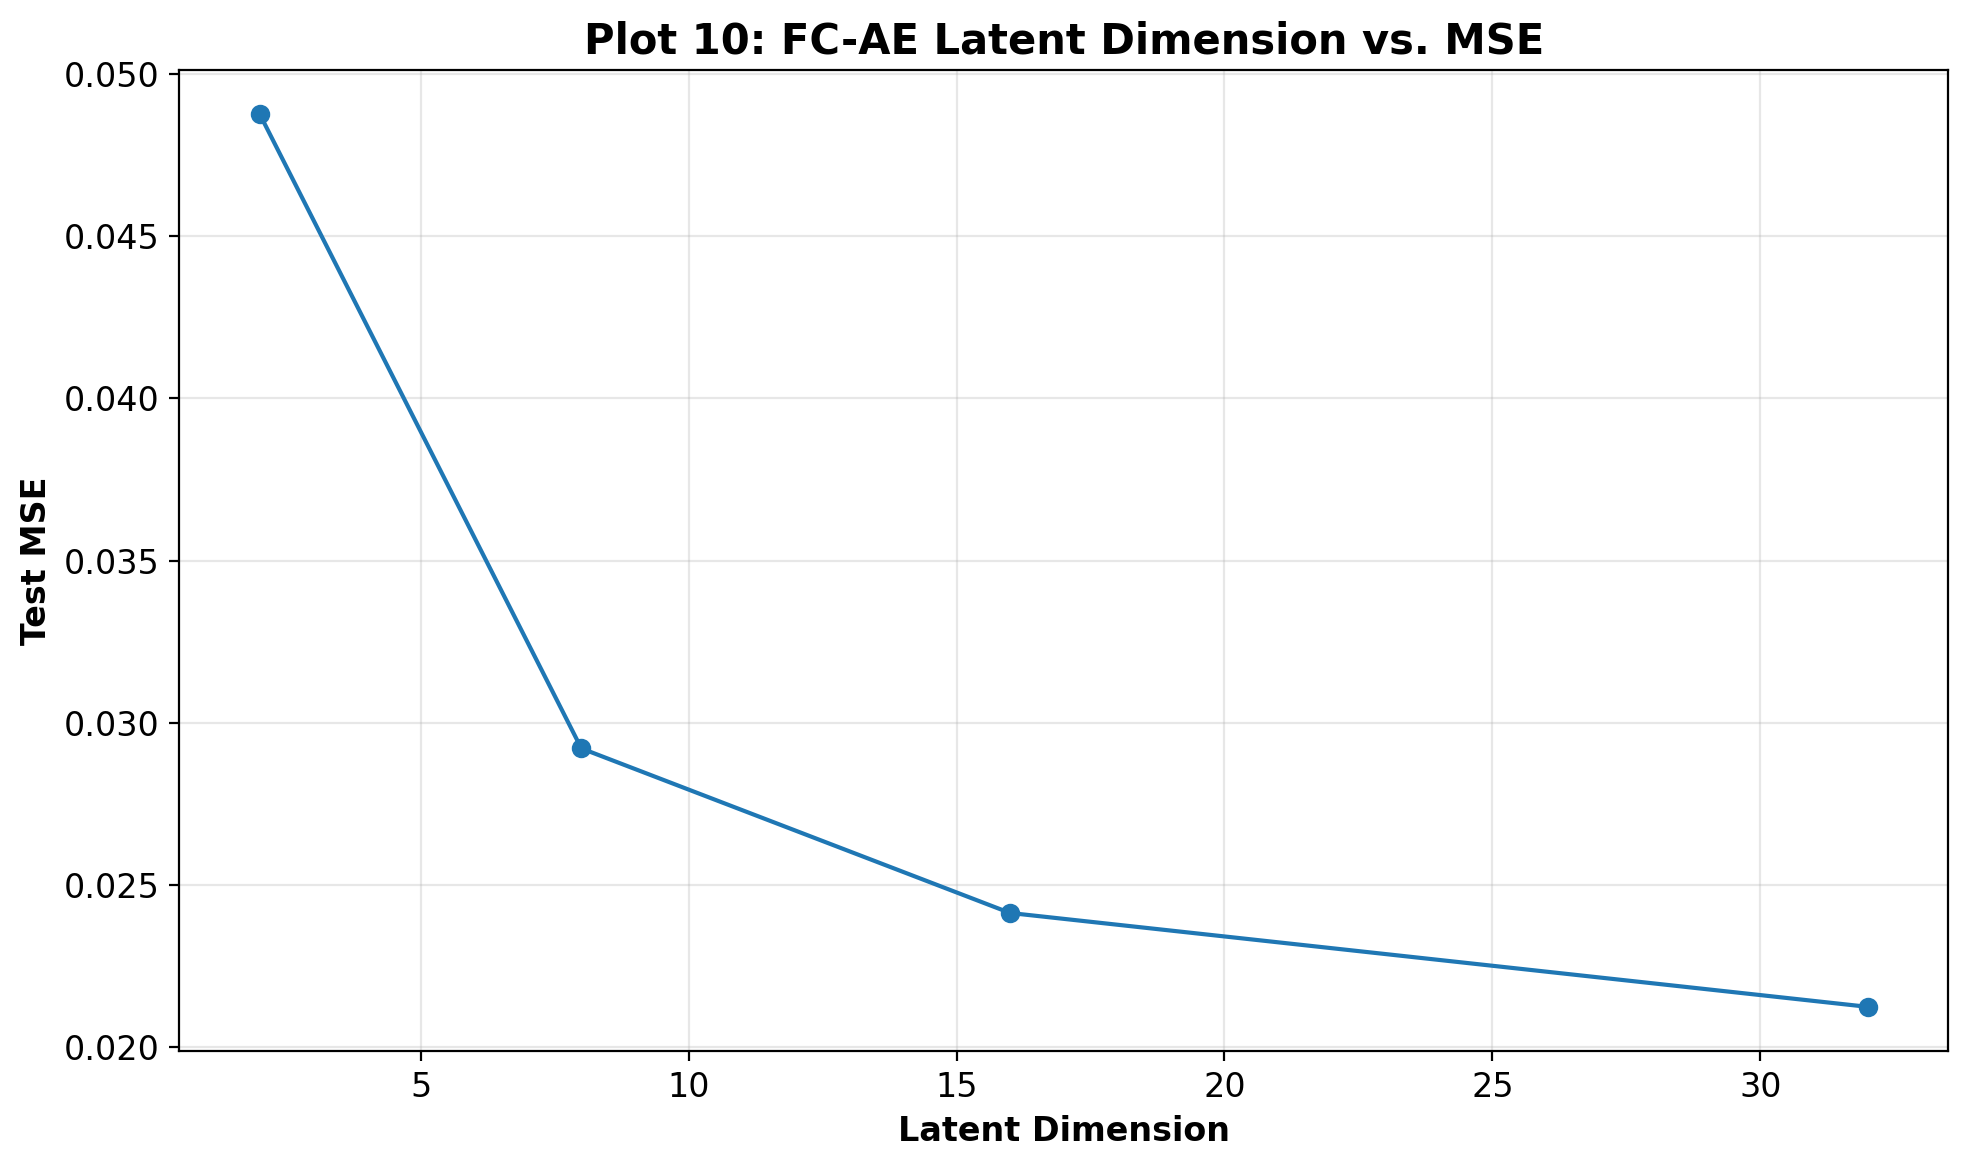

In [23]:
fc_lat_runs={}
for d in [2,8,16,32]:
    keras.utils.set_random_seed(SEED+d); m=build_fc_autoencoder(d); t0=time.time(); h=m.fit(x_tr_flat,x_tr_flat,validation_data=(x_val_flat,x_val_flat),epochs=20,batch_size=128,verbose=0); rec=m.predict(x_test_flat,verbose=0).reshape(-1,28,28,1); fc_lat_runs[d]=(m,h,rec,time.time()-t0)
fc_lat_df=pd.DataFrame([{**{"Latent Dimension":d},**metrics_dict(x_test_cnn,fc_lat_runs[d][2]),"Parameters":count_params(fc_lat_runs[d][0]),"Time (s)":fc_lat_runs[d][3]} for d in fc_lat_runs]).set_index("Latent Dimension")
print(fc_lat_df.round(5)); fc_lat_df.to_csv(os.path.join(RESULTS_DIR,"latent_dimension_results.csv"))
fig,ax=plt.subplots(figsize=(10,6)); ax.plot(fc_lat_df.index,fc_lat_df["MSE"],marker="o"); ax.set(xlabel="Latent Dimension",ylabel="Test MSE",title="Plot 10: FC-AE Latent Dimension vs. MSE"); ax.grid(alpha=.3); save_fig(fig,"10_Latent_dimension.png"); plt.show()

## 19. Final Figure / File Audit

In [24]:
from PIL import Image
pngs=sorted(f for f in os.listdir(RESULTS_DIR) if f.endswith(".png"))
print(f"{len(pngs)} PNG figures generated.")
issues=[]
for f in pngs:
    with Image.open(os.path.join(RESULTS_DIR,f)) as im:
        dpi=im.info.get("dpi",(0,0))[0]
        if abs(dpi-IMAGE_DPI)>1: issues.append((f,dpi))
print("DPI issues:", issues if issues else "none")
shutil.make_archive("Experiment_7_Results_Final","zip",RESULTS_DIR)
print("Created Experiment_7_Results_Final.zip")

35 PNG figures generated.
DPI issues: none
Created Experiment_7_Results_Final.zip


In [ ]:
!zip -r Experiment_7_FINAL.zip /kaggle/working/Experiment_7_FINAL_CLEAN_FROM_SCRATCH_200DPI.ipynb